## Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
from google.colab import userdata

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import re
import ast
import time
import requests
from tqdm import tqdm
import zipfile
import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random, math, copy

# Create a directory to store the parquet files if it doesn't exist
import os
output_dir = '/content/drive/MyDrive/BT4222 Project Datasets/preprocessed_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)



## Data Ingestion

In [ ]:
# MovieLens interaction dataset
ratings_df = pd.read_csv('/content/drive/MyDrive/BT4222 Project Datasets/ratings.dat', sep="::", engine='python', names=['user_id', 'movie_id', 'rating', 'timestamp'])
print("ratings_df:")
ratings_df.head()

ratings_df:


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [ ]:
# Checking Rating Data Distribution
# Duplicates (same user rating same movie twice)
dupes = ratings_df.duplicated(subset=["user_id", "movie_id"], keep=False)
print(f"Duplicate user-movie pairs: {dupes.sum()}")  # Should be 0 for ML-1M

# Rating distribution — no outliers possible (values are 1-5 integers)
print(ratings_df["rating"].value_counts().sort_index())

# Timestamp sanity
print(f"Date range: {pd.to_datetime(ratings_df['timestamp'], unit='s').min()} to "
      f"{pd.to_datetime(ratings_df['timestamp'], unit='s').max()}")

Duplicate user-movie pairs: 0
rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64
Date range: 2000-04-25 23:05:32 to 2003-02-28 17:49:50


In [ ]:
# MovieLens users dataset
users_df = pd.read_csv('/content/drive/MyDrive/BT4222 Project Datasets/users.dat', sep="::", engine='python', names=['user_id', 'gender', 'age', 'occupation', 'zip_code'])
print("users_df:")
users_df.head()

# Save 'users' DataFrame to parquet
users_df.to_parquet(os.path.join(output_dir, 'users.parquet'), index=False)
print(f"'users.parquet' saved to {output_dir}")

users_df:
'users.parquet' saved to /content/drive/MyDrive/BT4222 Project Datasets/preprocessed_data


In [ ]:
# Checking Users Data
print("Genders:", users_df["gender"].unique())         # Should be ['F', 'M']
print("Ages:", sorted(users_df["age"].unique()))        # Should be [1, 18, 25, 35, 45, 50, 56]
print("Occupations:", sorted(users_df["occupation"].unique()))  # 0-20
print("Null zip codes:", users_df["zip_code"].isna().sum())

Genders: ['F' 'M']
Ages: [np.int64(1), np.int64(18), np.int64(25), np.int64(35), np.int64(45), np.int64(50), np.int64(56)]
Occupations: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
Null zip codes: 0


In [ ]:
# MovieLens movies dataset
movies_df = pd.read_csv('/content/drive/MyDrive/BT4222 Project Datasets/movies.dat', sep="::", engine='python', names=['movie_id', 'title', 'genres'], encoding='latin-1')
print("movies_df:")
movies_df.head()

movies_df:


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
# IMDB movies dataset
movies_metadata_df = pd.read_csv('/content/drive/MyDrive/BT4222 Project Datasets/Top_10000_Movies_IMDb.csv')
print("movies_metadata_df:")
movies_metadata_df.head()

movies_metadata_df:


,ID,Movie Name,Rating,Runtime,Genre,Metascore,Plot,Directors,Stars,Votes,Gross,Link
0,1,The Shawshank Redemption,9.3,142 min,Drama,82.0,"Over the course of several years, two convicts...","['Frank Darabont', 'Tim Robbins', 'Morgan Free...","['Tim Robbins', 'Morgan Freeman', 'Bob Gunton'...",2752419,28341469,https://www.imdb.com/title/tt0111161/
1,2,The Godfather,9.2,175 min,"Crime, Drama",100.0,"Don Vito Corleone, head of a mafia family, dec...","['Francis Ford Coppola', 'Marlon Brando', 'Al ...","['Marlon Brando', 'Al Pacino', 'James Caan', '...",1914751,134966411,https://www.imdb.com/title/tt0068646/
2,3,Ramayana: The Legend of Prince Rama,9.2,135 min,"Animation, Action, Adventure",NaN,An anime adaptation of the Hindu epic the Rama...,"['Ram Mohan', 'Yûgô Sakô', 'Koichi Saski', 'Ar...","['Yûgô Sakô', 'Koichi Saski', 'Arun Govil', 'N...",10108,10108,https://www.imdb.com/title/tt0259534/
3,4,The Chaos Class,9.2,87 min,"Comedy, Drama",NaN,"Lazy, uneducated students share a very close b...","['Ertem Egilmez', 'Kemal Sunal', 'Münir Özkul'...","['Kemal Sunal', 'Münir Özkul', 'Halit Akçatepe...",41785,41785,https://www.imdb.com/title/tt0252487/
4,5,Daman,9.1,121 min,"Adventure, Drama",NaN,"The film is set in 2015. Sid, is a young docto...","['Lenka Debiprasad', 'Vishal Mourya', 'Karan K...","['Vishal Mourya', 'Karan Kandhapan', 'Babushan...",13303,13303,https://www.imdb.com/title/tt17592606/


In [ ]:
print(movies_metadata_df.isna().sum())

ID               0
Movie Name       0
Rating           0
Runtime          0
Genre            0
Metascore     2007
Plot             0
Directors        0
Stars            0
Votes            0
Gross            0
Link             0
dtype: int64


In [ ]:
# Save 'movies_metadata' DataFrame to parquet
movies_metadata_df.to_parquet(os.path.join(output_dir, 'movies_metadata.parquet'), index=False)
print(f"'movies_metadata.parquet' saved to {output_dir}")

'movies_metadata.parquet' saved to /content/drive/MyDrive/BT4222 Project Datasets/preprocessed_data


In [ ]:
# MovieLens ID and IMDB ID Link Dataset
links = pd.read_csv("/content/drive/MyDrive/BT4222 Project Datasets/links.csv")  # movieId, imdbId, tmdbId


# Data Preprocessing

## Engineering Movie-Level Features

In [ ]:
## Preprocessing MovieLens movies dataset

# Retain the original movies_df
movies = movies_df.copy()

movies.columns = movies.columns.str.strip()

# Extract year from titles like "Toy Story (1995)"
movies["release_year"] = movies["title"].str.extract(r"\((\d{4})\)$").astype("Int64")

# Remove year from title and clean
movies["title_clean"] = movies["title"].str.replace(r"\s*\(\d{4}\)$", "", regex=True).str.strip()

# Create a list of genres from `genres`
movies["genre_list"] = movies["genres"].str.split("|")

# Drop columns that are no longer required
movies.drop(columns=["title", "genres", "title_clean"], inplace=True)

# Rearrange columns
movies = movies[["movie_id", "release_year", "genre_list"]]

print("movies:")
print(movies.head())
print("\nShape:", movies.shape)

# Save 'movies' DataFrame to parquet
movies.to_parquet(os.path.join(output_dir, 'movies.parquet'), index=False)
print(f"'movies.parquet' saved to {output_dir}")


movies:
   movie_id  release_year                        genre_list
0         1          1995   [Animation, Children's, Comedy]
1         2          1995  [Adventure, Children's, Fantasy]
2         3          1995                 [Comedy, Romance]
3         4          1995                   [Comedy, Drama]
4         5          1995                          [Comedy]

Shape: (3883, 3)
'movies.parquet' saved to /content/drive/MyDrive/BT4222 Project Datasets/preprocessed_data


In [ ]:
## Preprocessing IMDB movies dataset

# Retain the original movies_metadata
metadata = movies_metadata_df.copy()

# Extract imdb_id from the Link column
metadata["imdb_id"] = metadata["Link"].str.extract(r"(tt\d+)")

# Drop columns that do not add value
metadata.drop(columns=["ID", "Link", "Metascore", "Rating", "Votes", "Gross", "Genre"], inplace=True)

# Rename columns
metadata = metadata.rename(columns={
    "Movie Name": "movie_title",
    "Runtime": "runtime_raw",
    "Plot": "plot",
    "Directors": "director_list",
    "Stars": "cast_list"
})

# Make runtime (in minutes) a float
metadata["runtime_min"] = metadata["runtime_raw"].str.extract(r"(\d+)").astype("float")

# Helper function to convert Series to List
def series_to_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x) # converts "['A', 'B']" -> ['A', 'B']
        except:
            return []
    return []

# Get casts and directors lists
metadata["cast_list"] = metadata["cast_list"].apply(series_to_list)
metadata["director_list"] = metadata["director_list"].apply(series_to_list)

# Extract out the first 3 casts
metadata["first_three_casts"] = metadata["cast_list"].apply(lambda x: x[:3])

# Extract out the first 3 directors
metadata["first_three_directors"] = metadata["director_list"].apply(lambda x: x[:3])

# Drop columns that are no longer required
metadata.drop(columns=["movie_title", "runtime_raw", "cast_list", "director_list", "plot"], inplace=True)

# Rearrange columns
metadata = metadata[["imdb_id", "runtime_min", "first_three_casts", "first_three_directors"]]

# Save 'metadata' DataFrame to parquet
metadata.to_parquet(os.path.join(output_dir, 'metadata.parquet'), index=False)
print(f"'metadata.parquet' saved to {output_dir}")

print("metadata:")
print(metadata.head())
print("\nShape:", metadata.shape)

'metadata.parquet' saved to /content/drive/MyDrive/BT4222 Project Datasets/preprocessed_data
metadata:
      imdb_id  runtime_min                                  first_three_casts  \
0   tt0111161        142.0          [Tim Robbins, Morgan Freeman, Bob Gunton]   
1   tt0068646        175.0             [Marlon Brando, Al Pacino, James Caan]   
2   tt0259534        135.0              [Yûgô Sakô, Koichi Saski, Arun Govil]   
3   tt0252487         87.0         [Kemal Sunal, Münir Özkul, Halit Akçatepe]   
4  tt17592606        121.0  [Vishal Mourya, Karan Kandhapan, Babushan Moha...   

                               first_three_directors  
0      [Frank Darabont, Tim Robbins, Morgan Freeman]  
1   [Francis Ford Coppola, Marlon Brando, Al Pacino]  
2               [Ram Mohan, Yûgô Sakô, Koichi Saski]  
3          [Ertem Egilmez, Kemal Sunal, Münir Özkul]  
4  [Lenka Debiprasad, Vishal Mourya, Karan Kandha...  

Shape: (9999, 4)


In [ ]:
# Merge MovieLens movies dataset and IMDb movies dataset to get movie_features_df

# Format imdbId to match IMDb dataset's format ("tt0114709")
links["imdb_id"] = links["imdbId"].apply(lambda x: f"tt{int(x):07d}")

# Merge directly on imdb_id
movie_features_df = movies.merge(
    links[["movieId", "imdb_id"]].rename(columns={"movieId": "movie_id"}),
    on="movie_id",
    how="left"
).merge(
    metadata,
    on="imdb_id",
    how="left"
)

# Drop imdb_id (no longer needed)
movie_features_df.drop(columns=["imdb_id"], inplace=True)

movie_features_df.head()


,movie_id,release_year,genre_list,runtime_min,first_three_casts,first_three_directors
0,1,1995,"[Animation, Children's, Comedy]",81.0,"[Tom Hanks, Tim Allen, Don Rickles]","[John Lasseter, Tom Hanks, Tim Allen]"
1,2,1995,"[Adventure, Children's, Fantasy]",104.0,"[Robin Williams, Kirsten Dunst, Bonnie Hunt]","[Joe Johnston, Robin Williams, Kirsten Dunst]"
2,3,1995,"[Comedy, Romance]",101.0,"[Walter Matthau, Jack Lemmon, Ann-Margret]","[Howard Deutch, Walter Matthau, Jack Lemmon]"
3,4,1995,"[Comedy, Drama]",124.0,"[Whitney Houston, Angela Bassett, Loretta Devine]","[Forest Whitaker, Whitney Houston, Angela Bass..."
4,5,1995,[Comedy],106.0,"[Steve Martin, Diane Keaton, Martin Short]","[Charles Shyer, Steve Martin, Diane Keaton]"


In [ ]:
# Check merge coverage
# print(f"Movies with no IMDb match: {movie_features_df['plot'].isna().sum()} / {len(movie_features_df)}")


In [ ]:
print(movie_features_df.isna().sum())

movie_id                    0
release_year                0
genre_list                  0
runtime_min              1835
first_three_casts        1835
first_three_directors    1835
dtype: int64


In [ ]:
movie_features_df.dropna()

,movie_id,release_year,genre_list,runtime_min,first_three_casts,first_three_directors
0,1,1995,"[Animation, Children's, Comedy]",81.0,"[Tom Hanks, Tim Allen, Don Rickles]","[John Lasseter, Tom Hanks, Tim Allen]"
1,2,1995,"[Adventure, Children's, Fantasy]",104.0,"[Robin Williams, Kirsten Dunst, Bonnie Hunt]","[Joe Johnston, Robin Williams, Kirsten Dunst]"
2,3,1995,"[Comedy, Romance]",101.0,"[Walter Matthau, Jack Lemmon, Ann-Margret]","[Howard Deutch, Walter Matthau, Jack Lemmon]"
3,4,1995,"[Comedy, Drama]",124.0,"[Whitney Houston, Angela Bassett, Loretta Devine]","[Forest Whitaker, Whitney Houston, Angela Bass..."
4,5,1995,[Comedy],106.0,"[Steve Martin, Diane Keaton, Martin Short]","[Charles Shyer, Steve Martin, Diane Keaton]"
...,...,...,...,...,...,...
3877,3947,1971,[Thriller],112.0,"[Michael Caine, Ian Hendry, Britt Ekland]","[Mike Hodges, Michael Caine, Ian Hendry]"
3878,3948,2000,[Comedy],108.0,"[Ben Stiller, Robert De Niro, Teri Polo]","[Jay Roach, Ben Stiller, Robert De Niro]"
3879,3949,2000,[Drama],102.0,"[Ellen Burstyn, Jared Leto, Jennifer Connelly]","[Darren Aronofsky, Ellen Burstyn, Jared Leto]"
3880,3950,2000,[Drama],101.0,"[Colin Farrell, Matthew Davis, Clifton Collins...","[Joel Schumacher, Colin Farrell, Matthew Davis]"


In [ ]:
# Multimodal Embeddings

# Load movie_features_df movie IDs
all_movie_ids = set(movie_features_df["movie_id"].values)

def load_embeddings_from_zip(zip_path, movie_ids_to_load, timeout=10):
    """Read embeddings directly from zip, only for the specified movie IDs, handling nested paths."""
    embeddings = {}
    missing = []

    # Derive folder_name from zip_path (e.g., 'TEXT_mpnet' from '.../TEXT_mpnet.zip')
    folder_name = os.path.splitext(os.path.basename(zip_path))[0]

    with zipfile.ZipFile(zip_path, "r") as zf:
        # Get list of files in the zip to check naming convention
        all_files = zf.namelist()
        print(f"Zip contains {len(all_files)} files. Example: {all_files[:3]}")

        for mid in tqdm(movie_ids_to_load, desc=f"Reading {zip_path}"):
            # Try common naming patterns, including the nested path
            possible_fnames = [
                f"{mid}.json",
                f"{mid}.npy",
                f"features/{mid}.json",
                f"{folder_name}/{mid}.json",  # Use the derived folder_name
                f"{folder_name}/{mid}.npy"    # Use the derived folder_name
            ]

            found_file = False
            for fname in possible_fnames:
                if fname in all_files:
                    with zf.open(fname) as f:
                        try:
                            data = json.load(f)
                            # Check if the loaded data is a dictionary and contains the movie ID as a key
                            if isinstance(data, dict) and str(mid) in data:
                                embeddings[mid] = data[str(mid)]
                            else:
                                embeddings[mid] = data # Assume it's a direct list/array if not a dict with mid key
                        except json.JSONDecodeError:
                            f.seek(0) # Reset file pointer
                            try:
                                embeddings[mid] = np.load(f).tolist()
                            except Exception:
                                # Handle cases where it's not JSON or NPY
                                pass
                    found_file = True
                    break
            if not found_file:
                missing.append(mid)

    print(f"Loaded: {len(embeddings)}, Missing: {len(missing)}")
    return embeddings, missing

# Process all three encoders to get initial set of available embeddings
zip_files = {
    "text_mpnet": "/content/drive/MyDrive/BT4222 Project Datasets/TEXT_mpnet.zip",
    "audio_whisper": "/content/drive/MyDrive/BT4222 Project Datasets/AUD_whisper.zip",
    "video_mvit": "/content/drive/MyDrive/BT4222 Project Datasets/VID_mvit.zip"
}

all_missing_initial = {}
# Start with all movie IDs from movie_features_df for the initial check
initial_candidate_ids = set(movie_features_df["movie_id"].values)
for name, zip_path in zip_files.items():
    print(f"\n--- Processing {name} for initial check ---")
    # Load embeddings for all_movie_ids to determine which have embeddings
    embeddings_for_all, missing_for_all = load_embeddings_from_zip(zip_path, initial_candidate_ids)
    all_missing_initial[name] = set(missing_for_all)

# Determine movies that have ALL three modalities from the initial set of all movies
multimodal_available_ids = set(initial_candidate_ids)
for name in all_missing_initial:
    multimodal_available_ids = multimodal_available_ids - all_missing_initial[name]

print(f"\nMovies with all 3 modalities (initial): {len(multimodal_available_ids)} / {len(initial_candidate_ids)}")


# --- New Filtering Step: Combine with movies having a non-null plot ---
# plot_available_movie_ids = set(movie_features_df[movie_features_df['plot'].notna()]["movie_id"].values)
# print(f"Movies with non-null plot: {len(plot_available_movie_ids)}")

# # The final set of common IDs should have both all 3 modalities AND a non-null plot
# final_common_ids = multimodal_available_ids.intersection(plot_available_movie_ids)

# print(f"\nMovies with all 3 modalities AND non-null plot: {len(final_common_ids)} / {len(all_movie_ids)}")

# Save the final ID mapping
sorted_common = sorted(list(multimodal_available_ids)) # Convert set to list before sorting
id_mapping = pd.DataFrame({
    "movie_id": sorted_common,
    "emb_idx": range(len(sorted_common))
})
if not id_mapping.empty:
    id_mapping.to_csv("movie_id_to_emb_idx.csv", index=False)
else:
    print("No common IDs found, id_mapping will be empty.")

# Re-export aligned matrices (same row order, same movies)
# Collect embeddings for combined DataFrame
all_modal_embeddings_data = {mid: {} for mid in sorted_common}

for name, zip_path in zip_files.items():
    # Only load for final_common_ids
    embeddings_for_common, _ = load_embeddings_from_zip(zip_path, multimodal_available_ids)
    if embeddings_for_common:
        # Ensure that the dictionary values are directly the embedding lists/arrays
        matrix = np.array([embeddings_for_common[mid] for mid in sorted_common])
        np.save(f"{name}_movie_aligned.npy", matrix)
        print(f"Saved {name}_movie_aligned.npy with shape {matrix.shape}")

        for mid in sorted_common:
            all_modal_embeddings_data[mid][f"{name}_embedding"] = embeddings_for_common.get(mid)
    else:
        print(f"No embeddings found for {name} among final_common_ids.")

# Create DataFrame from collected embeddings
embeddings_df_rows = []
for mid in sorted_common:
    row_data = {"movie_id": mid}
    row_data.update(all_modal_embeddings_data[mid])
    embeddings_df_rows.append(row_data)

movie_embeddings_df = pd.DataFrame(embeddings_df_rows)

# Define output directory for parquet files
output_dir = '/content/drive/MyDrive/BT4222 Project Datasets/preprocessed_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save combined embeddings DataFrame to parquet
if not movie_embeddings_df.empty:
    movie_embeddings_df.to_parquet(os.path.join(output_dir, 'movie_embeddings.parquet'), index=False)
    print(f"'movie_embeddings.parquet' saved to {output_dir}")
else:
    print("movie_embeddings_df is empty, not saving.")

print("Movie Embeddings DataFrame:")
print(movie_embeddings_df.head())


--- Processing text_mpnet for initial check ---
Zip contains 25178 files. Example: ['TEXT_mpnet/', 'TEXT_mpnet/86166.json', 'TEXT_mpnet/127292.json']


Reading /content/drive/MyDrive/BT4222 Project Datasets/TEXT_mpnet.zip: 100%|██████████| 3883/3883 [00:46<00:00, 83.04it/s] 


Loaded: 3742, Missing: 141

--- Processing audio_whisper for initial check ---
Zip contains 19341 files. Example: ['AUD_whisper/', 'AUD_whisper/127292.json', 'AUD_whisper/3721.json']


Reading /content/drive/MyDrive/BT4222 Project Datasets/AUD_whisper.zip: 100%|██████████| 3883/3883 [00:31<00:00, 121.42it/s]


Loaded: 3227, Missing: 656

--- Processing video_mvit for initial check ---
Zip contains 19367 files. Example: ['VID_mvit/', 'VID_mvit/127292.json', 'VID_mvit/3721.json']


...

Loaded: 3227, Missing: 0
Saved text_mpnet_movie_aligned.npy with shape (3227, 768)
Zip contains 19341 files. Example: ['AUD_whisper/', 'AUD_whisper/127292.json', 'AUD_whisper/3721.json']


Reading /content/drive/MyDrive/BT4222 Project Datasets/AUD_whisper.zip: 100%|██████████| 3227/3227 [00:01<00:00, 1861.33it/s]


Loaded: 3227, Missing: 0
Saved audio_whisper_movie_aligned.npy with shape (3227, 512)
Zip contains 19367 files. Example: ['VID_mvit/', 'VID_mvit/127292.json', 'VID_mvit/3721.json']


Reading /content/drive/MyDrive/BT4222 Project Datasets/VID_mvit.zip: 100%|██████████| 3227/3227 [00:02<00:00, 1516.10it/s]


Loaded: 3227, Missing: 0
Saved video_mvit_movie_aligned.npy with shape (3227, 768)
'movie_embeddings.parquet' saved to /content/drive/MyDrive/BT4222 Project Datasets/preprocessed_data
Movie Embeddings DataFrame:
   movie_id                               text_mpnet_embedding  \
0         1  [0.03104141727089882, 0.0694214329123497, -0.0...   
1         3  [0.004733850248157978, 0.026955202221870422, 0...   
2         4  [0.05150563269853592, -0.012895462103188038, -...   
3         5  [-0.005085940472781658, -0.016544289886951447,...   
4         7  [-0.017988452687859535, -0.02599502168595791, ...   

                             audio_whisper_embedding  \
0  [-0.18406197428703308, 0.21669840812683105, -0...   
1  [-0.19352294504642487, 0.221668541431427, -0.0...   
2  [-0.29757004976272583, 0.15230487287044525, 0....   
3  [-0.18166480958461761, 0.16606278717517853, 0....   
4  [-0.34250983595848083, 0.17208105325698853, 0....   

                                video_mvit_embedding  

In [ ]:
print(movie_embeddings_df.describe())

          movie_id
count  3227.000000
mean   2022.133870
std    1154.131699
min       1.000000
25%    1019.500000
50%    2082.000000
75%    3028.500000
max    3952.000000


In [ ]:
# Keep only movies that have embeddings
valid_movie_ids = set(movie_embeddings_df["movie_id"].values)
movie_features_df = movie_features_df[movie_features_df["movie_id"].isin(valid_movie_ids)]

# Filter ratings to only movies that have embeddings
valid_movie_ids = set(movie_embeddings_df["movie_id"].values)
ratings_filtered = ratings_df[ratings_df["movie_id"].isin(valid_movie_ids)].copy()

# Filter movies to only movies that have ratings
movie_features_df = movie_features_df[movie_features_df["movie_id"].isin(ratings_filtered["movie_id"])].copy()

# Save 'movie_features_df' DataFrame to parquet
movie_features_df.to_parquet(os.path.join(output_dir, 'movie_features_df.parquet'), index=False)
print(f"'movie_features_df.parquet' saved to {output_dir}")

print(f"Movies: {movie_features_df['movie_id'].nunique()}")

'movie_features_df.parquet' saved to /content/drive/MyDrive/BT4222 Project Datasets/preprocessed_data
Movies: 3150


## Engineering User-Level Features

In [ ]:
# Retain the original users_df
user_features_df = users_df.copy()

# 1) Age -> age_bucket
# MovieLens age is already coded into brackets: 1, 18, 25, 35, 45, 50, 56

age_bucket_map = {
    1: "children",
    18: "young_adult",     # 18-24
    25: "young_adult",     # 25-34
    35: "mid_adult",       # 35-44
    45: "mid_adult",       # 45-49
    50: "older_adult",     # 50-55
    56: "senior"           # 56+
}

user_features_df["age_bucket"] = user_features_df["age"].map(age_bucket_map)

# 2) Occupation -> occupation_group
occupation_group_map = {
    0: "other",
    1: "education",          # academic/educator
    2: "creative",           # artist
    3: "admin",              # clerical/admin
    4: "student",            # college/grad student
    5: "service",            # customer service
    6: "healthcare",         # doctor/health care
    7: "business",           # executive/managerial
    8: "manual_labor",       # farmer
    9: "homemaker",          # homemaker
    10: "student",           # K-12 student
    11: "legal",             # lawyer
    12: "technology",        # programmer
    13: "retired",           # retired
    14: "business",          # sales/marketing
    15: "science",           # scientist
    16: "business",          # self-employed
    17: "technology",        # technician/engineer
    18: "manual_labor",      # tradesman/craftsman
    19: "unemployed",        # unemployed
    20: "creative"           # writer
}

user_features_df["occupation_group"] = user_features_df["occupation"].map(occupation_group_map)

# 3) Zip code -> region
# Without an external ZIP-to-state lookup table, we can only engineer a coarse region.
# This uses the first digit of a US ZIP code as a broad geographic proxy.

def map_region(zip_code):
    zip_str = str(zip_code).strip()

    # Keep only first character if it is numeric
    if len(zip_str) == 0 or not zip_str[0].isdigit():
        return "unknown"

    first_digit = int(zip_str[0])

    if first_digit in [0, 1, 2]:
        return "northeast"
    elif first_digit == 3:
        return "southeast"
    elif first_digit == 4:
        return "midwest"
    elif first_digit == 5:
        return "midwest"
    elif first_digit == 6:
        return "south_central"
    elif first_digit == 7:
        return "mountain"
    elif first_digit == 8:
        return "west"
    elif first_digit == 9:
        return "west_coast"
    else:
        return "unknown"

user_features_df["region"] = user_features_df["zip_code"].apply(map_region)

# Final retained columns
user_features_df = user_features_df[["user_id", "gender", "age_bucket", "occupation_group", "region"]]

print("user_features_df:")
print(user_features_df.head())
print("\nShape:", user_features_df.shape)

user_features_df:
   user_id gender   age_bucket occupation_group     region
0        1      F     children          student    midwest
1        2      M       senior         business   mountain
2        3      M  young_adult          science    midwest
3        4      M    mid_adult         business  northeast
4        5      M  young_adult         creative    midwest

Shape: (6040, 5)


In [ ]:
# Save 'user_feature_df' DataFrame to parquet
output_dir = '/content/drive/MyDrive//BT4222 Project Datasets/preprocessed_data' # Redefine output_dir for this cell if it's run independently
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
user_features_df.to_parquet(os.path.join(output_dir, 'user_features_df.parquet'), index=False)
print(f"'user_features_df.parquet' saved to {output_dir}")

'user_features_df.parquet' saved to /content/drive/MyDrive//BT4222 Project Datasets/preprocessed_data


In [ ]:
# Save 'ratings_filtered' DataFrame to parquet
output_dir = '/content/drive/MyDrive//BT4222 Project Datasets/preprocessed_data' # Redefine output_dir for this cell if it's run independently
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
ratings_filtered.to_parquet(os.path.join(output_dir, 'ratings_filtered.parquet'), index=False)
print(f"'ratings_filtered.parquet' saved to {output_dir}")

'ratings_filtered.parquet' saved to /content/drive/MyDrive//BT4222 Project Datasets/preprocessed_data


## Engineering Interaction Data
## Test 12 Interactions per user

In [ ]:
### CHECKPOINT: Can run "Imports" cells and then directly run from here
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer

# Load preprocessed data
movie_features_df = pd.read_parquet('/content/drive/MyDrive/BT4222 Project Datasets/preprocessed_data/movie_features_df.parquet')
user_features_df = pd.read_parquet('/content/drive/MyDrive/BT4222 Project Datasets/preprocessed_data/user_features_df.parquet')
movie_embeddings_df = pd.read_parquet('/content/drive/MyDrive/BT4222 Project Datasets/preprocessed_data/movie_embeddings.parquet')
ratings_filtered = pd.read_parquet('/content/drive/MyDrive/BT4222 Project Datasets/preprocessed_data/ratings_filtered.parquet')

# User-level stratified sampling: keep ~12 most recent interactions per user
MAX_INTERACTIONS = 12

ratings_sorted = ratings_filtered.sort_values(["user_id", "timestamp"])
ratings_sampled = ratings_sorted.groupby("user_id").tail(MAX_INTERACTIONS).reset_index(drop=True)

# Remove users with fewer than 3 interactions (need at least 1 for each split)
user_counts = ratings_sampled["user_id"].value_counts()
valid_users = user_counts[user_counts >= 3].index
ratings_sampled = ratings_sampled[ratings_sampled["user_id"].isin(valid_users)].copy()

print(f"After sampling: {len(ratings_sampled)} ratings, "
      f"{ratings_sampled['user_id'].nunique()} users, "
      f"{ratings_sampled['movie_id'].nunique()} movies")
print(f"Avg interactions per user: {ratings_sampled.groupby('user_id').size().mean():.1f}")

After sampling: 72480 ratings, 6040 users, 2882 movies
Avg interactions per user: 12.0


# Train-Val-Test Split

In [ ]:
# Build one shared universe for all experiments: movies with text + audio + video + metadata + ratings
text_movie_ids = set(movie_embeddings_df[movie_embeddings_df["text_mpnet_embedding"].notna()]["movie_id"].values)
audio_movie_ids = set(movie_embeddings_df[movie_embeddings_df["audio_whisper_embedding"].notna()]["movie_id"].values)
video_movie_ids = set(movie_embeddings_df[movie_embeddings_df["video_mvit_embedding"].notna()]["movie_id"].values)
rated_movie_ids = set(ratings_sampled["movie_id"].unique())
metadata_movie_ids = set(movie_features_df["movie_id"].unique())

shared_movie_ids = text_movie_ids & audio_movie_ids & video_movie_ids & rated_movie_ids & metadata_movie_ids

ratings_shared = ratings_sampled[ratings_sampled["movie_id"].isin(shared_movie_ids)].copy()
print(f"Shared universe movies (text+audio+video): {len(shared_movie_ids)}")
print(f"Ratings after shared-universe filter: {len(ratings_shared)}")

def temporal_split(group):
    """Split a user's interactions by timestamp: 70% train, 15% val, 15% test."""
    group = group.sort_values("timestamp")
    n = len(group)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    # Ensure at least 1 interaction in each split
    train_end = max(train_end, 1)
    val_end = max(val_end, train_end + 1)
    val_end = min(val_end, n - 1)  # at least 1 for test

    group = group.copy()
    group["split"] = "train"
    group.iloc[train_end:val_end, group.columns.get_loc("split")] = "val"
    group.iloc[val_end:, group.columns.get_loc("split")] = "test"
    return group

ratings_split = ratings_shared.groupby("user_id", group_keys=False).apply(temporal_split)

train_df = ratings_split[ratings_split["split"] == "train"].copy()
val_df = ratings_split[ratings_split["split"] == "val"].copy()
test_df = ratings_split[ratings_split["split"] == "test"].copy()

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Users in train/val/test: {train_df['user_id'].nunique()}/{val_df['user_id'].nunique()}/{test_df['user_id'].nunique()}")

Shared universe movies (text+audio+video): 2882
Ratings after shared-universe filter: 72480
Train: 48320, Val: 12080, Test: 12080
Users in train/val/test: 6040/6040/6040


/tmp/ipykernel_1987/4202562122.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ratings_split = ratings_shared.groupby("user_id", group_keys=False).apply(temporal_split)


## Chosen features to be used

In [ ]:
# Re-index user and movie IDs to contiguous 0-based indices
user_enc = LabelEncoder()
movie_enc = LabelEncoder()

# Fit on all data to ensure consistent encoding
all_user_ids = ratings_split["user_id"].unique()
all_movie_ids = ratings_split["movie_id"].unique()

user_enc.fit(all_user_ids)
movie_enc.fit(all_movie_ids)

for df in [train_df, val_df, test_df]:
    df["user_idx"] = user_enc.transform(df["user_id"])
    df["movie_idx"] = movie_enc.transform(df["movie_id"])

num_users = len(user_enc.classes_)
num_movies = len(movie_enc.classes_)
movie_id_to_idx = dict(zip(movie_enc.classes_, range(num_movies)))
user_id_to_idx = dict(zip(user_enc.classes_, range(num_users)))

print(f"Num users: {num_users}, Num movies: {num_movies}")

# --- Encode user categorical features ---
POSITIVE_THRESHOLD = 4

gender_enc = LabelEncoder()
age_enc = LabelEncoder()
occ_enc = LabelEncoder()
region_enc = LabelEncoder()

user_feat = user_features_df[user_features_df["user_id"].isin(all_user_ids)].copy()
user_feat["user_idx"] = user_feat["user_id"].map(user_id_to_idx)

user_feat["gender_idx"] = gender_enc.fit_transform(user_feat["gender"])
user_feat["age_idx"] = age_enc.fit_transform(user_feat["age_bucket"])
user_feat["occ_idx"] = occ_enc.fit_transform(user_feat["occupation_group"])
user_feat["region_idx"] = region_enc.fit_transform(user_feat["region"])

num_genders = len(gender_enc.classes_)
num_ages = len(age_enc.classes_)
num_occs = len(occ_enc.classes_)
num_regions = len(region_enc.classes_)

user_feature_matrix = np.zeros((num_users, 4), dtype=np.int64)
for _, row in user_feat.iterrows():
    uid = int(row["user_idx"])
    user_feature_matrix[uid] = [row["gender_idx"], row["age_idx"], row["occ_idx"], row["region_idx"]]

# --- Encode movie features (genres + year) ---
movie_feat = movie_features_df[movie_features_df["movie_id"].isin(all_movie_ids)].copy()
movie_feat["movie_idx"] = movie_feat["movie_id"].map(movie_id_to_idx)
movie_feat = movie_feat.dropna(subset=["movie_idx"]).sort_values("movie_idx")
movie_feat["movie_idx"] = movie_feat["movie_idx"].astype(int)

# Multi-hot for genre
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(movie_feat["genre_list"])
num_genres = genre_matrix.shape[1]

# Normalize release_year
years = movie_feat["release_year"].fillna(movie_feat["release_year"].median()).values.astype(np.float32)
years_norm = (years - years.mean()) / (years.std() + 1e-8)

# Combined movie feature matrix: genres (multi-hot) + year (normalized)
movie_cat_features = np.column_stack([genre_matrix, years_norm.reshape(-1, 1)])

# --- Multimodal embeddings aligned by movie_idx ---
emb_df = movie_embeddings_df.copy()
emb_df["movie_idx"] = emb_df["movie_id"].map(movie_id_to_idx)
emb_df = emb_df.dropna(subset=["movie_idx"]).sort_values("movie_idx")

text_emb = np.stack(emb_df["text_mpnet_embedding"].values).astype(np.float32)
audio_emb = np.stack(emb_df["audio_whisper_embedding"].values).astype(np.float32)
video_emb = np.stack(emb_df["video_mvit_embedding"].values).astype(np.float32)

# Check for NaN/Inf
for name, emb in [("text", text_emb), ("audio", audio_emb), ("video", video_emb)]:
    if np.isnan(emb).any() or np.isinf(emb).any():
        print(f"WARNING: {name} has NaN/Inf — replacing with 0")
        emb[np.isnan(emb) | np.isinf(emb)] = 0

print(f"Text: {text_emb.shape}, Audio: {audio_emb.shape}, Video: {video_emb.shape}")
print(f"Movie cat features: {movie_cat_features.shape}, User features: {user_feature_matrix.shape}")

# --- Build per-user positive item sets (from training only) ---
user_train_pos = {}
for _, row in train_df.iterrows():
    u, m, r = int(row["user_idx"]), int(row["movie_idx"]), row["rating"]
    if u not in user_train_pos:
        user_train_pos[u] = set()
    if r >= POSITIVE_THRESHOLD:
        user_train_pos[u].add(m)

Num users: 6040, Num movies: 2882
Text: (2882, 768), Audio: (2882, 512), Video: (2882, 768)
Movie cat features: (2882, 19), User features: (6040, 4)


In [ ]:
# Cast/director embedding-ready index matrices (fixed length = 3 with 0 as PAD/UNK)
def normalize_people_list(x, max_len=3):
    if isinstance(x, (list, tuple, np.ndarray)):
        vals = []
        for v in x[:max_len]:
            if isinstance(v, str):
                v = v.strip()
                if v:
                    vals.append(v)
        return vals
    return []

movie_feat["first_three_casts_clean"] = movie_feat["first_three_casts"].apply(normalize_people_list)
movie_feat["first_three_directors_clean"] = movie_feat["first_three_directors"].apply(normalize_people_list)

cast_tokens = sorted({p for row in movie_feat["first_three_casts_clean"] for p in row})
dir_tokens = sorted({p for row in movie_feat["first_three_directors_clean"] for p in row})

cast_to_idx = {name: i + 1 for i, name in enumerate(cast_tokens)}
dir_to_idx = {name: i + 1 for i, name in enumerate(dir_tokens)}
num_cast_tokens = len(cast_to_idx) + 1  # +1 for PAD/UNK=0
num_dir_tokens = len(dir_to_idx) + 1    # +1 for PAD/UNK=0

def encode_people_tokens(people, vocab, max_len=3):
    ids = [vocab.get(p, 0) for p in people[:max_len]]
    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))
    return np.array(ids, dtype=np.int64)

cast_indices = np.stack(
    movie_feat["first_three_casts_clean"].apply(
        lambda x: encode_people_tokens(x, cast_to_idx, max_len=3)
    ).values
)

dir_indices = np.stack(
    movie_feat["first_three_directors_clean"].apply(
        lambda x: encode_people_tokens(x, dir_to_idx, max_len=3)
    ).values
)

print("cast_indices shape:", cast_indices.shape)
print("dir_indices shape:", dir_indices.shape)
print("num_cast_tokens:", num_cast_tokens)
print("num_dir_tokens:", num_dir_tokens)

# Numeric movie features
numeric_cols = ["release_year", "runtime_min"]
movie_num_df = movie_feat[numeric_cols].copy()

#filling nulls with median
for col in numeric_cols:
    movie_num_df[col] = movie_num_df[col].fillna(movie_num_df[col].median())

movie_num = movie_num_df.values.astype(np.float32)

# Standardize numeric features
movie_num_mean = movie_num.mean(axis=0, keepdims=True)
movie_num_std = movie_num.std(axis=0, keepdims=True) + 1e-8
movie_num = (movie_num - movie_num_mean) / movie_num_std

print("genre_matrix shape:", genre_matrix.shape)
print("movie_num shape:", movie_num.shape)

cast_indices shape: (2882, 3)
dir_indices shape: (2882, 3)
num_cast_tokens: 2722
num_dir_tokens: 2570
genre_matrix shape: (2882, 18)
movie_num shape: (2882, 2)


In [ ]:
movie_side_matrix = np.concatenate(
    [
        genre_matrix.astype(np.float32),
        movie_num.astype(np.float32),
    ],
    axis=1
)

# Unified movie-side container: tabular + cast indices + director indices
movie_side = {
    "tabular": movie_side_matrix,
    "cast_idx": cast_indices,
    "dir_idx": dir_indices,
}

print("movie_side_matrix shape:", movie_side["tabular"].shape)
print("movie_side_cast_idx shape:", movie_side["cast_idx"].shape)
print("movie_side_dir_idx shape:", movie_side["dir_idx"].shape)

movie_side_matrix shape: (2882, 20)
movie_side_cast_idx shape: (2882, 3)
movie_side_dir_idx shape: (2882, 3)


In [ ]:
# ---------------------------------------------------------
# not used: ranking helpers built from TRAIN only
# ---------------------------------------------------------

# # 1) movie popularity from positive train interactions
# movie_popularity = np.zeros(num_movies, dtype=np.float32)
# for _, row in train_df.iterrows():
#     m = int(row["movie_idx"])
#     r = float(row["rating"])
#     if r >= POSITIVE_THRESHOLD: # if more than threshold, add
#         movie_popularity[m] += 1.0

# # log-scale + normalize
# movie_popularity = np.log1p(movie_popularity)
# if movie_popularity.max() > 0:
#     movie_popularity = movie_popularity / movie_popularity.max()

# # 2) user genre preference vector from positive train interactions
# user_genre_pref = np.zeros((num_users, num_genres), dtype=np.float32)

# for _, row in train_df.iterrows():
#     u = int(row["user_idx"])
#     m = int(row["movie_idx"])
#     r = float(row["rating"])
#     if r >= POSITIVE_THRESHOLD:
#         user_genre_pref[u] += genre_matrix[m].astype(np.float32)

# # normalize user genre preference
# row_sums = user_genre_pref.sum(axis=1, keepdims=True)
# row_sums[row_sums == 0] = 1.0
# user_genre_pref = user_genre_pref / row_sums

# print("movie_popularity shape:", movie_popularity.shape)
# print("user_genre_pref shape:", user_genre_pref.shape)

In [ ]:
#to track seen items, so dont recommend movies already seen
def build_user_seen_dict(df):
    seen = {}
    for _, row in df.iterrows():
        u = int(row["user_idx"])
        m = int(row["movie_idx"])
        seen.setdefault(u, set()).add(m)
    return seen


In [ ]:
# Build these BEFORE the training loop
train_seen = build_user_seen_dict(train_df)
val_seen = build_user_seen_dict(val_df)
test_seen = build_user_seen_dict(test_df)

val_relevant = {}
for _, row in val_df.iterrows():
    u = int(row["user_idx"])
    m = int(row["movie_idx"])
    r = float(row["rating"])
    if r >= POSITIVE_THRESHOLD:
        val_relevant.setdefault(u, set()).add(m)

test_relevant = {}
for _, row in test_df.iterrows():
    u = int(row["user_idx"])
    m = int(row["movie_idx"])
    r = float(row["rating"])
    if r >= POSITIVE_THRESHOLD:
        test_relevant.setdefault(u, set()).add(m)

print("Users with relevant val items:", len(val_relevant))
print("Users with relevant test items:", len(test_relevant))

Users with relevant val items: 4652
Users with relevant test items: 4632


#	Models
NeuMF + User + Movie	No	Baseline - how good are MF + NCF + features alone?

NeuMF + User + Movie + Text + Audio	2-modal	Does the best multimodal pair from the paper help?

NeuMF + User + Movie + Text + Audio + Video	3-modal	Does adding video give further lift?

Transformer + Text + Audio	2-modal	Does sequential modeling beat pointwise NeuMF?

Transformer + Text + Audio + Video	3-modal	Full model - best possible?

In [ ]:
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Shared Helper Functions

In [ ]:
def dcg_at_k(rels, k):
    rels = np.asarray(rels)[:k]
    if rels.size == 0:
        return 0.0
    return np.sum(rels / np.log2(np.arange(2, rels.size + 2)))

def ndcg_at_k(ranked_items, relevant_items, k):
    rels = [1 if item in relevant_items else 0 for item in ranked_items[:k]]
    dcg = dcg_at_k(rels, k)
    ideal_len = min(len(relevant_items), k)
    ideal_rels = [1] * ideal_len
    idcg = dcg_at_k(ideal_rels, k)
    return dcg / idcg if idcg > 0 else 0.0

# Exp 1: NeuMF


In [ ]:
@torch.no_grad()
def evaluate_topk_exp1(model, k=10, max_users=None, split="test"):
    model.eval()

    # Choose which split to evaluate on
    if split == "val":
        relevant_dict = val_relevant
        seen_dict = train_seen  # only exclude train items during val
    else:
        relevant_dict = test_relevant
        seen_dict = {u: train_seen.get(u, set()) | val_seen.get(u, set())
                     for u in test_relevant}

    #only evaluate users who appear in training (warm start)
    train_users = set(train_df["user_idx"].unique())
    users = sorted([u for u in relevant_dict.keys() if u in train_users])
    if max_users is not None:
        users = users[:max_users]

    precisions, recalls, ndcgs = [], [], []
    all_movies = set(range(num_movies))

    for u in users:
        relevant = relevant_dict.get(u, set())
        if len(relevant) == 0: #user dont like anything
            continue

        seen_before = seen_dict.get(u, set())
        neg_pool = list(all_movies - seen_before - relevant)
        #not sure how many sampled negatives shld b included
        sampled_negs = random.sample(neg_pool, min(99, len(neg_pool)))
        candidates = sorted(list(relevant)) + sampled_negs

        if len(candidates) == 0:
            continue

        #batched user movie indice for scoring all candidates at once
        user_idx_batch = torch.tensor([u] * len(candidates), dtype=torch.long, device=device)
        movie_idx_batch = torch.tensor(candidates, dtype=torch.long, device=device)

        user_demo_np = np.repeat(user_feature_matrix[u][None, :], len(candidates), axis=0)
        movie_side_np = movie_side["tabular"][candidates]
        cast_idx_np = movie_side["cast_idx"][candidates]
        dir_idx_np = movie_side["dir_idx"][candidates]

        #converted to tensor
        user_demo_batch = torch.tensor(user_demo_np, dtype=torch.long, device=device)
        movie_side_batch = torch.tensor(movie_side_np, dtype=torch.float32, device=device)
        cast_idx_batch = torch.tensor(cast_idx_np, dtype=torch.long, device=device)
        dir_idx_batch = torch.tensor(dir_idx_np, dtype=torch.long, device=device)

        scores = model(
            user_idx_batch,
            movie_idx_batch,
            user_demo_batch,
            movie_side_batch,
            cast_idx_batch,
            dir_idx_batch,
        )
        scores = scores.detach().cpu().numpy()

        ranked_idx = np.argsort(-scores)
        ranked_movies = [candidates[i] for i in ranked_idx[:k]]

        hits = sum(1 for m in ranked_movies if m in relevant)
        precision = hits / k
        recall = hits / len(relevant)
        ndcg = ndcg_at_k(ranked_movies, relevant, k)

        precisions.append(precision)
        recalls.append(recall)
        ndcgs.append(ndcg)

    return {
        f"Precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"Recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
        f"NDCG@{k}": float(np.mean(ndcgs)) if ndcgs else 0.0,
        "num_users_evaluated": len(precisions)
    }

In [ ]:
class Exp1BPRDataset(Dataset):
    def __init__(self, train_df, user_feature_matrix, movie_side,
                 num_movies, pos_threshold=4, neg_per_pos=4):
        self.user_feature_matrix = user_feature_matrix
        self.movie_side_matrix = movie_side["tabular"]
        self.cast_indices_matrix = movie_side["cast_idx"]
        self.dir_indices_matrix = movie_side["dir_idx"]
        self.num_movies = num_movies
        self.pos_threshold = pos_threshold
        self.neg_per_pos = neg_per_pos
        # popularity distribution for sampling harder negatives
        # movie_counts = np.zeros(num_movies, dtype=np.float32)
        # for _, row in train_df.iterrows():
        #   m = int(row["movie_idx"])
        #   movie_counts[m] += 1.0

        # movie_probs = np.power(movie_counts + 1e-8, 0.75)
        # movie_probs = movie_probs / movie_probs.sum()
        # self.movie_probs = movie_probs

        # positive interactions only
        pos_df = train_df[train_df["rating"] >= pos_threshold].copy()

        self.samples = []
        self.user_pos_items = {}

        # to duplicate positives to be paired with negative later
        for _, row in pos_df.iterrows():
            u = int(row["user_idx"])
            m = int(row["movie_idx"])
            #changed
            for _ in range(neg_per_pos):
                self.samples.append((u, m))
            self.user_pos_items.setdefault(u, set()).add(m)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        user_idx, pos_movie_idx = self.samples[idx]

        # sample a negative movie not in user's positive set
        neg_movie_idx = np.random.randint(self.num_movies)
        while neg_movie_idx in self.user_pos_items.get(user_idx, set()):
             neg_movie_idx = np.random.randint(self.num_movies)
        #neg_movie_idx = np.random.choice(self.num_movies, p=self.movie_probs)
        #while neg_movie_idx in self.user_pos_items.get(user_idx, set()):
        #   neg_movie_idx = np.random.choice(self.num_movies, p=self.movie_probs)


        user_demo = self.user_feature_matrix[user_idx]
        pos_movie_side = self.movie_side_matrix[pos_movie_idx]
        neg_movie_side = self.movie_side_matrix[neg_movie_idx]
        pos_cast_idx = self.cast_indices_matrix[pos_movie_idx]
        neg_cast_idx = self.cast_indices_matrix[neg_movie_idx]
        pos_dir_idx = self.dir_indices_matrix[pos_movie_idx]
        neg_dir_idx = self.dir_indices_matrix[neg_movie_idx]

        return (
            torch.tensor(user_idx, dtype=torch.long),
            torch.tensor(pos_movie_idx, dtype=torch.long),
            torch.tensor(neg_movie_idx, dtype=torch.long),
            torch.tensor(user_demo, dtype=torch.long),
            torch.tensor(pos_movie_side, dtype=torch.float32),
            torch.tensor(neg_movie_side, dtype=torch.float32),
            torch.tensor(pos_cast_idx, dtype=torch.long),
            torch.tensor(neg_cast_idx, dtype=torch.long),
            torch.tensor(pos_dir_idx, dtype=torch.long),
            torch.tensor(neg_dir_idx, dtype=torch.long),
        )

In [ ]:
# # --- Filter val/test to warm-start users and movies only ---
# train_users = set(train_df["user_idx"].unique())
# train_movies = set(train_df["movie_idx"].unique())

# val_df = val_df[
#     val_df["user_idx"].isin(train_users) &
#     val_df["movie_idx"].isin(train_movies)
# ].copy()

# test_df = test_df[
#     test_df["user_idx"].isin(train_users) &
#     test_df["movie_idx"].isin(train_movies)
# ].copy()

print("Filtered Val size:", len(val_df))
print("Filtered Test size:", len(test_df))

batch_size = 512

train_dataset_exp1 = Exp1BPRDataset(
    train_df=train_df,
    user_feature_matrix=user_feature_matrix,
    movie_side=movie_side,
    num_movies=num_movies,
    pos_threshold=POSITIVE_THRESHOLD,
    neg_per_pos=4
)

train_loader_exp1 = DataLoader(train_dataset_exp1, batch_size=batch_size, shuffle=True)

print("Train BPR samples:", len(train_dataset_exp1))

Filtered Val size: 12080
Filtered Test size: 12080
Train BPR samples: 114488


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class NeuMFExp1(nn.Module): #default values if not specified
    def __init__(
        self,
        num_users,
        num_movies,
        num_genders,
        num_ages,
        num_occs,
        num_regions,
        num_genres,
        num_cast_tokens,
        num_director_tokens,
        num_movie_numeric,
        mf_dim=64,
        mlp_emb_dim=64,
        demo_emb_dim=16,
        person_emb_dim=16,
        hidden_dims=[128, 64],
        dropout=0.3
    ):
        super().__init__()

        self.num_genres = num_genres
        self.num_movie_numeric = num_movie_numeric

        # MF branch
        self.mf_user_emb = nn.Embedding(num_users, mf_dim)
        self.mf_movie_emb = nn.Embedding(num_movies, mf_dim)

        # MLP branch ID embeddings
        self.mlp_user_emb = nn.Embedding(num_users, mlp_emb_dim)
        self.mlp_movie_emb = nn.Embedding(num_movies, mlp_emb_dim)

        # Demographic embeddings
        self.gender_emb = nn.Embedding(num_genders, demo_emb_dim)
        self.age_emb = nn.Embedding(num_ages, demo_emb_dim)
        self.occ_emb = nn.Embedding(num_occs, demo_emb_dim)
        self.region_emb = nn.Embedding(num_regions, demo_emb_dim)

        # Cast/director token embeddings (padding_idx=0 for PAD/UNK)
        self.cast_emb = nn.Embedding(num_cast_tokens, person_emb_dim, padding_idx=0)
        self.director_emb = nn.Embedding(num_director_tokens, person_emb_dim, padding_idx=0)

        demo_total_dim = demo_emb_dim * 4

        mlp_input_dim = (
            mlp_emb_dim +           # user embedding
            mlp_emb_dim +           # movie embedding
            demo_total_dim +        # demographics
            num_genres +            # genre multi-hot
            num_movie_numeric +     # release_year, runtime_min
            person_emb_dim +        # pooled cast embedding
            person_emb_dim          # pooled director embedding
        )

        layers = []
        prev_dim = mlp_input_dim
        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = h

        self.mlp_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(mf_dim + hidden_dims[-1], 1)

        self._init_weights()

    def _init_weights(self):
        for emb in [
            self.mf_user_emb, self.mf_movie_emb,
            self.mlp_user_emb, self.mlp_movie_emb,
            self.gender_emb, self.age_emb, self.occ_emb, self.region_emb,
            self.cast_emb, self.director_emb
        ]:
            nn.init.normal_(emb.weight, std=0.01)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, user_idx, movie_idx, user_demo, movie_side, cast_idx, director_idx):
        # MF branch
        mf_user = self.mf_user_emb(user_idx)
        mf_movie = self.mf_movie_emb(movie_idx)
        mf_vec = mf_user * mf_movie

        # MLP branch
        mlp_user = self.mlp_user_emb(user_idx)
        mlp_movie = self.mlp_movie_emb(movie_idx)

        # I think no need to split them up and use diff nn.Embedding for them and combine
        gender_idx = user_demo[:, 0]
        age_idx = user_demo[:, 1]
        occ_idx = user_demo[:, 2]
        region_idx = user_demo[:, 3]

        gender_vec = self.gender_emb(gender_idx)
        age_vec = self.age_emb(age_idx)
        occ_vec = self.occ_emb(occ_idx)
        region_vec = self.region_emb(region_idx)
        demo_vec = torch.cat([gender_vec, age_vec, occ_vec, region_vec], dim=1)

        genre_part = movie_side[:, :self.num_genres]
        num_part = movie_side[:, self.num_genres:self.num_genres + self.num_movie_numeric]

        cast_vec = self.cast_emb(cast_idx).mean(dim=1)
        director_vec = self.director_emb(director_idx).mean(dim=1)

        mlp_input = torch.cat(
            [mlp_user, mlp_movie, demo_vec, genre_part, num_part, cast_vec, director_vec],
            dim=1
        )

        mlp_vec = self.mlp_layers(mlp_input)

        # final_vec = torch.cat([mf_vec, mlp_vec], dim=1)
        # pred = self.output_layer(final_vec).squeeze(1)

        final_vec = torch.cat([mf_vec, mlp_vec], dim=1)
        pred = self.output_layer(final_vec).squeeze(1)
        return pred #concatenate MF OUTPUT AND MLP OUTPUT, map to one scalar score
        #ranking score not rating

        # pred = 1.0 + 4.0 * torch.sigmoid(pred)

In [ ]:
model_exp1 = NeuMFExp1(
    num_users=num_users,
    num_movies=num_movies,
    num_genders=num_genders,
    num_ages=num_ages,
    num_occs=num_occs,
    num_regions=num_regions,
    num_genres=num_genres, #18
    num_cast_tokens=num_cast_tokens,
    num_director_tokens=num_dir_tokens,
    num_movie_numeric=movie_num.shape[1], #2
    mf_dim=64,
    mlp_emb_dim=64,
    demo_emb_dim=16,
    person_emb_dim=16,
    hidden_dims=[256, 128, 64],
    dropout=0.1
).to(device)

optimizer = torch.optim.Adam(model_exp1.parameters(), lr=1e-4, weight_decay=1e-5)

def bpr_loss(pos_scores, neg_scores): #loss go down if pos higher than neg
    return -torch.mean(torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8))
print(model_exp1)

NeuMFExp1(
  (mf_user_emb): Embedding(6040, 64)
  (mf_movie_emb): Embedding(2882, 64)
  (mlp_user_emb): Embedding(6040, 64)
  (mlp_movie_emb): Embedding(2882, 64)
  (gender_emb): Embedding(2, 16)
  (age_emb): Embedding(5, 16)
  (occ_emb): Embedding(15, 16)
  (region_emb): Embedding(7, 16)
  (cast_emb): Embedding(2722, 16, padding_idx=0)
  (director_emb): Embedding(2570, 16, padding_idx=0)
  (mlp_layers): Sequential(
    (0): Linear(in_features=244, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
  )
  (output_layer): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:
def run_epoch_bpr(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0

    for (user_idx, pos_movie_idx, neg_movie_idx, user_demo, pos_movie_side, neg_movie_side,
         pos_cast_idx, neg_cast_idx, pos_dir_idx, neg_dir_idx) in loader:
        user_idx = user_idx.to(device)
        pos_movie_idx = pos_movie_idx.to(device)
        neg_movie_idx = neg_movie_idx.to(device)
        user_demo = user_demo.to(device)
        pos_movie_side = pos_movie_side.to(device)
        neg_movie_side = neg_movie_side.to(device)
        pos_cast_idx = pos_cast_idx.to(device)
        neg_cast_idx = neg_cast_idx.to(device)
        pos_dir_idx = pos_dir_idx.to(device)
        neg_dir_idx = neg_dir_idx.to(device)

        pos_scores = model(
            user_idx, pos_movie_idx, user_demo, pos_movie_side, pos_cast_idx, pos_dir_idx
        )
        neg_scores = model(
            user_idx, neg_movie_idx, user_demo, neg_movie_side, neg_cast_idx, neg_dir_idx
        )

        #ranking loss
        loss = bpr_loss(pos_scores, neg_scores)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * len(user_idx)

    #accumulate batch loss
    return total_loss / len(loader.dataset)

In [ ]:
num_epochs = 50
best_val_ndcg = -1.0
best_state = None
patience = 7
epochs_no_improve = 0

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

history_exp1 = []

for epoch in range(1, num_epochs + 1):
    train_loss = run_epoch_bpr(model_exp1, train_loader_exp1, optimizer)

    # Validate on subset for speed (500 users)
    val_metrics = evaluate_topk_exp1(model_exp1, k=10, max_users=500, split = 'val')
    val_ndcg = val_metrics["NDCG@10"]

    #update learning rate scheduler based on validation ndcg
    scheduler.step(val_ndcg)

    history_exp1.append({
        "epoch": epoch,
        "train_bpr_loss": train_loss,
        "val_ndcg@10": val_ndcg,
        "val_precision@10": val_metrics["Precision@10"],
        "val_recall@10": val_metrics["Recall@10"],
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train BPR Loss: {train_loss:.4f} | "
        f"Val P@10: {val_metrics['Precision@10']:.4f} | "
        f"Val R@10: {val_metrics['Recall@10']:.4f} | "
        f"Val NDCG@10: {val_ndcg:.4f}"
    )

    if val_ndcg > best_val_ndcg:
        best_val_ndcg = val_ndcg
        best_state = {k: v.cpu().clone() for k, v in model_exp1.state_dict().items()}
        epochs_no_improve = 0
        print(f"  New best NDCG@10: {val_ndcg:.4f}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}. Best Val NDCG@10: {best_val_ndcg:.4f}")
            break

model_exp1.load_state_dict(best_state)
print("Loaded best model for evaluation")

Epoch 01 | Train BPR Loss: 0.5996 | Val P@10: 0.0672 | Val R@10: 0.4290 | Val NDCG@10: 0.2574
  New best NDCG@10: 0.2574
Epoch 02 | Train BPR Loss: 0.3738 | Val P@10: 0.0728 | Val R@10: 0.4700 | Val NDCG@10: 0.2796
  New best NDCG@10: 0.2796
Epoch 03 | Train BPR Loss: 0.3231 | Val P@10: 0.0786 | Val R@10: 0.5070 | Val NDCG@10: 0.3030
  New best NDCG@10: 0.3030
Epoch 04 | Train BPR Loss: 0.2696 | Val P@10: 0.0818 | Val R@10: 0.5300 | Val NDCG@10: 0.3214
  New best NDCG@10: 0.3214
Epoch 05 | Train BPR Loss: 0.2222 | Val P@10: 0.0808 | Val R@10: 0.5210 | Val NDCG@10: 0.3276
  New best NDCG@10: 0.3276
Epoch 06 | Train BPR Loss: 0.1935 | Val P@10: 0.0840 | Val R@10: 0.5460 | Val NDCG@10: 0.3414
  New best NDCG@10: 0.3414
Epoch 07 | Train BPR Loss: 0.1682 | Val P@10: 0.0860 | Val R@10: 0.5580 | Val NDCG@10: 0.3484
  New best NDCG@10: 0.3484
Epoch 08 | Train BPR Loss: 0.1517 | Val P@10: 0.0836 | Val R@10: 0.5370 | Val NDCG@10: 0.3437
Epoch 09 | Train BPR Loss: 0.1388 | Val P@10: 0.0838 | Val 

In [ ]:
metrics_exp1_k10_full = evaluate_topk_exp1(
    model_exp1,
    k=10,
    max_users=None, split = 'test'
)

metrics_exp1_k10_full

{'Precision@10': 0.08067789291882556,
 'Recall@10': 0.5232081174438687,
 'NDCG@10': 0.3213230342134135,
 'num_users_evaluated': 4632}

In [ ]:
metrics_exp1_k5 = evaluate_topk_exp1(model_exp1, k=5, max_users=None ,split = 'test')
metrics_exp1_k10 = evaluate_topk_exp1(model_exp1, k=10, max_users=None,split = 'test')

print("K=5:", metrics_exp1_k5)
print("K=10:", metrics_exp1_k10)

K=5: {'Precision@5': 0.10902417962003454, 'Recall@5': 0.35610967184801384, 'NDCG@5': 0.2587806357454008, 'num_users_evaluated': 4632}
K=10: {'Precision@10': 0.08154145077720207, 'Recall@10': 0.5317357512953368, 'NDCG@10': 0.32545971037430266, 'num_users_evaluated': 4632}


# Exp 2: NeuMF + Multimodal Features

## Exp 2a: NeuMF + MPNet (Text) + Whisper (Audio)
This section rebuilds the experiment on the text+audio intersection only, keeps the explicit rating-prediction objective from `Exp 1`, and evaluates Top-K ranking using the model score alone.

In [ ]:
# ============================================================
# STEP 1: Reuse shared universe, split, and feature artifacts
# ============================================================
exp2a_movie_ids = set(shared_movie_ids)
ratings_exp2a = ratings_split.copy()

user_enc_2a = user_enc
movie_enc_2a = movie_enc
all_user_ids_2a = all_user_ids
all_movie_ids_2a = all_movie_ids

num_users_2a = num_users
num_movies_2a = num_movies
user_id_to_idx_2a = user_id_to_idx
movie_id_to_idx_2a = movie_id_to_idx

ratings_exp2a["user_idx"] = ratings_exp2a["user_id"].map(user_id_to_idx_2a)
ratings_exp2a["movie_idx"] = ratings_exp2a["movie_id"].map(movie_id_to_idx_2a)

POSITIVE_THRESHOLD = 4
train_df_2a = train_df.copy()
val_df_2a = val_df.copy()
test_df_2a = test_df.copy()

user_feature_matrix_2a = user_feature_matrix
num_genders_2a = num_genders
num_ages_2a = num_ages
num_occs_2a = num_occs
num_regions_2a = num_regions

movie_feat_2a = movie_feat.copy()
genre_matrix_2a = genre_matrix

# Reuse the same baseline movie-side artifacts as Exp 1
movie_struct_matrix_2a = movie_side["tabular"]
cast_indices_matrix_2a = movie_side["cast_idx"]
dir_indices_matrix_2a = movie_side["dir_idx"]
num_cast_tokens_2a = num_cast_tokens
num_dir_tokens_2a = num_dir_tokens

text_emb_matrix_2a = text_emb
audio_emb_matrix_2a = audio_emb
text_dim_2a = text_emb_matrix_2a.shape[1]
audio_dim_2a = audio_emb_matrix_2a.shape[1]

train_seen_2a = train_seen
val_seen_2a = val_seen
test_seen_2a = test_seen
val_relevant_2a = val_relevant
test_relevant_2a = test_relevant

print(f"Exp 2a shared universe movies: {len(exp2a_movie_ids)}")
print(f"Exp 2a users/movies: {num_users_2a}/{num_movies_2a}")
print(f"Exp 2a split sizes -> Train: {len(train_df_2a)}, Val: {len(val_df_2a)}, Test: {len(test_df_2a)}")
print(
    f"Exp 2a matrices -> user: {user_feature_matrix_2a.shape}, "
    f"movie_struct: {movie_struct_matrix_2a.shape}, "
    f"cast: {cast_indices_matrix_2a.shape}, "
    f"director: {dir_indices_matrix_2a.shape}, "
    f"text: {text_emb_matrix_2a.shape}, "
    f"audio: {audio_emb_matrix_2a.shape}"
)

Exp 2a shared universe movies: 2882
Exp 2a users/movies: 6040/2882
Exp 2a split sizes -> Train: 48320, Val: 12080, Test: 12080
Exp 2a matrices -> user: (6040, 4), movie_struct: (2882, 20), cast: (2882, 3), director: (2882, 3), text: (2882, 768), audio: (2882, 512)


In [ ]:
# ============================================================
# STEP 2: BPR Dataset
# ============================================================

# negative = randomly sampled movie that is not in the user's positive set
class Exp2aBPRDataset(Dataset):
    def __init__(self, train_df, user_feature_matrix, movie_struct_matrix,
                 cast_indices_matrix, dir_indices_matrix,
                 text_emb_matrix, audio_emb_matrix,
                 num_movies, pos_threshold=4, neg_per_pos=4):

        self.user_feature_matrix = user_feature_matrix
        self.movie_struct_matrix = movie_struct_matrix
        self.cast_indices_matrix = cast_indices_matrix
        self.dir_indices_matrix  = dir_indices_matrix
        self.text_emb_matrix     = text_emb_matrix
        self.audio_emb_matrix    = audio_emb_matrix
        self.num_movies          = num_movies
        self.neg_per_pos         = neg_per_pos

        pos_df = train_df[train_df["rating"] >= pos_threshold].copy()
        self.samples        = []
        self.user_pos_items = {}

        for _, row in pos_df.iterrows():
            u = int(row["user_idx"])
            m = int(row["movie_idx"])
            for _ in range(neg_per_pos):
                self.samples.append((u, m))
            self.user_pos_items.setdefault(u, set()).add(m)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        user_idx, pos_movie_idx = self.samples[idx]

        neg_movie_idx = np.random.randint(self.num_movies)
        while neg_movie_idx in self.user_pos_items.get(user_idx, set()):
            neg_movie_idx = np.random.randint(self.num_movies)

        return (
            torch.tensor(user_idx,      dtype=torch.long),
            torch.tensor(pos_movie_idx, dtype=torch.long),
            torch.tensor(neg_movie_idx, dtype=torch.long),
            torch.tensor(self.user_feature_matrix[user_idx],      dtype=torch.long),

            torch.tensor(self.movie_struct_matrix[pos_movie_idx], dtype=torch.float32),
            torch.tensor(self.movie_struct_matrix[neg_movie_idx], dtype=torch.float32),

            torch.tensor(self.cast_indices_matrix[pos_movie_idx], dtype=torch.long),
            torch.tensor(self.cast_indices_matrix[neg_movie_idx], dtype=torch.long),

            torch.tensor(self.dir_indices_matrix[pos_movie_idx],  dtype=torch.long),
            torch.tensor(self.dir_indices_matrix[neg_movie_idx],  dtype=torch.long),

            torch.tensor(self.text_emb_matrix[pos_movie_idx],     dtype=torch.float32),
            torch.tensor(self.text_emb_matrix[neg_movie_idx],     dtype=torch.float32),

            torch.tensor(self.audio_emb_matrix[pos_movie_idx],    dtype=torch.float32),
            torch.tensor(self.audio_emb_matrix[neg_movie_idx],    dtype=torch.float32),
        )


train_dataset_2a = Exp2aBPRDataset(
    train_df=train_df_2a,
    user_feature_matrix=user_feature_matrix_2a,
    movie_struct_matrix=movie_struct_matrix_2a,
    cast_indices_matrix=cast_indices_matrix_2a,
    dir_indices_matrix=dir_indices_matrix_2a,
    text_emb_matrix=text_emb_matrix_2a,
    audio_emb_matrix=audio_emb_matrix_2a,
    num_movies=num_movies_2a,
    pos_threshold=POSITIVE_THRESHOLD,
    neg_per_pos=4,  # every positive interaction is repeated 4 times with different sampled neg
)

train_loader_2a = DataLoader(
    train_dataset_2a, batch_size=512, shuffle=True, num_workers=2
)
print(f"Train BPR samples: {len(train_dataset_2a)}")

Train BPR samples: 114488


In [ ]:
# ============================================================
# STEP 3: Model
# ============================================================

class NeuMFExp2a(nn.Module):
    def __init__(
        self,
        num_users, num_movies,
        num_genders, num_ages, num_occs, num_regions,
        num_struct_features, num_cast_tokens, num_director_tokens,
        text_dim, audio_dim,
        mf_dim=64, mlp_emb_dim=64, demo_emb_dim=16, person_emb_dim=16,
        proj_dim=64, hidden_dims=(256, 128, 64), dropout=0.2
    ):
        super().__init__()

        # GMF branch - collaborative filtering (linear)
        self.gmf_user_emb  = nn.Embedding(num_users,  mf_dim)
        self.gmf_movie_emb = nn.Embedding(num_movies, mf_dim)

        # MLP CF embeddings - nonlinear branch with side features
        self.mlp_user_emb  = nn.Embedding(num_users,  mlp_emb_dim)
        self.mlp_movie_emb = nn.Embedding(num_movies, mlp_emb_dim)

        # User demographic embeddings
        self.gender_emb = nn.Embedding(num_genders, demo_emb_dim)
        self.age_emb    = nn.Embedding(num_ages,    demo_emb_dim)
        self.occ_emb    = nn.Embedding(num_occs,    demo_emb_dim)
        self.region_emb = nn.Embedding(num_regions, demo_emb_dim)
        demo_dim = demo_emb_dim * 4

        # Cast/director embeddings
        self.cast_emb = nn.Embedding(num_cast_tokens, person_emb_dim, padding_idx=0)
        self.director_emb = nn.Embedding(num_director_tokens, person_emb_dim, padding_idx=0)

        # Modality projection blocks
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim,  proj_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(proj_dim,  proj_dim), nn.ReLU(),
        )
        self.audio_proj = nn.Sequential(
            nn.Linear(audio_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(proj_dim,  proj_dim), nn.ReLU(),
        )

        # MLP tower
        mlp_input_dim = (
            mlp_emb_dim +           # user CF embedding
            mlp_emb_dim +           # movie CF embedding
            demo_dim +              # user demographics
            num_struct_features +   # genre + year + runtime
            person_emb_dim +        # pooled cast embedding
            person_emb_dim +        # pooled director embedding
            proj_dim +              # projected text
            proj_dim                # projected audio
        )

        layers = []
        prev = mlp_input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.mlp = nn.Sequential(*layers)

        self.output_layer = nn.Linear(mf_dim + hidden_dims[-1], 1)
        self._init_weights()

    def _init_weights(self):
        for emb in [
            self.gmf_user_emb, self.gmf_movie_emb,
            self.mlp_user_emb, self.mlp_movie_emb,
            self.gender_emb, self.age_emb, self.occ_emb, self.region_emb,
            self.cast_emb, self.director_emb
        ]:
            nn.init.normal_(emb.weight, std=0.01)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, user_idx, movie_idx, user_demo,
                movie_struct, cast_idx, director_idx, text_emb, audio_emb):
        # GMF
        gmf_vec = self.gmf_user_emb(user_idx) * self.gmf_movie_emb(movie_idx)

        # MLP
        mlp_u = self.mlp_user_emb(user_idx)
        mlp_m = self.mlp_movie_emb(movie_idx)

        demo_vec = torch.cat([
            self.gender_emb(user_demo[:, 0]),
            self.age_emb(   user_demo[:, 1]),
            self.occ_emb(   user_demo[:, 2]),
            self.region_emb(user_demo[:, 3]),
        ], dim=1)

        cast_vec = self.cast_emb(cast_idx).mean(dim=1)
        director_vec = self.director_emb(director_idx).mean(dim=1)

        text_vec  = self.text_proj(text_emb)
        audio_vec = self.audio_proj(audio_emb)

        mlp_input = torch.cat(
            [mlp_u, mlp_m, demo_vec, movie_struct, cast_vec, director_vec, text_vec, audio_vec],
            dim=1
        )
        mlp_vec = self.mlp(mlp_input)

        return self.output_layer(torch.cat([gmf_vec, mlp_vec], dim=1)).squeeze(1)


model_2a = NeuMFExp2a(
    num_users=num_users_2a,
    num_movies=num_movies_2a,
    num_genders=num_genders_2a,
    num_ages=num_ages_2a,
    num_occs=num_occs_2a,
    num_regions=num_regions_2a,
    num_struct_features=movie_struct_matrix_2a.shape[1],
    num_cast_tokens=num_cast_tokens_2a,
    num_director_tokens=num_dir_tokens_2a,
    text_dim=text_dim_2a,
    audio_dim=audio_dim_2a,
    mf_dim=64, mlp_emb_dim=64, demo_emb_dim=16, person_emb_dim=16,
    proj_dim=64, hidden_dims=(256, 128, 64), dropout=0.2,
).to(device)

print(model_2a)
print(f"Trainable parameters: {sum(p.numel() for p in model_2a.parameters() if p.requires_grad):,}")

NeuMFExp2a(
  (gmf_user_emb): Embedding(6040, 64)
  (gmf_movie_emb): Embedding(2882, 64)
  (mlp_user_emb): Embedding(6040, 64)
  (mlp_movie_emb): Embedding(2882, 64)
  (gender_emb): Embedding(2, 16)
  (age_emb): Embedding(5, 16)
  (occ_emb): Embedding(15, 16)
  (region_emb): Embedding(7, 16)
  (cast_emb): Embedding(2722, 16, padding_idx=0)
  (director_emb): Embedding(2570, 16, padding_idx=0)
  (text_proj): Sequential(
    (0): Linear(in_features=768, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  )
  (audio_proj): Sequential(
    (0): Linear(in_features=512, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  )
  (mlp): Sequential(
    (0): Linear(in_features=372, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_f

In [ ]:
# ============================================================
# STEP 4: Training utilities and evaluation
# ============================================================

def bpr_loss_2a(pos_scores, neg_scores):  # loss function: BPR
    return -torch.mean(torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8))


def run_epoch_2a(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0

    for batch in loader:
        (user_idx, pos_m, neg_m,
         user_demo,
         pos_struct, neg_struct,
         pos_cast, neg_cast,
         pos_dir, neg_dir,
         pos_text, neg_text,
         pos_audio, neg_audio) = [x.to(device) for x in batch]

        pos_scores = model(user_idx, pos_m, user_demo, pos_struct, pos_cast, pos_dir, pos_text, pos_audio)
        neg_scores = model(user_idx, neg_m, user_demo, neg_struct, neg_cast, neg_dir, neg_text, neg_audio)
        loss = bpr_loss_2a(pos_scores, neg_scores)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * len(user_idx)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_topk_2a(model, k=10, max_users=None, split="test"):
    model.eval()

    relevant_dict = val_relevant_2a if split == "val" else test_relevant_2a
    if split == "val":
        seen_dict = train_seen_2a
    else:
        seen_dict = {
            u: train_seen_2a.get(u, set()) | val_seen_2a.get(u, set())
            for u in test_relevant_2a
        }

    train_users = set(train_df_2a["user_idx"].unique())
    users = sorted([u for u in relevant_dict if u in train_users])
    if max_users:
        users = users[:max_users]

    all_movies = set(range(num_movies_2a))
    precisions, recalls, ndcgs = [], [], []

    for u in users:
        relevant = relevant_dict.get(u, set())
        if not relevant:
            continue

        seen_before  = seen_dict.get(u, set())
        neg_pool     = list(all_movies - seen_before - relevant)
        sampled_negs = random.sample(neg_pool, min(99, len(neg_pool)))
        candidates   = sorted(list(relevant)) + sampled_negs

        n = len(candidates)
        u_tensor = torch.tensor([u] * n, dtype=torch.long, device=device)
        m_tensor = torch.tensor(candidates, dtype=torch.long, device=device)

        demo_t = torch.tensor(
            np.repeat(user_feature_matrix_2a[u][None, :], n, axis=0),
            dtype=torch.long, device=device
        )
        struct_t = torch.tensor(
            movie_struct_matrix_2a[candidates],
            dtype=torch.float32, device=device
        )
        cast_t = torch.tensor(
            cast_indices_matrix_2a[candidates],
            dtype=torch.long, device=device
        )
        dir_t = torch.tensor(
            dir_indices_matrix_2a[candidates],
            dtype=torch.long, device=device
        )
        text_t = torch.tensor(
            text_emb_matrix_2a[candidates],
            dtype=torch.float32, device=device
        )
        audio_t = torch.tensor(
            audio_emb_matrix_2a[candidates],
            dtype=torch.float32, device=device
        )

        scores = model(u_tensor, m_tensor, demo_t, struct_t, cast_t, dir_t, text_t, audio_t).cpu().numpy()
        ranked_idx = np.argsort(-scores)
        ranked_mvs = [candidates[i] for i in ranked_idx[:k]]

        hits = sum(1 for m in ranked_mvs if m in relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))
        ndcgs.append(ndcg_at_k(ranked_mvs, relevant, k))

    return {
        f"Precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"Recall@{k}":    float(np.mean(recalls))    if recalls    else 0.0,
        f"NDCG@{k}":      float(np.mean(ndcgs))      if ndcgs      else 0.0,
        "num_users_evaluated": len(precisions),
    }

In [ ]:
# ============================================================
# STEP 5: Training loop
# ============================================================

optimizer_2a = torch.optim.Adam(model_2a.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler_2a = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_2a, mode="max", factor=0.5, patience=3
)
#weight decay is L2 penalty

num_epochs_2a    = 50
best_val_ndcg_2a = -1.0
best_state_2a    = None
patience_2a      = 7
no_improve_2a    = 0
history_2a       = []

for epoch in range(1, num_epochs_2a + 1):
    train_loss  = run_epoch_2a(model_2a, train_loader_2a, optimizer_2a)
    val_metrics = evaluate_topk_2a(model_2a, k=10, max_users=500, split="val")
    val_ndcg    = val_metrics["NDCG@10"]

    scheduler_2a.step(val_ndcg)
    history_2a.append({
        "epoch": epoch, "train_bpr_loss": train_loss,
        "val_ndcg@10": val_ndcg,
        "val_precision@10": val_metrics["Precision@10"],
        "val_recall@10":    val_metrics["Recall@10"],
    })

    print(
        f"Epoch {epoch:02d} | Loss: {train_loss:.4f} | "
        f"Val P@10: {val_metrics['Precision@10']:.4f} | "
        f"Val R@10: {val_metrics['Recall@10']:.4f} | "
        f"Val NDCG@10: {val_ndcg:.4f}"
    )

    if val_ndcg > best_val_ndcg_2a:
        best_val_ndcg_2a = val_ndcg
        best_state_2a    = {k: v.cpu().clone() for k, v in model_2a.state_dict().items()}
        no_improve_2a    = 0
        print(f"  ✓ New best NDCG@10: {val_ndcg:.4f}")
    else:
        no_improve_2a += 1
        if no_improve_2a >= patience_2a:
            print(f"Early stopping at epoch {epoch}.")
            break

model_2a.load_state_dict(best_state_2a)
print("Loaded best Exp 2a model.")

Epoch 01 | Loss: 0.6009 | Val P@10: 0.0646 | Val R@10: 0.4240 | Val NDCG@10: 0.2577
  ✓ New best NDCG@10: 0.2577
Epoch 02 | Loss: 0.4029 | Val P@10: 0.0696 | Val R@10: 0.4580 | Val NDCG@10: 0.2757
  ✓ New best NDCG@10: 0.2757
Epoch 03 | Loss: 0.3667 | Val P@10: 0.0722 | Val R@10: 0.4720 | Val NDCG@10: 0.2822
  ✓ New best NDCG@10: 0.2822
Epoch 04 | Loss: 0.3388 | Val P@10: 0.0754 | Val R@10: 0.4880 | Val NDCG@10: 0.2988
  ✓ New best NDCG@10: 0.2988
Epoch 05 | Loss: 0.2939 | Val P@10: 0.0766 | Val R@10: 0.4930 | Val NDCG@10: 0.2944
Epoch 06 | Loss: 0.2527 | Val P@10: 0.0776 | Val R@10: 0.5020 | Val NDCG@10: 0.3064
  ✓ New best NDCG@10: 0.3064
Epoch 07 | Loss: 0.2272 | Val P@10: 0.0800 | Val R@10: 0.5160 | Val NDCG@10: 0.3227
  ✓ New best NDCG@10: 0.3227
Epoch 08 | Loss: 0.2034 | Val P@10: 0.0812 | Val R@10: 0.5260 | Val NDCG@10: 0.3150
Epoch 09 | Loss: 0.1878 | Val P@10: 0.0826 | Val R@10: 0.5280 | Val NDCG@10: 0.3262
  ✓ New best NDCG@10: 0.3262
Epoch 10 | Loss: 0.1723 | Val P@10: 0.084

In [ ]:
# ============================================================
# STEP 6: Test evaluation
# ============================================================

metrics_2a_k5  = evaluate_topk_2a(model_2a, k=5,  split="test")
metrics_2a_k10 = evaluate_topk_2a(model_2a, k=10, split="test")

print("\n" + "="*60)
print("EXP 2a TEST RESULTS: NeuMF + Text (MPNet) + Audio (Whisper)")
print("="*60)
print(f"K=5:  {metrics_2a_k5}")
print(f"K=10: {metrics_2a_k10}")


EXP 2a TEST RESULTS: NeuMF + Text (MPNet) + Audio (Whisper)
K=5:  {'Precision@5': 0.1128238341968912, 'Recall@5': 0.3703583765112263, 'NDCG@5': 0.26457180653881507, 'num_users_evaluated': 4632}
K=10: {'Precision@10': 0.08391623488773747, 'Recall@10': 0.5445811744386874, 'NDCG@10': 0.329004107285813, 'num_users_evaluated': 4632}


In [ ]:
# ============================================================
# STEP 7: Comparison vs Exp 1
# ============================================================

print("\n" + "="*65)
print("COMPARISON: Exp 1 Baseline vs Exp 2a (Text + Audio)")
print("="*65)
print(f"{'Metric':<20} {'Exp 1':>12} {'Exp 2a':>12} {'Δ':>10}")
print("-"*65)

exp1_results = {
    "Precision@5":  metrics_exp1_k5["Precision@5"],
    "Recall@5":     metrics_exp1_k5["Recall@5"],
    "NDCG@5":       metrics_exp1_k5["NDCG@5"],
    "Precision@10": metrics_exp1_k10["Precision@10"],
    "Recall@10":    metrics_exp1_k10["Recall@10"],
    "NDCG@10":      metrics_exp1_k10["NDCG@10"],
}
exp2a_results_dict = {
    "Precision@5":  metrics_2a_k5["Precision@5"],
    "Recall@5":     metrics_2a_k5["Recall@5"],
    "NDCG@5":       metrics_2a_k5["NDCG@5"],
    "Precision@10": metrics_2a_k10["Precision@10"],
    "Recall@10":    metrics_2a_k10["Recall@10"],
    "NDCG@10":      metrics_2a_k10["NDCG@10"],
}

for metric in ["Precision@5", "Recall@5", "NDCG@5",
               "Precision@10", "Recall@10", "NDCG@10"]:
    b = exp1_results[metric]
    e = exp2a_results_dict[metric]
    print(f"{metric:<20} {b:>12.4f} {e:>12.4f} {e-b:>+10.4f}")

print("="*65)


COMPARISON: Exp 1 Baseline vs Exp 2a (Text + Audio)
Metric                      Exp 1       Exp 2a          Δ
-----------------------------------------------------------------
Precision@5                0.1090       0.1128    +0.0038
Recall@5                   0.3561       0.3704    +0.0142
NDCG@5                     0.2588       0.2646    +0.0058
Precision@10               0.0815       0.0839    +0.0024
Recall@10                  0.5317       0.5446    +0.0128
NDCG@10                    0.3255       0.3290    +0.0035


## Exp 2b: NeuMF + MPNet (Text) + Whisper (Audio) + MViT (Video)
This section extends the `Exp 2a` ranking setup by adding `MViT` video embeddings to the item-side fusion. It keeps the same 50-interaction cap, pairwise ranking objective, and mixed random+hard negative sampling recipe.

In [ ]:
# ============================================================
# STEP 1: Reuse shared universe, split, and feature artifacts
# ============================================================
exp2b_movie_ids = set(shared_movie_ids)
ratings_exp2b = ratings_split.copy()

user_enc_2b = user_enc
movie_enc_2b = movie_enc
all_user_ids_2b = all_user_ids
all_movie_ids_2b = all_movie_ids

num_users_2b = num_users
num_movies_2b = num_movies
user_id_to_idx_2b = user_id_to_idx
movie_id_to_idx_2b = movie_id_to_idx

ratings_exp2b["user_idx"] = ratings_exp2b["user_id"].map(user_id_to_idx_2b)
ratings_exp2b["movie_idx"] = ratings_exp2b["movie_id"].map(movie_id_to_idx_2b)

train_df_2b = train_df.copy()
val_df_2b = val_df.copy()
test_df_2b = test_df.copy()

user_feature_matrix_2b = user_feature_matrix
num_genders_2b = num_genders
num_ages_2b = num_ages
num_occs_2b = num_occs
num_regions_2b = num_regions

movie_feat_2b = movie_feat.copy()
genre_matrix_2b = genre_matrix

# Reuse the same baseline movie-side artifacts as Exp 1
movie_struct_matrix_2b = movie_side["tabular"]
cast_indices_matrix_2b = movie_side["cast_idx"]
dir_indices_matrix_2b = movie_side["dir_idx"]
num_cast_tokens_2b = num_cast_tokens
num_dir_tokens_2b = num_dir_tokens

text_emb_matrix_2b = text_emb
audio_emb_matrix_2b = audio_emb
video_emb_matrix_2b = video_emb
text_dim_2b = text_emb_matrix_2b.shape[1]
audio_dim_2b = audio_emb_matrix_2b.shape[1]
video_dim_2b = video_emb_matrix_2b.shape[1]

train_seen_2b = train_seen
val_seen_2b = val_seen
test_seen_2b = test_seen
val_relevant_2b = val_relevant
test_relevant_2b = test_relevant

print(f"Exp 2b shared universe movies: {len(exp2b_movie_ids)}")
print(f"Exp 2b users/movies: {num_users_2b}/{num_movies_2b}")
print(f"Exp 2b split sizes -> Train: {len(train_df_2b)}, Val: {len(val_df_2b)}, Test: {len(test_df_2b)}")
print(
    f"Exp 2b matrices -> user: {user_feature_matrix_2b.shape}, "
    f"movie_struct: {movie_struct_matrix_2b.shape}, "
    f"cast: {cast_indices_matrix_2b.shape}, "
    f"director: {dir_indices_matrix_2b.shape}, "
    f"text: {text_emb_matrix_2b.shape}, "
    f"audio: {audio_emb_matrix_2b.shape}, "
    f"video: {video_emb_matrix_2b.shape}"
)

Exp 2b shared universe movies: 2882
Exp 2b users/movies: 6040/2882
Exp 2b split sizes -> Train: 48320, Val: 12080, Test: 12080
Exp 2b matrices -> user: (6040, 4), movie_struct: (2882, 20), cast: (2882, 3), director: (2882, 3), text: (2882, 768), audio: (2882, 512), video: (2882, 768)


In [ ]:
# ============================================================
# STEP 2: BPR Dataset
# ============================================================

class Exp2bBPRDataset(Dataset):
    def __init__(self, train_df, user_feature_matrix, movie_struct_matrix,
                 cast_indices_matrix, dir_indices_matrix,
                 text_emb_matrix, audio_emb_matrix, video_emb_matrix,
                 num_movies, pos_threshold=4, neg_per_pos=4):

        self.user_feature_matrix = user_feature_matrix
        self.movie_struct_matrix = movie_struct_matrix
        self.cast_indices_matrix = cast_indices_matrix
        self.dir_indices_matrix  = dir_indices_matrix
        self.text_emb_matrix     = text_emb_matrix
        self.audio_emb_matrix    = audio_emb_matrix
        self.video_emb_matrix    = video_emb_matrix
        self.num_movies          = num_movies
        self.neg_per_pos         = neg_per_pos

        pos_df = train_df[train_df["rating"] >= pos_threshold].copy()
        self.samples        = []
        self.user_pos_items = {}

        for _, row in pos_df.iterrows():
            u = int(row["user_idx"])
            m = int(row["movie_idx"])
            for _ in range(neg_per_pos):
                self.samples.append((u, m))
            self.user_pos_items.setdefault(u, set()).add(m)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        user_idx, pos_movie_idx = self.samples[idx]

        neg_movie_idx = np.random.randint(self.num_movies)
        while neg_movie_idx in self.user_pos_items.get(user_idx, set()):
            neg_movie_idx = np.random.randint(self.num_movies)

        return (
            torch.tensor(user_idx,      dtype=torch.long),
            torch.tensor(pos_movie_idx, dtype=torch.long),
            torch.tensor(neg_movie_idx, dtype=torch.long),
            torch.tensor(self.user_feature_matrix[user_idx],      dtype=torch.long),

            torch.tensor(self.movie_struct_matrix[pos_movie_idx], dtype=torch.float32),
            torch.tensor(self.movie_struct_matrix[neg_movie_idx], dtype=torch.float32),

            torch.tensor(self.cast_indices_matrix[pos_movie_idx], dtype=torch.long),
            torch.tensor(self.cast_indices_matrix[neg_movie_idx], dtype=torch.long),

            torch.tensor(self.dir_indices_matrix[pos_movie_idx],  dtype=torch.long),
            torch.tensor(self.dir_indices_matrix[neg_movie_idx],  dtype=torch.long),

            torch.tensor(self.text_emb_matrix[pos_movie_idx],     dtype=torch.float32),
            torch.tensor(self.text_emb_matrix[neg_movie_idx],     dtype=torch.float32),

            torch.tensor(self.audio_emb_matrix[pos_movie_idx],    dtype=torch.float32),
            torch.tensor(self.audio_emb_matrix[neg_movie_idx],    dtype=torch.float32),

            torch.tensor(self.video_emb_matrix[pos_movie_idx],    dtype=torch.float32),
            torch.tensor(self.video_emb_matrix[neg_movie_idx],    dtype=torch.float32),
        )


train_dataset_2b = Exp2bBPRDataset(
    train_df=train_df_2b,
    user_feature_matrix=user_feature_matrix_2b,
    movie_struct_matrix=movie_struct_matrix_2b,
    cast_indices_matrix=cast_indices_matrix_2b,
    dir_indices_matrix=dir_indices_matrix_2b,
    text_emb_matrix=text_emb_matrix_2b,
    audio_emb_matrix=audio_emb_matrix_2b,
    video_emb_matrix=video_emb_matrix_2b,
    num_movies=num_movies_2b,
    pos_threshold=POSITIVE_THRESHOLD,
    neg_per_pos=4,
)

train_loader_2b = DataLoader(
    train_dataset_2b, batch_size=512, shuffle=True, num_workers=2
)
print(f"Train BPR samples: {len(train_dataset_2b)}")

Train BPR samples: 114488


In [ ]:
# ============================================================
# STEP 3: Model
# ============================================================

class NeuMFExp2b(nn.Module):
    """
    NeuMF with:
      - CF user/movie embeddings
      - user demographic embeddings
      - baseline movie-side structured features
      - cast/director list embeddings
      - text/audio/video projections
    """
    def __init__(
        self,
        num_users, num_movies,
        num_genders, num_ages, num_occs, num_regions,
        num_struct_features, num_cast_tokens, num_director_tokens,
        text_dim, audio_dim, video_dim,
        mf_dim=64, mlp_emb_dim=64, demo_emb_dim=16, person_emb_dim=16,
        proj_dim=64, hidden_dims=(256, 128, 64), dropout=0.2
    ):
        super().__init__()

        # GMF branch
        self.gmf_user_emb  = nn.Embedding(num_users,  mf_dim)
        self.gmf_movie_emb = nn.Embedding(num_movies, mf_dim)

        # MLP CF embeddings
        self.mlp_user_emb  = nn.Embedding(num_users,  mlp_emb_dim)
        self.mlp_movie_emb = nn.Embedding(num_movies, mlp_emb_dim)

        # User demographic embeddings
        self.gender_emb = nn.Embedding(num_genders, demo_emb_dim)
        self.age_emb    = nn.Embedding(num_ages,    demo_emb_dim)
        self.occ_emb    = nn.Embedding(num_occs,    demo_emb_dim)
        self.region_emb = nn.Embedding(num_regions, demo_emb_dim)
        demo_dim = demo_emb_dim * 4

        # Cast/director embeddings
        self.cast_emb = nn.Embedding(num_cast_tokens, person_emb_dim, padding_idx=0)
        self.director_emb = nn.Embedding(num_director_tokens, person_emb_dim, padding_idx=0)

        # Modality projection blocks
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim,  proj_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(proj_dim,  proj_dim), nn.ReLU(),
        )
        self.audio_proj = nn.Sequential(
            nn.Linear(audio_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(proj_dim,  proj_dim), nn.ReLU(),
        )
        self.video_proj = nn.Sequential(
            nn.Linear(video_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(proj_dim,  proj_dim), nn.ReLU(),
        )

        # MLP tower
        mlp_input_dim = (
            mlp_emb_dim +           # user CF embedding
            mlp_emb_dim +           # movie CF embedding
            demo_dim +              # user demographics
            num_struct_features +   # genre + year + runtime
            person_emb_dim +        # pooled cast embedding
            person_emb_dim +        # pooled director embedding
            proj_dim +              # projected text
            proj_dim +              # projected audio
            proj_dim                # projected video
        )

        layers = []
        prev = mlp_input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.mlp = nn.Sequential(*layers)

        self.output_layer = nn.Linear(mf_dim + hidden_dims[-1], 1)
        self._init_weights()

    def _init_weights(self):
        for emb in [
            self.gmf_user_emb, self.gmf_movie_emb,
            self.mlp_user_emb, self.mlp_movie_emb,
            self.gender_emb, self.age_emb, self.occ_emb, self.region_emb,
            self.cast_emb, self.director_emb
        ]:
            nn.init.normal_(emb.weight, std=0.01)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, user_idx, movie_idx, user_demo,
                movie_struct, cast_idx, director_idx,
                text_emb, audio_emb, video_emb):

        # GMF
        gmf_vec = self.gmf_user_emb(user_idx) * self.gmf_movie_emb(movie_idx)

        # MLP
        mlp_u = self.mlp_user_emb(user_idx)
        mlp_m = self.mlp_movie_emb(movie_idx)

        demo_vec = torch.cat([
            self.gender_emb(user_demo[:, 0]),
            self.age_emb(   user_demo[:, 1]),
            self.occ_emb(   user_demo[:, 2]),
            self.region_emb(user_demo[:, 3]),
        ], dim=1)

        cast_vec = self.cast_emb(cast_idx).mean(dim=1)
        director_vec = self.director_emb(director_idx).mean(dim=1)

        text_vec  = self.text_proj(text_emb)
        audio_vec = self.audio_proj(audio_emb)
        video_vec = self.video_proj(video_emb)

        mlp_input = torch.cat(
            [mlp_u, mlp_m, demo_vec, movie_struct, cast_vec, director_vec, text_vec, audio_vec, video_vec],
            dim=1
        )
        mlp_vec = self.mlp(mlp_input)

        return self.output_layer(torch.cat([gmf_vec, mlp_vec], dim=1)).squeeze(1)


model_2b = NeuMFExp2b(
    num_users=num_users_2b,
    num_movies=num_movies_2b,
    num_genders=num_genders_2b,
    num_ages=num_ages_2b,
    num_occs=num_occs_2b,
    num_regions=num_regions_2b,
    num_struct_features=movie_struct_matrix_2b.shape[1],
    num_cast_tokens=num_cast_tokens_2b,
    num_director_tokens=num_dir_tokens_2b,
    text_dim=text_dim_2b,
    audio_dim=audio_dim_2b,
    video_dim=video_dim_2b,
    mf_dim=64, mlp_emb_dim=64, demo_emb_dim=16, person_emb_dim=16,
    proj_dim=64, hidden_dims=(256, 128, 64), dropout=0.2,
).to(device)

print(model_2b)
print(f"Trainable parameters: {sum(p.numel() for p in model_2b.parameters() if p.requires_grad):,}")

NeuMFExp2b(
  (gmf_user_emb): Embedding(6040, 64)
  (gmf_movie_emb): Embedding(2882, 64)
  (mlp_user_emb): Embedding(6040, 64)
  (mlp_movie_emb): Embedding(2882, 64)
  (gender_emb): Embedding(2, 16)
  (age_emb): Embedding(5, 16)
  (occ_emb): Embedding(15, 16)
  (region_emb): Embedding(7, 16)
  (cast_emb): Embedding(2722, 16, padding_idx=0)
  (director_emb): Embedding(2570, 16, padding_idx=0)
  (text_proj): Sequential(
    (0): Linear(in_features=768, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  )
  (audio_proj): Sequential(
    (0): Linear(in_features=512, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  )
  (video_proj): Sequential(
    (0): Linear(in_features=768, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linea

In [ ]:
# ============================================================
# STEP 4: Training utilities and evaluation
# ============================================================

def bpr_loss_2b(pos_scores, neg_scores):
    return -torch.mean(torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8))


def run_epoch_2b(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0

    for batch in loader:
        (user_idx, pos_m, neg_m,
         user_demo,
         pos_struct, neg_struct,
         pos_cast, neg_cast,
         pos_dir, neg_dir,
         pos_text, neg_text,
         pos_audio, neg_audio,
         pos_video, neg_video) = [x.to(device) for x in batch]

        pos_scores = model(
            user_idx, pos_m, user_demo,
            pos_struct, pos_cast, pos_dir,
            pos_text, pos_audio, pos_video
        )
        neg_scores = model(
            user_idx, neg_m, user_demo,
            neg_struct, neg_cast, neg_dir,
            neg_text, neg_audio, neg_video
        )

        loss = bpr_loss_2b(pos_scores, neg_scores)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * len(user_idx)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_topk_2b(model, k=10, max_users=None, split="test"):
    model.eval()

    relevant_dict = val_relevant_2b if split == "val" else test_relevant_2b
    if split == "val":
        seen_dict = train_seen_2b
    else:
        seen_dict = {
            u: train_seen_2b.get(u, set()) | val_seen_2b.get(u, set())
            for u in test_relevant_2b
        }

    train_users = set(train_df_2b["user_idx"].unique())
    users = sorted([u for u in relevant_dict if u in train_users])
    if max_users:
        users = users[:max_users]

    all_movies = set(range(num_movies_2b))
    precisions, recalls, ndcgs = [], [], []

    for u in users:
        relevant = relevant_dict.get(u, set())
        if not relevant:
            continue

        seen_before  = seen_dict.get(u, set())
        neg_pool     = list(all_movies - seen_before - relevant)
        sampled_negs = random.sample(neg_pool, min(99, len(neg_pool)))
        candidates   = sorted(list(relevant)) + sampled_negs

        n = len(candidates)
        u_tensor = torch.tensor([u] * n, dtype=torch.long, device=device)
        m_tensor = torch.tensor(candidates, dtype=torch.long, device=device)

        demo_t = torch.tensor(
            np.repeat(user_feature_matrix_2b[u][None, :], n, axis=0),
            dtype=torch.long, device=device
        )
        struct_t = torch.tensor(
            movie_struct_matrix_2b[candidates],
            dtype=torch.float32, device=device
        )
        cast_t = torch.tensor(
            cast_indices_matrix_2b[candidates],
            dtype=torch.long, device=device
        )
        dir_t = torch.tensor(
            dir_indices_matrix_2b[candidates],
            dtype=torch.long, device=device
        )
        text_t = torch.tensor(
            text_emb_matrix_2b[candidates],
            dtype=torch.float32, device=device
        )
        audio_t = torch.tensor(
            audio_emb_matrix_2b[candidates],
            dtype=torch.float32, device=device
        )
        video_t = torch.tensor(
            video_emb_matrix_2b[candidates],
            dtype=torch.float32, device=device
        )

        scores = model(
            u_tensor, m_tensor, demo_t,
            struct_t, cast_t, dir_t,
            text_t, audio_t, video_t
        ).cpu().numpy()

        ranked_idx = np.argsort(-scores)
        ranked_mvs = [candidates[i] for i in ranked_idx[:k]]

        hits = sum(1 for m in ranked_mvs if m in relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))
        ndcgs.append(ndcg_at_k(ranked_mvs, relevant, k))

    return {
        f"Precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"Recall@{k}":    float(np.mean(recalls))    if recalls    else 0.0,
        f"NDCG@{k}":      float(np.mean(ndcgs))      if ndcgs      else 0.0,
        "num_users_evaluated": len(precisions),
    }

In [ ]:
# ============================================================
# STEP 5: Training loop
# ============================================================

optimizer_2b = torch.optim.Adam(model_2b.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler_2b = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_2b, mode="max", factor=0.5, patience=3
)

num_epochs_2b    = 50
best_val_ndcg_2b = -1.0
best_state_2b    = None
patience_2b      = 7
no_improve_2b    = 0
history_2b       = []

for epoch in range(1, num_epochs_2b + 1):
    train_loss  = run_epoch_2b(model_2b, train_loader_2b, optimizer_2b)
    val_metrics = evaluate_topk_2b(model_2b, k=10, max_users=500, split="val")
    val_ndcg    = val_metrics["NDCG@10"]

    scheduler_2b.step(val_ndcg)
    history_2b.append({
        "epoch": epoch, "train_bpr_loss": train_loss,
        "val_ndcg@10":      val_ndcg,
        "val_precision@10": val_metrics["Precision@10"],
        "val_recall@10":    val_metrics["Recall@10"],
    })

    print(
        f"Epoch {epoch:02d} | Loss: {train_loss:.4f} | "
        f"Val P@10: {val_metrics['Precision@10']:.4f} | "
        f"Val R@10: {val_metrics['Recall@10']:.4f} | "
        f"Val NDCG@10: {val_ndcg:.4f}"
    )

    if val_ndcg > best_val_ndcg_2b:
        best_val_ndcg_2b = val_ndcg
        best_state_2b    = {k: v.cpu().clone() for k, v in model_2b.state_dict().items()}
        no_improve_2b    = 0
        print(f"  ✓ New best NDCG@10: {val_ndcg:.4f}")
    else:
        no_improve_2b += 1
        if no_improve_2b >= patience_2b:
            print(f"Early stopping at epoch {epoch}.")
            break

model_2b.load_state_dict(best_state_2b)
print("Loaded best Exp 2b model.")

Epoch 01 | Loss: 0.5836 | Val P@10: 0.0636 | Val R@10: 0.4180 | Val NDCG@10: 0.2492
  ✓ New best NDCG@10: 0.2492
Epoch 02 | Loss: 0.4013 | Val P@10: 0.0722 | Val R@10: 0.4740 | Val NDCG@10: 0.2802
  ✓ New best NDCG@10: 0.2802
Epoch 03 | Loss: 0.3669 | Val P@10: 0.0720 | Val R@10: 0.4650 | Val NDCG@10: 0.2803
  ✓ New best NDCG@10: 0.2803
Epoch 04 | Loss: 0.3439 | Val P@10: 0.0742 | Val R@10: 0.4800 | Val NDCG@10: 0.2868
  ✓ New best NDCG@10: 0.2868
Epoch 05 | Loss: 0.3032 | Val P@10: 0.0736 | Val R@10: 0.4810 | Val NDCG@10: 0.2913
  ✓ New best NDCG@10: 0.2913
Epoch 06 | Loss: 0.2684 | Val P@10: 0.0766 | Val R@10: 0.4940 | Val NDCG@10: 0.3006
  ✓ New best NDCG@10: 0.3006
Epoch 07 | Loss: 0.2393 | Val P@10: 0.0772 | Val R@10: 0.4980 | Val NDCG@10: 0.3057
  ✓ New best NDCG@10: 0.3057
Epoch 08 | Loss: 0.2153 | Val P@10: 0.0804 | Val R@10: 0.5220 | Val NDCG@10: 0.3029
Epoch 09 | Loss: 0.1957 | Val P@10: 0.0812 | Val R@10: 0.5230 | Val NDCG@10: 0.3197
  ✓ New best NDCG@10: 0.3197
Epoch 10 | L

In [ ]:
# ============================================================
# STEP 6: Test evaluation
# ============================================================

metrics_2b_k5  = evaluate_topk_2b(model_2b, k=5,  split="test")
metrics_2b_k10 = evaluate_topk_2b(model_2b, k=10, split="test")


print("\n" + "="*60)
print("EXP 2b TEST RESULTS: NeuMF + Text + Audio + Video (MViT)")
print("="*60)
print(f"K=5:  {metrics_2b_k5}")
print(f"K=10: {metrics_2b_k10}")



EXP 2b TEST RESULTS: NeuMF + Text + Audio + Video (MViT)
K=5:  {'Precision@5': 0.11286701208981001, 'Recall@5': 0.3701424870466321, 'NDCG@5': 0.26561777212637555, 'num_users_evaluated': 4632}
K=10: {'Precision@10': 0.08363557858376511, 'Recall@10': 0.5415587219343696, 'NDCG@10': 0.32903886284618045, 'num_users_evaluated': 4632}


In [ ]:
# ============================================================
# STEP 7: Three-way comparison: Exp 1 vs Exp 2a vs Exp 2b
# ============================================================

print("\n" + "="*80)
print("COMPARISON: Exp 1 (CF) vs Exp 2a (Text+Audio) vs Exp 2b (Text+Audio+Video)")
print("="*80)
print(f"{'Metric':<20} {'Exp 1':>10} {'Exp 2a':>10} {'Exp 2b':>10} "
      f"{'2a vs 1':>10} {'2b vs 2a':>10}")
print("-"*80)

results = {
    "Exp 1": {
        "Precision@5":  metrics_exp1_k5["Precision@5"],
        "Recall@5":     metrics_exp1_k5["Recall@5"],
        "NDCG@5":       metrics_exp1_k5["NDCG@5"],
        "Precision@10": metrics_exp1_k10["Precision@10"],
        "Recall@10":    metrics_exp1_k10["Recall@10"],
        "NDCG@10":      metrics_exp1_k10["NDCG@10"],
    },
    "Exp 2a": {
        "Precision@5":  metrics_2a_k5["Precision@5"],
        "Recall@5":     metrics_2a_k5["Recall@5"],
        "NDCG@5":       metrics_2a_k5["NDCG@5"],
        "Precision@10": metrics_2a_k10["Precision@10"],
        "Recall@10":    metrics_2a_k10["Recall@10"],
        "NDCG@10":      metrics_2a_k10["NDCG@10"],
    },
    "Exp 2b": {
        "Precision@5":  metrics_2b_k5["Precision@5"],
        "Recall@5":     metrics_2b_k5["Recall@5"],
        "NDCG@5":       metrics_2b_k5["NDCG@5"],
        "Precision@10": metrics_2b_k10["Precision@10"],
        "Recall@10":    metrics_2b_k10["Recall@10"],
        "NDCG@10":      metrics_2b_k10["NDCG@10"],

    },
}

for metric in ["Precision@5", "Recall@5", "NDCG@5",
               "Precision@10", "Recall@10", "NDCG@10"]:
    e1  = results["Exp 1"][metric]
    e2a = results["Exp 2a"][metric]
    e2b = results["Exp 2b"][metric]
    print(f"{metric:<20} {e1:>10.4f} {e2a:>10.4f} {e2b:>10.4f} "
          f"{e2a - e1:>+10.4f} {e2b - e2a:>+10.4f}")

print("="*80)
print(f"\nShared universe size for Exp 1/2a/2b: {num_movies} movies.")
print("All three experiments use the same filtered text+audio+video movie universe and split.")


COMPARISON: Exp 1 (CF) vs Exp 2a (Text+Audio) vs Exp 2b (Text+Audio+Video)
Metric                    Exp 1     Exp 2a     Exp 2b    2a vs 1   2b vs 2a
--------------------------------------------------------------------------------
Precision@5              0.1090     0.1005     0.1129    -0.0085    +0.0123
Recall@5                 0.3561     0.3283     0.3701    -0.0278    +0.0419
NDCG@5                   0.2588     0.2316     0.2656    -0.0272    +0.0340
Precision@10             0.0815     0.0773     0.0836    -0.0042    +0.0063
Recall@10                0.5317     0.5031     0.5416    -0.0286    +0.0384
NDCG@10                  0.3255     0.2974     0.3290    -0.0281    +0.0317

Shared universe size for Exp 1/2a/2b: 2882 movies.
All three experiments use the same filtered text+audio+video movie universe and split.


# Exp 3: Transformer + Multimodal Features

In [ ]:
# ============================================================
# EXP 3: Transformer + Multimodal Features (token-style fusion)
# ============================================================

NUM_EPOCHS_TRANSFORMER = 50
PATIENCE_TRANSFORMER = 7


def _dcg_at_k_local(rels):
    rels = np.asarray(rels)
    if rels.size == 0:
        return 0.0
    return np.sum(rels / np.log2(np.arange(2, rels.size + 2)))


def merge_seen_dicts(*dicts):
    merged = {}
    for d in dicts:
        for u, items in d.items():
            merged.setdefault(int(u), set()).update(items)
    return merged


class TransformerPairwiseDataset(Dataset):
    def __init__(
        self,
        train_df,
        user_feature_matrix,
        num_movies,
        pos_threshold=4,
        neg_per_pos=4,
    ):
        self.user_feature_matrix = user_feature_matrix
        self.num_movies = num_movies
        self.samples = []

        df_sorted = train_df.sort_values(["user_idx", "timestamp"])
        self.user_seen = {}

        for u, grp in df_sorted.groupby("user_idx"):
            u = int(u)
            self.user_seen[u] = set(grp["movie_idx"].astype(int).tolist())
            for _, row in grp.iterrows():
                m = int(row["movie_idx"])
                r = float(row["rating"])
                if r >= pos_threshold:
                    for _ in range(neg_per_pos):
                        self.samples.append((u, m))

    def __len__(self):
        return len(self.samples)

    def _sample_negative(self, user_idx):
        seen = self.user_seen.get(int(user_idx), set())
        neg = np.random.randint(self.num_movies)
        while neg in seen:
            neg = np.random.randint(self.num_movies)
        return int(neg)

    def __getitem__(self, idx):
        u, pos_m = self.samples[idx]
        neg_m = self._sample_negative(u)

        return (
            torch.tensor(u, dtype=torch.long),
            torch.tensor(self.user_feature_matrix[u], dtype=torch.long),
            torch.tensor(pos_m, dtype=torch.long),
            torch.tensor(neg_m, dtype=torch.long),
        )


class MultimodalTransformerRec(nn.Module):
    def __init__(
        self,
        num_users,
        num_movies,
        num_genders,
        num_ages,
        num_occs,
        num_regions,
        num_cast_tokens,
        num_director_tokens,
        movie_struct_dim,
        text_dim,
        audio_dim,
        video_dim=None,
        d_model=128,
        nhead=4,
        num_layers=2,
        ff_dim=256,
        dropout=0.2,
    ):
        super().__init__()
        self.use_video = video_dim is not None

        self.movie_id_emb = nn.Embedding(num_movies, d_model)
        self.user_id_emb = nn.Embedding(num_users, d_model)
        self.gender_emb = nn.Embedding(num_genders, d_model)
        self.age_emb = nn.Embedding(num_ages, d_model)
        self.occ_emb = nn.Embedding(num_occs, d_model)
        self.region_emb = nn.Embedding(num_regions, d_model)
        self.cast_emb = nn.Embedding(num_cast_tokens, d_model, padding_idx=0)
        self.director_emb = nn.Embedding(num_director_tokens, d_model, padding_idx=0)

        self.struct_proj = nn.Linear(movie_struct_dim, d_model)
        self.text_proj = nn.Linear(text_dim, d_model)
        self.audio_proj = nn.Linear(audio_dim, d_model)
        self.video_proj = nn.Linear(video_dim, d_model) if self.use_video else None

        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.sep_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        # [CLS] + 5 user tokens + up to 7 movie-modality tokens + [SEP]
        seq_token_count = 14
        self.pos_emb = nn.Embedding(seq_token_count, d_model)
        self.dropout = nn.Dropout(dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.score_head = nn.Sequential(
            nn.Linear(d_model * 4, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    @staticmethod
    def _mean_people_embeddings(token_idx, emb_layer):
        tok_emb = emb_layer(token_idx)
        valid_mask = (token_idx != 0).unsqueeze(-1).float()
        denom = valid_mask.sum(dim=1).clamp(min=1.0)
        return (tok_emb * valid_mask).sum(dim=1) / denom

    def _movie_feature_tokens(self, movie_idx, movie_struct, text_emb, audio_emb, cast_idx, director_idx, video_emb=None):
        cast_vec = self._mean_people_embeddings(cast_idx, self.cast_emb)
        director_vec = self._mean_people_embeddings(director_idx, self.director_emb)
        tokens = [
            self.movie_id_emb(movie_idx),
            self.struct_proj(movie_struct),
            cast_vec,
            director_vec,
            self.text_proj(text_emb),
            self.audio_proj(audio_emb),
        ]
        if self.use_video and video_emb is not None:
            tokens.append(self.video_proj(video_emb))
        return torch.stack(tokens, dim=1)

    def _build_joint_tokens(self, user_idx, user_demo, cand_idx, banks):
        movie_struct_bank, cast_bank, director_bank, text_bank, audio_bank, video_bank = banks

        user_tokens = torch.stack(
            [
                self.user_id_emb(user_idx),
                self.gender_emb(user_demo[:, 0]),
                self.age_emb(user_demo[:, 1]),
                self.occ_emb(user_demo[:, 2]),
                self.region_emb(user_demo[:, 3]),
            ],
            dim=1,
        )
        movie_tokens = self._movie_feature_tokens(
            cand_idx,
            movie_struct_bank[cand_idx],
            text_bank[cand_idx],
            audio_bank[cand_idx],
            cast_bank[cand_idx],
            director_bank[cand_idx],
            video_bank[cand_idx] if self.use_video else None,
        )

        cls = self.cls_token.expand(cand_idx.size(0), -1, -1)
        sep = self.sep_token.expand(cand_idx.size(0), -1, -1)
        tokens = torch.cat([cls, user_tokens, movie_tokens, sep], dim=1)
        return tokens, user_tokens.size(1), movie_tokens.size(1)

    def _score_with_candidate_attention(self, user_idx, user_demo, cand_idx, banks):
        tokens, num_user_tokens, num_movie_tokens = self._build_joint_tokens(user_idx, user_demo, cand_idx, banks)

        key_padding_mask = torch.zeros((tokens.size(0), tokens.size(1)), dtype=torch.bool, device=tokens.device)

        pos_ids = torch.arange(tokens.size(1), device=tokens.device).unsqueeze(0)
        tokens = self.dropout(tokens + self.pos_emb(pos_ids))

        out = self.encoder(tokens, src_key_padding_mask=key_padding_mask)
        cls_vec = out[:, 0, :]
        movie_start = 1 + num_user_tokens
        movie_end = movie_start + num_movie_tokens
        cand_vec = out[:, movie_start:movie_end, :].mean(dim=1)
        x = torch.cat(
            [
                cls_vec,
                cand_vec,
                cls_vec * cand_vec,
                torch.abs(cls_vec - cand_vec),
            ],
            dim=1,
        )
        return self.score_head(x).squeeze(1)

    def forward_pairwise(self, user_idx, user_demo, pos_idx, neg_idx, banks):
        pos_score = self._score_with_candidate_attention(user_idx, user_demo, pos_idx, banks)
        neg_score = self._score_with_candidate_attention(user_idx, user_demo, neg_idx, banks)
        return pos_score, neg_score

    @torch.no_grad()
    def score_candidates_for_user(self, user_idx, user_demo, candidate_idx, banks, chunk_size=1024):
        self.eval()

        all_scores = []
        for start in range(0, len(candidate_idx), chunk_size):
            cand_chunk = candidate_idx[start : start + chunk_size]
            cand_tensor = torch.tensor(cand_chunk, dtype=torch.long, device=user_idx.device)
            user_idx_expand = user_idx.expand(cand_tensor.size(0))
            user_demo_expand = user_demo.expand(cand_tensor.size(0), -1)
            chunk_scores = self._score_with_candidate_attention(user_idx_expand, user_demo_expand, cand_tensor, banks)
            all_scores.append(chunk_scores.detach().cpu().numpy())

        return np.concatenate(all_scores) if all_scores else np.array([], dtype=np.float32)


def bpr_pairwise_loss(pos_scores, neg_scores):
    return -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()


def evaluate_topk_transformer(
    model,
    relevant_dict,
    seen_dict,
    user_feature_matrix,
    num_movies,
    banks,
    k_list=(5, 10),
    num_sampled_negatives=99,
):
    all_movies = set(range(num_movies))
    max_k = max(k_list)

    results = {f"Precision@{k}": [] for k in k_list}
    results.update({f"Recall@{k}": [] for k in k_list})
    results.update({f"NDCG@{k}": [] for k in k_list})
    recs = {}

    for u in sorted(relevant_dict.keys()):
        relevant = relevant_dict[u]
        if len(relevant) == 0:
            continue

        seen_before = seen_dict.get(u, set())
        neg_pool = list(all_movies - seen_before - relevant)
        sampled_negs = random.sample(neg_pool, min(num_sampled_negatives, len(neg_pool)))
        candidates = np.array(sorted(list(relevant)) + sampled_negs, dtype=np.int64)
        if len(candidates) == 0:
            continue

        user_idx_t = torch.tensor([u], dtype=torch.long, device=device)
        user_demo_t = torch.tensor(user_feature_matrix[u][None, :], dtype=torch.long, device=device)

        scores = model.score_candidates_for_user(
            user_idx_t,
            user_demo_t,
            candidates,
            banks,
            chunk_size=1024,
        )

        ranked_idx = np.argsort(-scores)
        ranked_movies = candidates[ranked_idx][:max_k]
        ranked_scores = scores[ranked_idx][:max_k]
        recs[u] = list(zip(ranked_movies.tolist(), ranked_scores.tolist()))

        for k in k_list:
            topk_movies = ranked_movies[:k]
            hits = [1 if m in relevant else 0 for m in topk_movies]
            num_hits = sum(hits)
            results[f"Precision@{k}"].append(num_hits / k)
            results[f"Recall@{k}"].append(num_hits / len(relevant))

            dcg = _dcg_at_k_local(np.array(hits, dtype=np.float32))
            ideal_len = min(len(relevant), k)
            idcg = _dcg_at_k_local(np.ones(ideal_len, dtype=np.float32))
            results[f"NDCG@{k}"].append(dcg / idcg if idcg > 0 else 0.0)

    avg = {metric: float(np.mean(vals)) if vals else 0.0 for metric, vals in results.items()}
    avg["num_users_evaluated"] = len(recs)
    return avg, recs


def run_transformer_experiment(
    run_name,
    train_df,
    val_relevant,
    test_relevant,
    train_seen,
    val_seen,
    user_feature_matrix,
    num_users,
    num_movies,
    num_genders,
    num_ages,
    num_occs,
    num_regions,
    cast_indices_matrix,
    dir_indices_matrix,
    num_cast_tokens,
    num_director_tokens,
    movie_struct_matrix,
    text_matrix,
    audio_matrix,
    video_matrix=None,
    num_epochs=50,
    patience=7,
    lr=1e-3,
    batch_size=256,
):
    device_local = device

    movie_struct_bank = torch.tensor(movie_struct_matrix, dtype=torch.float32, device=device_local)
    cast_bank = torch.tensor(cast_indices_matrix, dtype=torch.long, device=device_local)
    director_bank = torch.tensor(dir_indices_matrix, dtype=torch.long, device=device_local)
    text_bank = torch.tensor(text_matrix, dtype=torch.float32, device=device_local)
    audio_bank = torch.tensor(audio_matrix, dtype=torch.float32, device=device_local)
    video_bank = (
        torch.tensor(video_matrix, dtype=torch.float32, device=device_local)
        if video_matrix is not None
        else None
    )
    banks = (movie_struct_bank, cast_bank, director_bank, text_bank, audio_bank, video_bank)

    train_dataset = TransformerPairwiseDataset(
        train_df=train_df,
        user_feature_matrix=user_feature_matrix,
        num_movies=num_movies,
        pos_threshold=POSITIVE_THRESHOLD,
        neg_per_pos=4,
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model = MultimodalTransformerRec(
        num_users=num_users,
        num_movies=num_movies,
        num_genders=num_genders,
        num_ages=num_ages,
        num_occs=num_occs,
        num_regions=num_regions,
        num_cast_tokens=num_cast_tokens,
        num_director_tokens=num_director_tokens,
        movie_struct_dim=movie_struct_matrix.shape[1],
        text_dim=text_matrix.shape[1],
        audio_dim=audio_matrix.shape[1],
        video_dim=(video_matrix.shape[1] if video_matrix is not None else None),
        d_model=128,
        nhead=4,
        num_layers=3,
        ff_dim=256,
        dropout=0.2,
    ).to(device_local)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    best_val_ndcg = -1.0
    best_state = None
    best_epoch = 0
    no_improve = 0
    history = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            user_idx, user_demo, pos_idx, neg_idx = [x.to(device_local) for x in batch]

            pos_scores, neg_scores = model.forward_pairwise(
                user_idx=user_idx,
                user_demo=user_demo,
                pos_idx=pos_idx,
                neg_idx=neg_idx,
                banks=banks,
            )
            loss = bpr_pairwise_loss(pos_scores, neg_scores)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * len(user_idx)

        train_loss = running_loss / max(len(train_loader.dataset), 1)

        val_metrics, _ = evaluate_topk_transformer(
            model=model,
            relevant_dict=val_relevant,
            seen_dict=train_seen,
            user_feature_matrix=user_feature_matrix,
            num_movies=num_movies,
            banks=banks,
            k_list=(10,),
        )
        val_precision = val_metrics["Precision@10"]
        val_recall = val_metrics["Recall@10"]
        val_ndcg = val_metrics["NDCG@10"]
        scheduler.step(val_ndcg)

        history.append({
            "epoch": epoch,
            "train_bpr_loss": train_loss,
            "val_precision@10": val_precision,
            "val_recall@10": val_recall,
            "val_ndcg@10": val_ndcg,
        })

        print(
            f"[{run_name}] Epoch {epoch:02d} | "
            f"Loss: {train_loss:.4f} | "
            f"Val P@10: {val_precision:.4f} | "
            f"Val R@10: {val_recall:.4f} | "
            f"Val NDCG@10: {val_ndcg:.4f}"
        )

        if val_ndcg > best_val_ndcg + 1e-6:
            best_val_ndcg = val_ndcg
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"[{run_name}] Early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    seen_before_test = merge_seen_dicts(train_seen, val_seen)
    test_metrics, test_recs = evaluate_topk_transformer(
        model=model,
        relevant_dict=test_relevant,
        seen_dict=seen_before_test,
        user_feature_matrix=user_feature_matrix,
        num_movies=num_movies,
        banks=banks,
        k_list=(5, 10),
    )

    print(
        f"[{run_name}] Best epoch={best_epoch} | "
        f"best val NDCG@10={best_val_ndcg:.4f}"
    )
    print(
        f"[{run_name}] Test @5 P/R/NDCG = "
        f"{test_metrics['Precision@5']:.4f}/"
        f"{test_metrics['Recall@5']:.4f}/"
        f"{test_metrics['NDCG@5']:.4f}"
    )
    print(
        f"[{run_name}] Test @10 P/R/NDCG = "
        f"{test_metrics['Precision@10']:.4f}/"
        f"{test_metrics['Recall@10']:.4f}/"
        f"{test_metrics['NDCG@10']:.4f}"
    )

    return model, test_metrics, test_recs, pd.DataFrame(history)

## Exp 3a: Transformer + MPNet (Text) + Whisper (Audio)

In [ ]:
# -----------------------------
# Exp 3a: Transformer + Text + Audio
# -----------------------------
model_ta, test_ta, recs_ta, history_ta = run_transformer_experiment(
    run_name="exp3a_transformer_text_audio",
    train_df=train_df,
    val_relevant=val_relevant,
    test_relevant=test_relevant,
    train_seen=train_seen,
    val_seen=val_seen,
    user_feature_matrix=user_feature_matrix,
    num_users=num_users,
    num_movies=num_movies,
    num_genders=num_genders,
    num_ages=num_ages,
    num_occs=num_occs,
    num_regions=num_regions,
    cast_indices_matrix=movie_side["cast_idx"],
    dir_indices_matrix=movie_side["dir_idx"],
    num_cast_tokens=num_cast_tokens,
    num_director_tokens=num_dir_tokens,
    movie_struct_matrix=movie_side_matrix,
    text_matrix=text_emb,
    audio_matrix=audio_emb,
    video_matrix=None,
    num_epochs=NUM_EPOCHS_TRANSFORMER,
    patience=PATIENCE_TRANSFORMER,
)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


[exp3a_transformer_text_audio] Epoch 01 | Loss: 0.4767 | Val P@10: 0.0684 | Val R@10: 0.4414 | Val NDCG@10: 0.2636
[exp3a_transformer_text_audio] Epoch 02 | Loss: 0.4096 | Val P@10: 0.0688 | Val R@10: 0.4462 | Val NDCG@10: 0.2672
[exp3a_transformer_text_audio] Epoch 03 | Loss: 0.3853 | Val P@10: 0.0709 | Val R@10: 0.4599 | Val NDCG@10: 0.2761
[exp3a_transformer_text_audio] Epoch 04 | Loss: 0.3737 | Val P@10: 0.0717 | Val R@10: 0.4640 | Val NDCG@10: 0.2760
[exp3a_transformer_text_audio] Epoch 05 | Loss: 0.3586 | Val P@10: 0.0721 | Val R@10: 0.4649 | Val NDCG@10: 0.2781
[exp3a_transformer_text_audio] Epoch 06 | Loss: 0.3495 | Val P@10: 0.0717 | Val R@10: 0.4629 | Val NDCG@10: 0.2763
[exp3a_transformer_text_audio] Epoch 07 | Loss: 0.3396 | Val P@10: 0.0728 | Val R@10: 0.4697 | Val NDCG@10: 0.2794
[exp3a_transformer_text_audio] Epoch 08 | Loss: 0.3284 | Val P@10: 0.0734 | Val R@10: 0.4736 | Val NDCG@10: 0.2817
[exp3a_transformer_text_audio] Epoch 09 | Loss: 0.3150 | Val P@10: 0.0739 | Val 

## Exp 3b: Transformer + MPNet (Text) + Whisper (Audio) + MViT (Video)

In [ ]:
# -----------------------------
# Exp 3b: Transformer + Text + Audio + Video
# -----------------------------
model_tav, test_tav, recs_tav, history_tav = run_transformer_experiment(
    run_name="exp3b_transformer_text_audio_video",
    train_df=train_df,
    val_relevant=val_relevant,
    test_relevant=test_relevant,
    train_seen=train_seen,
    val_seen=val_seen,
    user_feature_matrix=user_feature_matrix,
    num_users=num_users,
    num_movies=num_movies,
    num_genders=num_genders,
    num_ages=num_ages,
    num_occs=num_occs,
    num_regions=num_regions,
    cast_indices_matrix=movie_side["cast_idx"],
    dir_indices_matrix=movie_side["dir_idx"],
    num_cast_tokens=num_cast_tokens,
    num_director_tokens=num_dir_tokens,
    movie_struct_matrix=movie_side_matrix,
    text_matrix=text_emb,
    audio_matrix=audio_emb,
    video_matrix=video_emb,
    num_epochs=NUM_EPOCHS_TRANSFORMER,
    patience=PATIENCE_TRANSFORMER,
)

[exp3b_transformer_text_audio_video] Epoch 01 | Loss: 0.4758 | Val P@10: 0.0666 | Val R@10: 0.4295 | Val NDCG@10: 0.2547
[exp3b_transformer_text_audio_video] Epoch 02 | Loss: 0.4076 | Val P@10: 0.0692 | Val R@10: 0.4469 | Val NDCG@10: 0.2626
[exp3b_transformer_text_audio_video] Epoch 03 | Loss: 0.3860 | Val P@10: 0.0706 | Val R@10: 0.4574 | Val NDCG@10: 0.2712
[exp3b_transformer_text_audio_video] Epoch 04 | Loss: 0.3715 | Val P@10: 0.0707 | Val R@10: 0.4561 | Val NDCG@10: 0.2706
[exp3b_transformer_text_audio_video] Epoch 05 | Loss: 0.3623 | Val P@10: 0.0714 | Val R@10: 0.4607 | Val NDCG@10: 0.2754
[exp3b_transformer_text_audio_video] Epoch 06 | Loss: 0.3511 | Val P@10: 0.0707 | Val R@10: 0.4550 | Val NDCG@10: 0.2698
[exp3b_transformer_text_audio_video] Epoch 07 | Loss: 0.3415 | Val P@10: 0.0717 | Val R@10: 0.4633 | Val NDCG@10: 0.2748
[exp3b_transformer_text_audio_video] Epoch 08 | Loss: 0.3330 | Val P@10: 0.0723 | Val R@10: 0.4641 | Val NDCG@10: 0.2766
[exp3b_transformer_text_audio_vi

# Hyperparameter Tuning

In [ ]:
# Optuna tuning for Exp 3b (Transformer + Text + Audio + Video)
# Tuned params only: lr, batch_size, d_model, num_layers
import optuna

def run_transformer_experiment_tunable(
    run_name,
    train_df,
    val_relevant,
    test_relevant,
    train_seen,
    val_seen,
    user_feature_matrix,
    num_users,
    num_movies,
    num_genders,
    num_ages,
    num_occs,
    num_regions,
    cast_indices_matrix,
    dir_indices_matrix,
    num_cast_tokens,
    num_director_tokens,
    movie_struct_matrix,
    text_matrix,
    audio_matrix,
    video_matrix=None,
    num_epochs=50,
    patience=7,
    lr=1e-3,
    batch_size=256,
    d_model=128,
    num_layers=3,
    evaluate_test=True,
):
    device_local = device

    movie_struct_bank = torch.tensor(movie_struct_matrix, dtype=torch.float32, device=device_local)
    cast_bank = torch.tensor(cast_indices_matrix, dtype=torch.long, device=device_local)
    director_bank = torch.tensor(dir_indices_matrix, dtype=torch.long, device=device_local)
    text_bank = torch.tensor(text_matrix, dtype=torch.float32, device=device_local)
    audio_bank = torch.tensor(audio_matrix, dtype=torch.float32, device=device_local)
    video_bank = (
        torch.tensor(video_matrix, dtype=torch.float32, device=device_local)
        if video_matrix is not None
        else None
    )
    banks = (movie_struct_bank, cast_bank, director_bank, text_bank, audio_bank, video_bank)

    train_dataset = TransformerPairwiseDataset(
        train_df=train_df,
        user_feature_matrix=user_feature_matrix,
        num_movies=num_movies,
        pos_threshold=POSITIVE_THRESHOLD,
        neg_per_pos=4,
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model = MultimodalTransformerRec(
        num_users=num_users,
        num_movies=num_movies,
        num_genders=num_genders,
        num_ages=num_ages,
        num_occs=num_occs,
        num_regions=num_regions,
        num_cast_tokens=num_cast_tokens,
        num_director_tokens=num_director_tokens,
        movie_struct_dim=movie_struct_matrix.shape[1],
        text_dim=text_matrix.shape[1],
        audio_dim=audio_matrix.shape[1],
        video_dim=(video_matrix.shape[1] if video_matrix is not None else None),
        d_model=d_model,
        nhead=4,
        num_layers=num_layers,
        ff_dim=256,
        dropout=0.2,
    ).to(device_local)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    best_val_ndcg = -1.0
    best_state = None
    best_epoch = 0
    no_improve = 0
    history = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            user_idx, user_demo, pos_idx, neg_idx = [x.to(device_local) for x in batch]

            pos_scores, neg_scores = model.forward_pairwise(
                user_idx=user_idx,
                user_demo=user_demo,
                pos_idx=pos_idx,
                neg_idx=neg_idx,
                banks=banks,
            )
            loss = bpr_pairwise_loss(pos_scores, neg_scores)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * len(user_idx)

        train_loss = running_loss / max(len(train_loader.dataset), 1)

        val_metrics, _ = evaluate_topk_transformer(
            model=model,
            relevant_dict=val_relevant,
            seen_dict=train_seen,
            user_feature_matrix=user_feature_matrix,
            num_movies=num_movies,
            banks=banks,
            k_list=(10,),
        )
        val_precision = val_metrics["Precision@10"]
        val_recall = val_metrics["Recall@10"]
        val_ndcg = val_metrics["NDCG@10"]
        scheduler.step(val_ndcg)

        history.append({
            "epoch": epoch,
            "train_bpr_loss": train_loss,
            "val_precision@10": val_precision,
            "val_recall@10": val_recall,
            "val_ndcg@10": val_ndcg,
        })

        print(
            f"[{run_name}] Epoch {epoch:02d} | "
            f"Loss: {train_loss:.4f} | "
            f"Val P@10: {val_precision:.4f} | "
            f"Val R@10: {val_recall:.4f} | "
            f"Val NDCG@10: {val_ndcg:.4f}"
        )

        if val_ndcg > best_val_ndcg + 1e-6:
            best_val_ndcg = val_ndcg
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"[{run_name}] Early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics, test_recs = None, None
    if evaluate_test:
        seen_before_test = merge_seen_dicts(train_seen, val_seen)
        test_metrics, test_recs = evaluate_topk_transformer(
            model=model,
            relevant_dict=test_relevant,
            seen_dict=seen_before_test,
            user_feature_matrix=user_feature_matrix,
            num_movies=num_movies,
            banks=banks,
            k_list=(5, 10),
        )

        print(
            f"[{run_name}] Best epoch={best_epoch} | "
            f"best val NDCG@10={best_val_ndcg:.4f}"
        )
        print(
            f"[{run_name}] Test @5 P/R/NDCG = "
            f"{test_metrics['Precision@5']:.4f}/"
            f"{test_metrics['Recall@5']:.4f}/"
            f"{test_metrics['NDCG@5']:.4f}"
        )
        print(
            f"[{run_name}] Test @10 P/R/NDCG = "
            f"{test_metrics['Precision@10']:.4f}/"
            f"{test_metrics['Recall@10']:.4f}/"
            f"{test_metrics['NDCG@10']:.4f}"
        )

    return model, test_metrics, test_recs, pd.DataFrame(history), best_val_ndcg


TUNE_TRIALS = 20
TUNE_EPOCHS = 15
TUNE_PATIENCE = 4


def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])
    d_model = trial.suggest_categorical("d_model", [64, 96, 128, 256])
    num_layers = trial.suggest_int("num_layers", 2, 5)

    _, _, _, _, best_val_ndcg = run_transformer_experiment_tunable(
        run_name=f"optuna_trial_{trial.number}",
        train_df=train_df,
        val_relevant=val_relevant,
        test_relevant=test_relevant,
        train_seen=train_seen,
        val_seen=val_seen,
        user_feature_matrix=user_feature_matrix,
        num_users=num_users,
        num_movies=num_movies,
        num_genders=num_genders,
        num_ages=num_ages,
        num_occs=num_occs,
        num_regions=num_regions,
        cast_indices_matrix=movie_side["cast_idx"],
        dir_indices_matrix=movie_side["dir_idx"],
        num_cast_tokens=num_cast_tokens,
        num_director_tokens=num_dir_tokens,
        movie_struct_matrix=movie_side_matrix,
        text_matrix=text_emb,
        audio_matrix=audio_emb,
        video_matrix=video_emb,
        num_epochs=TUNE_EPOCHS,
        patience=TUNE_PATIENCE,
        lr=lr,
        batch_size=batch_size,
        d_model=d_model,
        num_layers=num_layers,
        evaluate_test=False,
    )

    return best_val_ndcg


study = optuna.create_study(direction="maximize", study_name="exp3b_transformer_tuning")
study.optimize(objective, n_trials=TUNE_TRIALS, show_progress_bar=True)

print("Best trial value (Val NDCG@10):", study.best_value)
print("Best params:", study.best_params)

best_params = study.best_params

model_tav_opt, test_tav_opt, recs_tav_opt, history_tav_opt, best_val_tav_opt = run_transformer_experiment_tunable(
    run_name="exp3b_transformer_text_audio_video_optuna_best",
    train_df=train_df,
    val_relevant=val_relevant,
    test_relevant=test_relevant,
    train_seen=train_seen,
    val_seen=val_seen,
    user_feature_matrix=user_feature_matrix,
    num_users=num_users,
    num_movies=num_movies,
    num_genders=num_genders,
    num_ages=num_ages,
    num_occs=num_occs,
    num_regions=num_regions,
    cast_indices_matrix=movie_side["cast_idx"],
    dir_indices_matrix=movie_side["dir_idx"],
    num_cast_tokens=num_cast_tokens,
    num_director_tokens=num_dir_tokens,
    movie_struct_matrix=movie_side_matrix,
    text_matrix=text_emb,
    audio_matrix=audio_emb,
    video_matrix=video_emb,
    num_epochs=NUM_EPOCHS_TRANSFORMER,
    patience=PATIENCE_TRANSFORMER,
    lr=best_params["lr"],
    batch_size=best_params["batch_size"],
    d_model=best_params["d_model"],
    num_layers=best_params["num_layers"],
    evaluate_test=True,
)

print("Best tuned validation NDCG@10:", best_val_tav_opt)
print("Tuned Exp3b test metrics:", test_tav_opt)

[I 2026-04-11 09:59:30,117] A new study created in memory with name: exp3b_transformer_tuning


  0%|          | 0/20 [00:00<?, ?it/s]

[optuna_trial_0] Epoch 01 | Loss: 0.5644 | Val P@10: 0.0572 | Val R@10: 0.3712 | Val NDCG@10: 0.2131
[optuna_trial_0] Epoch 02 | Loss: 0.4801 | Val P@10: 0.0616 | Val R@10: 0.3966 | Val NDCG@10: 0.2350
[optuna_trial_0] Epoch 03 | Loss: 0.4530 | Val P@10: 0.0645 | Val R@10: 0.4154 | Val NDCG@10: 0.2449
[optuna_trial_0] Epoch 04 | Loss: 0.4321 | Val P@10: 0.0656 | Val R@10: 0.4237 | Val NDCG@10: 0.2536
[optuna_trial_0] Epoch 05 | Loss: 0.4197 | Val P@10: 0.0671 | Val R@10: 0.4315 | Val NDCG@10: 0.2588
[optuna_trial_0] Epoch 06 | Loss: 0.4110 | Val P@10: 0.0683 | Val R@10: 0.4391 | Val NDCG@10: 0.2632
[optuna_trial_0] Epoch 07 | Loss: 0.4019 | Val P@10: 0.0694 | Val R@10: 0.4482 | Val NDCG@10: 0.2664
[optuna_trial_0] Epoch 08 | Loss: 0.3946 | Val P@10: 0.0689 | Val R@10: 0.4437 | Val NDCG@10: 0.2623
[optuna_trial_0] Epoch 09 | Loss: 0.3886 | Val P@10: 0.0706 | Val R@10: 0.4573 | Val NDCG@10: 0.2724
[optuna_trial_0] Epoch 10 | Loss: 0.3843 | Val P@10: 0.0696 | Val R@10: 0.4486 | Val NDCG@1

# Confusion Matrices



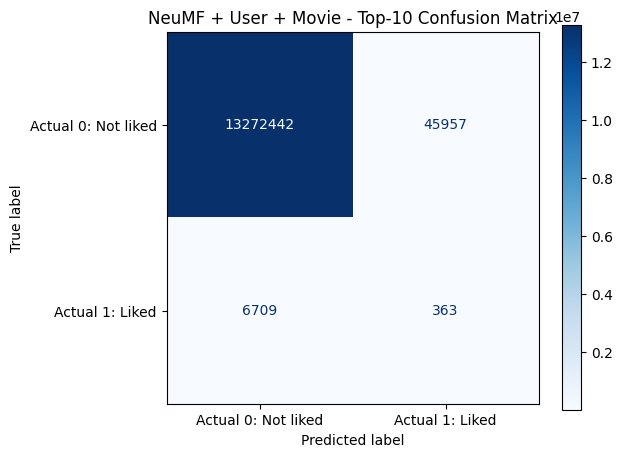


Classification report for NeuMF + User + Movie at Top-10:
              precision    recall  f1-score   support

   Not liked     0.9995    0.9965    0.9980  13318399
       Liked     0.0078    0.0513    0.0136      7072

    accuracy                         0.9960  13325471
   macro avg     0.5037    0.5239    0.5058  13325471
weighted avg     0.9990    0.9960    0.9975  13325471



,user_idx,movie_idx,actual,predicted,error_type
0,0,41,1,0,False Negative
1,0,133,0,1,False Positive
2,0,203,0,1,False Positive
3,0,288,0,1,False Positive
4,0,425,0,1,False Positive
5,0,503,0,1,False Positive
6,0,776,0,1,False Positive
7,0,2273,0,1,False Positive
8,0,2360,0,1,False Positive
9,0,2607,0,1,False Positive


In [ ]:
def topk_confusion_matrix_eval_exp1(model, eval_df, user_train_pos, num_movies, device, k=10):
    model.eval()

    # Build relevant items per user from eval_df
    user_relevant = {}
    for _, row in eval_df.iterrows():
        u = int(row["user_idx"])
        m = int(row["movie_idx"])
        if float(row["rating"]) >= POSITIVE_THRESHOLD:
            user_relevant.setdefault(u, set()).add(m)

    eval_users = list(user_relevant.keys())
    all_movies = np.arange(num_movies)

    y_true_all = []
    y_pred_all = []
    error_rows = []

    with torch.no_grad():
        for u in eval_users:
            relevant = user_relevant[u]
            seen = user_train_pos.get(u, set())
            candidate_movies = np.array([m for m in all_movies if m not in seen], dtype=np.int64)

            if len(candidate_movies) == 0:
                continue

            candidate_tensor = torch.tensor(candidate_movies, dtype=torch.long, device=device)
            user_tensor = torch.full((len(candidate_movies),), u, dtype=torch.long, device=device)

            # Build all side-feature batches required by NeuMFExp1.forward
            user_demo_np = np.repeat(user_feature_matrix[u][None, :], len(candidate_movies), axis=0)
            movie_side_np = movie_side_matrix[candidate_movies]
            cast_idx_np = movie_side["cast_idx"][candidate_movies]
            director_idx_np = movie_side["dir_idx"][candidate_movies]

            user_demo_batch = torch.tensor(user_demo_np, dtype=torch.long, device=device)
            movie_side_batch = torch.tensor(movie_side_np, dtype=torch.float32, device=device)
            cast_idx_batch = torch.tensor(cast_idx_np, dtype=torch.long, device=device)
            director_idx_batch = torch.tensor(director_idx_np, dtype=torch.long, device=device)

            scores = model(
                user_tensor,
                candidate_tensor,
                user_demo_batch,
                movie_side_batch,
                cast_idx_batch,
                director_idx_batch,
            ).detach().cpu().numpy()

            # Top-K predicted positives
            topk_idx = np.argsort(scores)[-k:]
            topk_movies = set(candidate_movies[topk_idx])

            # Evaluate every candidate movie for this user
            for m in candidate_movies:
                true_label = 1 if m in relevant else 0
                pred_label = 1 if m in topk_movies else 0

                y_true_all.append(true_label)
                y_pred_all.append(pred_label)

                if true_label != pred_label:
                    error_rows.append({
                        "user_idx": u,
                        "movie_idx": int(m),
                        "actual": true_label,
                        "predicted": pred_label,
                        "error_type": (
                            "False Negative" if true_label == 1 and pred_label == 0
                            else "False Positive"
                        )
                    })

    cm = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])
    errors_df = pd.DataFrame(error_rows)

    return cm, errors_df, np.array(y_true_all), np.array(y_pred_all)

# Run custom evaluation
cm_1, errors_1, y_true_1, y_pred_1 = topk_confusion_matrix_eval_exp1(
    model=model_exp1,
    eval_df=test_df,
    user_train_pos=user_train_pos,
    num_movies=num_movies,
    device=device,
    k=10
)

# Plot the results
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_1,
    display_labels=["Actual 0: Not liked", "Actual 1: Liked"]
)
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("NeuMF + User + Movie - Top-10 Confusion Matrix")
plt.show()

print("\nClassification report for NeuMF + User + Movie at Top-10:")
print(classification_report(
    y_true_1,
    y_pred_1,
    target_names=["Not liked", "Liked"],
    digits=4
))

errors_1.head(20)


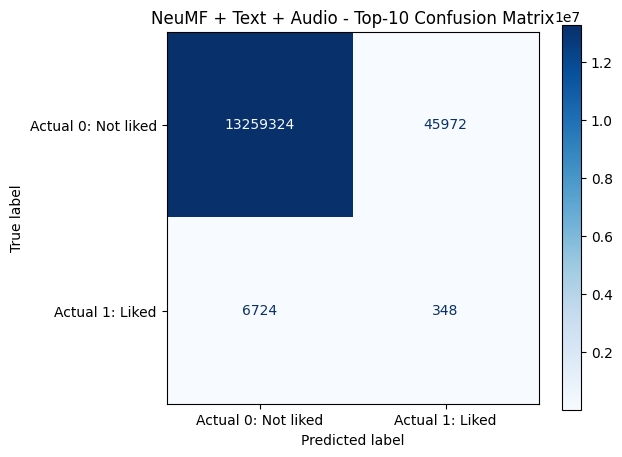


Classification report for NeuMF + Text + Audio at Top-10:
              precision    recall  f1-score   support

   Not liked     0.9995    0.9965    0.9980  13305296
       Liked     0.0075    0.0492    0.0130      7072

    accuracy                         0.9960  13312368
   macro avg     0.5035    0.5229    0.5055  13312368
weighted avg     0.9990    0.9960    0.9975  13312368



,user_idx,movie_idx,actual,predicted,error_type
0,0,41,1,0,False Negative
1,0,203,0,1,False Positive
2,0,288,0,1,False Positive
3,0,421,0,1,False Positive
4,0,425,0,1,False Positive
5,0,923,0,1,False Positive
6,0,1167,0,1,False Positive
7,0,1286,1,0,False Negative
8,0,1633,0,1,False Positive
9,0,1655,0,1,False Positive


In [ ]:
def topk_confusion_matrix_eval_exp2a(model, eval_df, user_train_pos, num_movies, device, k=10):
    model.eval()

    # Build relevant items per user from eval_df
    user_relevant = {}
    for _, row in eval_df.iterrows():
        u = int(row["user_idx"])
        m = int(row["movie_idx"])
        if float(row["rating"]) >= POSITIVE_THRESHOLD:
            user_relevant.setdefault(u, set()).add(m)

    eval_users = list(user_relevant.keys())
    all_movies = np.arange(num_movies)

    y_true_all = []
    y_pred_all = []
    error_rows = []

    with torch.no_grad():
        for u in eval_users:
            relevant = user_relevant[u]
            seen = user_train_pos.get(u, set())
            candidate_movies = np.array([m for m in all_movies if m not in seen], dtype=np.int64)

            if len(candidate_movies) == 0:
                continue

            candidate_tensor = torch.tensor(candidate_movies, dtype=torch.long, device=device)
            user_tensor = torch.full((len(candidate_movies),), u, dtype=torch.long, device=device)

            # Build all feature batches required by NeuMFExp2a.forward
            user_demo_np = np.repeat(user_feature_matrix_2a[u][None, :], len(candidate_movies), axis=0)
            movie_struct_np = movie_struct_matrix_2a[candidate_movies]
            cast_idx_np = cast_indices_matrix_2a[candidate_movies]
            dir_idx_np = dir_indices_matrix_2a[candidate_movies]
            text_np = text_emb_matrix_2a[candidate_movies]
            audio_np = audio_emb_matrix_2a[candidate_movies]

            user_demo_batch = torch.tensor(user_demo_np, dtype=torch.long, device=device)
            movie_struct_batch = torch.tensor(movie_struct_np, dtype=torch.float32, device=device)
            cast_idx_batch = torch.tensor(cast_idx_np, dtype=torch.long, device=device)
            dir_idx_batch = torch.tensor(dir_idx_np, dtype=torch.long, device=device)
            text_batch = torch.tensor(text_np, dtype=torch.float32, device=device)
            audio_batch = torch.tensor(audio_np, dtype=torch.float32, device=device)

            scores = model(
                user_tensor,
                candidate_tensor,
                user_demo_batch,
                movie_struct_batch,
                cast_idx_batch,
                dir_idx_batch,
                text_batch,
                audio_batch,
            ).detach().cpu().numpy()

            # Top-K predicted positives
            topk_idx = np.argsort(scores)[-k:]
            topk_movies = set(candidate_movies[topk_idx])

            # Evaluate every candidate movie for this user
            for m in candidate_movies:
                true_label = 1 if m in relevant else 0
                pred_label = 1 if m in topk_movies else 0

                y_true_all.append(true_label)
                y_pred_all.append(pred_label)

                if true_label != pred_label:
                    error_rows.append({
                        "user_idx": u,
                        "movie_idx": int(m),
                        "actual": true_label,
                        "predicted": pred_label,
                        "error_type": (
                            "False Negative" if true_label == 1 and pred_label == 0
                            else "False Positive"
                        )
                    })

    cm = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])
    errors_df = pd.DataFrame(error_rows)

    return cm, errors_df, np.array(y_true_all), np.array(y_pred_all)

# Run custom evaluation for Exp 2a
cm_2, errors_2, y_true_2, y_pred_2 = topk_confusion_matrix_eval_exp2a(
    model=model_2a,
    eval_df=test_df_2a,
    user_train_pos=train_seen_2a,  # Use training seen items
    num_movies=num_movies_2a,
    device=device,
    k=10
)

# Plot the results
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_2,
    display_labels=["Actual 0: Not liked", "Actual 1: Liked"]
)
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("NeuMF + Text + Audio - Top-10 Confusion Matrix")
plt.show()

print("\nClassification report for NeuMF + Text + Audio at Top-10:")
print(classification_report(
    y_true_2,
    y_pred_2,
    target_names=["Not liked", "Liked"],
    digits=4
))

errors_2.head(20)


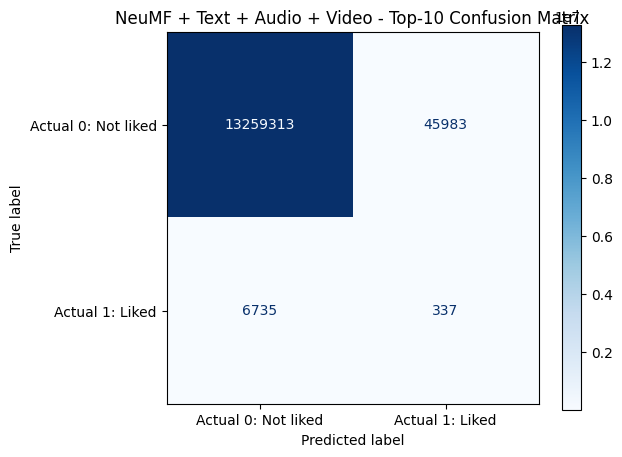


Classification report for NeuMF + Text + Audio + Video at Top-10:
              precision    recall  f1-score   support

   Not liked     0.9995    0.9965    0.9980  13305296
       Liked     0.0073    0.0477    0.0126      7072

    accuracy                         0.9960  13312368
   macro avg     0.5034    0.5221    0.5053  13312368
weighted avg     0.9990    0.9960    0.9975  13312368



,user_idx,movie_idx,actual,predicted,error_type
0,0,41,1,0,False Negative
1,0,203,0,1,False Positive
2,0,288,0,1,False Positive
3,0,425,0,1,False Positive
4,0,923,0,1,False Positive
5,0,1165,0,1,False Positive
6,0,1690,0,1,False Positive
7,0,1972,0,1,False Positive
8,0,1973,0,1,False Positive
9,0,2273,0,1,False Positive


In [ ]:
def topk_confusion_matrix_eval_exp2b(model, eval_df, user_train_pos, num_movies, device, k=10):
    model.eval()

    # Build relevant items per user from eval_df
    user_relevant = {}
    for _, row in eval_df.iterrows():
        u = int(row["user_idx"])
        m = int(row["movie_idx"])
        if float(row["rating"]) >= POSITIVE_THRESHOLD:
            user_relevant.setdefault(u, set()).add(m)

    eval_users = list(user_relevant.keys())
    all_movies = np.arange(num_movies)

    y_true_all = []
    y_pred_all = []
    error_rows = []

    with torch.no_grad():
        for u in eval_users:
            relevant = user_relevant[u]
            seen = user_train_pos.get(u, set())
            candidate_movies = np.array([m for m in all_movies if m not in seen], dtype=np.int64)

            if len(candidate_movies) == 0:
                continue

            candidate_tensor = torch.tensor(candidate_movies, dtype=torch.long, device=device)
            user_tensor = torch.full((len(candidate_movies),), u, dtype=torch.long, device=device)

            # Build all feature batches required by NeuMFExp2b.forward
            user_demo_np = np.repeat(user_feature_matrix_2b[u][None, :], len(candidate_movies), axis=0)
            movie_struct_np = movie_struct_matrix_2b[candidate_movies]
            cast_idx_np = cast_indices_matrix_2b[candidate_movies]
            dir_idx_np = dir_indices_matrix_2b[candidate_movies]
            text_np = text_emb_matrix_2b[candidate_movies]
            audio_np = audio_emb_matrix_2b[candidate_movies]
            video_np = video_emb_matrix_2b[candidate_movies]

            user_demo_batch = torch.tensor(user_demo_np, dtype=torch.long, device=device)
            movie_struct_batch = torch.tensor(movie_struct_np, dtype=torch.float32, device=device)
            cast_idx_batch = torch.tensor(cast_idx_np, dtype=torch.long, device=device)
            dir_idx_batch = torch.tensor(dir_idx_np, dtype=torch.long, device=device)
            text_batch = torch.tensor(text_np, dtype=torch.float32, device=device)
            audio_batch = torch.tensor(audio_np, dtype=torch.float32, device=device)
            video_batch = torch.tensor(video_np, dtype=torch.float32, device=device)

            scores = model(
                user_tensor,
                candidate_tensor,
                user_demo_batch,
                movie_struct_batch,
                cast_idx_batch,
                dir_idx_batch,
                text_batch,
                audio_batch,
                video_batch,
            ).detach().cpu().numpy()

            # Top-K predicted positives
            topk_idx = np.argsort(scores)[-k:]
            topk_movies = set(candidate_movies[topk_idx])

            # Evaluate every candidate movie for this user
            for m in candidate_movies:
                true_label = 1 if m in relevant else 0
                pred_label = 1 if m in topk_movies else 0

                y_true_all.append(true_label)
                y_pred_all.append(pred_label)

                if true_label != pred_label:
                    error_rows.append({
                        "user_idx": u,
                        "movie_idx": int(m),
                        "actual": true_label,
                        "predicted": pred_label,
                        "error_type": (
                            "False Negative" if true_label == 1 and pred_label == 0
                            else "False Positive"
                        )
                    })

    cm = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])
    errors_df = pd.DataFrame(error_rows)

    return cm, errors_df, np.array(y_true_all), np.array(y_pred_all)

# Run custom evaluation for Exp 2b
cm_3, errors_3, y_true_3, y_pred_3 = topk_confusion_matrix_eval_exp2b(
    model=model_2b,
    eval_df=test_df_2b,
    user_train_pos=train_seen_2b,
    num_movies=num_movies_2b,
    device=device,
    k=10
)

# Plot the results
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_3,
    display_labels=["Actual 0: Not liked", "Actual 1: Liked"]
)
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("NeuMF + Text + Audio + Video - Top-10 Confusion Matrix")
plt.show()

print("\nClassification report for NeuMF + Text + Audio + Video at Top-10:")
print(classification_report(
    y_true_3,
    y_pred_3,
    target_names=["Not liked", "Liked"],
    digits=4
))

errors_3.head(20)


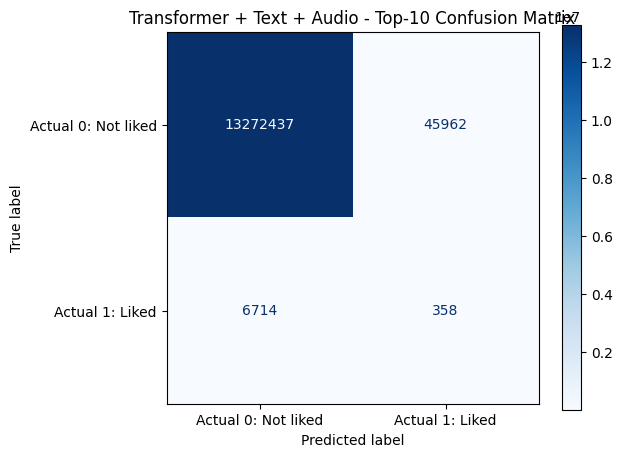


Classification report for Transformer + Text + Audio at Top-10:
              precision    recall  f1-score   support

   Not liked     0.9995    0.9965    0.9980  13318399
       Liked     0.0077    0.0506    0.0134      7072

    accuracy                         0.9960  13325471
   macro avg     0.5036    0.5236    0.5057  13325471
weighted avg     0.9990    0.9960    0.9975  13325471



,user_idx,movie_idx,actual,predicted,error_type
0,0,41,1,0,False Negative
1,0,203,0,1,False Positive
2,0,425,0,1,False Positive
3,0,562,0,1,False Positive
4,0,757,0,1,False Positive
5,0,767,0,1,False Positive
6,0,981,0,1,False Positive
7,0,1286,1,0,False Negative
8,0,1422,0,1,False Positive
9,0,1692,0,1,False Positive


In [ ]:
def topk_confusion_matrix_eval_transformer(model, eval_df, user_train_pos, num_movies, user_feature_matrix, banks, device, k=10):
    model.eval()

    # Build relevant items per user from eval_df
    user_relevant = {}
    for _, row in eval_df.iterrows():
        u = int(row["user_idx"])
        m = int(row["movie_idx"])
        if float(row["rating"]) >= POSITIVE_THRESHOLD:
            user_relevant.setdefault(u, set()).add(m)

    eval_users = list(user_relevant.keys())
    all_movies = np.arange(num_movies)

    y_true_all = []
    y_pred_all = []
    error_rows = []

    with torch.no_grad():
        for u in eval_users:
            relevant = user_relevant[u]
            seen = user_train_pos.get(u, set())
            candidate_movies = np.array([m for m in all_movies if m not in seen], dtype=np.int64)
            if len(candidate_movies) == 0:
                continue

            user_idx_t = torch.tensor([u], dtype=torch.long, device=device)
            user_demo_t = torch.tensor(user_feature_matrix[u][None, :], dtype=torch.long, device=device)

            scores = model.score_candidates_for_user(
                user_idx=user_idx_t,
                user_demo=user_demo_t,
                candidate_idx=candidate_movies,
                banks=banks,
                chunk_size=1024,
            )

            topk_idx = np.argsort(scores)[-k:]
            topk_movies = set(candidate_movies[topk_idx])

            for m in candidate_movies:
                true_label = 1 if m in relevant else 0
                pred_label = 1 if m in topk_movies else 0

                y_true_all.append(true_label)
                y_pred_all.append(pred_label)

                if true_label != pred_label:
                    error_rows.append({
                        "user_idx": u,
                        "movie_idx": int(m),
                        "actual": true_label,
                        "predicted": pred_label,
                        "error_type": "False Negative" if true_label == 1 else "False Positive",
                    })

    cm = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])
    errors_df = pd.DataFrame(error_rows)
    return cm, errors_df, np.array(y_true_all), np.array(y_pred_all)


# Exp 3a (Transformer + Text + Audio)
movie_struct_bank_3a = torch.tensor(movie_side_matrix, dtype=torch.float32, device=device)
cast_bank_3a = torch.tensor(movie_side["cast_idx"], dtype=torch.long, device=device)
director_bank_3a = torch.tensor(movie_side["dir_idx"], dtype=torch.long, device=device)
text_bank_3a = torch.tensor(text_emb_matrix_2a, dtype=torch.float32, device=device)
audio_bank_3a = torch.tensor(audio_emb_matrix_2a, dtype=torch.float32, device=device)

banks_3a = (movie_struct_bank_3a, cast_bank_3a, director_bank_3a, text_bank_3a, audio_bank_3a, None)

cm_4, errors_4, y_true_4, y_pred_4 = topk_confusion_matrix_eval_transformer(
    model=model_ta,
    eval_df=test_df,
    user_train_pos=user_train_pos,
    num_movies=num_movies,
    user_feature_matrix=user_feature_matrix,
    banks=banks_3a,
    device=device,
    k=10,
)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_4,
    display_labels=["Actual 0: Not liked", "Actual 1: Liked"],
)
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Transformer + Text + Audio - Top-10 Confusion Matrix")
plt.show()

print("\nClassification report for Transformer + Text + Audio at Top-10:")
print(classification_report(
    y_true_4,
    y_pred_4,
    target_names=["Not liked", "Liked"],
    digits=4,
))

errors_4.head(20)


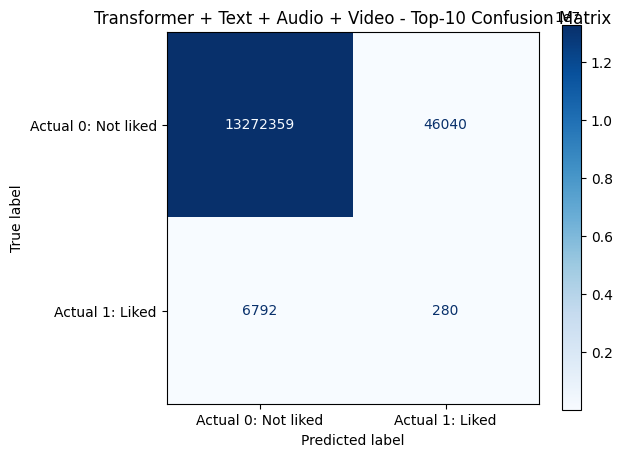


Classification report for Transformer + Text + Audio + Video at Top-10:
              precision    recall  f1-score   support

   Not liked     0.9995    0.9965    0.9980  13318399
       Liked     0.0060    0.0396    0.0105      7072

    accuracy                         0.9960  13325471
   macro avg     0.5028    0.5181    0.5043  13325471
weighted avg     0.9990    0.9960    0.9975  13325471



,user_idx,movie_idx,actual,predicted,error_type
0,0,29,0,1,False Positive
1,0,41,1,0,False Negative
2,0,288,0,1,False Positive
3,0,1286,1,0,False Negative
4,0,1492,0,1,False Positive
5,0,1690,0,1,False Positive
6,0,1691,0,1,False Positive
7,0,1692,0,1,False Positive
8,0,1827,0,1,False Positive
9,0,1931,0,1,False Positive


In [ ]:
# Exp 3b (Transformer + Text + Audio + Video)
movie_struct_bank_3b = torch.tensor(movie_side_matrix, dtype=torch.float32, device=device)
cast_bank_3b = torch.tensor(movie_side["cast_idx"], dtype=torch.long, device=device)
director_bank_3b = torch.tensor(movie_side["dir_idx"], dtype=torch.long, device=device)
text_bank_3b = torch.tensor(text_emb_matrix_2b, dtype=torch.float32, device=device)
audio_bank_3b = torch.tensor(audio_emb_matrix_2b, dtype=torch.float32, device=device)
video_bank_3b = torch.tensor(video_emb_matrix_2b, dtype=torch.float32, device=device)

banks_3b = (movie_struct_bank_3b, cast_bank_3b, director_bank_3b, text_bank_3b, audio_bank_3b, video_bank_3b)

cm_5, errors_5, y_true_5, y_pred_5 = topk_confusion_matrix_eval_transformer(
    model=model_tav,
    eval_df=test_df,
    user_train_pos=user_train_pos,
    num_movies=num_movies,
    user_feature_matrix=user_feature_matrix,
    banks=banks_3b,
    device=device,
    k=10,
)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_5,
    display_labels=["Actual 0: Not liked", "Actual 1: Liked"],
)
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Transformer + Text + Audio + Video - Top-10 Confusion Matrix")
plt.show()

print("\nClassification report for Transformer + Text + Audio + Video at Top-10:")
print(classification_report(
    y_true_5,
    y_pred_5,
    target_names=["Not liked", "Liked"],
    digits=4,
))

errors_5.head(20)


# Combined Evaluation

In [ ]:
import pandas as pd
import os

def save_dict_to_parquet(data_dict, filename, output_dir):
    """Converts a dictionary to a pandas DataFrame and saves it as a parquet file."""
    df = pd.DataFrame([data_dict])
    filepath = os.path.join(output_dir, f'{filename}.parquet')
    df.to_parquet(filepath, index=False)
    print(f"'{filename}.parquet' saved to {output_dir}")

# Ensure output_dir is defined from previous cells
output_dir = '/content/drive/MyDrive/BT4222 Project Datasets/final_evaluation_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save each dictionary
save_dict_to_parquet(exp1_results, "exp1_results", output_dir)
save_dict_to_parquet(exp2a_results_dict, "exp2a_results_dict", output_dir)
save_dict_to_parquet(results["Exp 2b"], "exp2b_results_dict", output_dir)
save_dict_to_parquet(test_ta, "test_ta", output_dir)
save_dict_to_parquet(test_tav, "test_tav", output_dir)


'exp1_results.parquet' saved to /content/drive/MyDrive/BT4222 Project Datasets/final_evaluation_data
'exp2a_results_dict.parquet' saved to /content/drive/MyDrive/BT4222 Project Datasets/final_evaluation_data
'exp2b_results_dict.parquet' saved to /content/drive/MyDrive/BT4222 Project Datasets/final_evaluation_data
'test_ta.parquet' saved to /content/drive/MyDrive/BT4222 Project Datasets/final_evaluation_data
'test_tav.parquet' saved to /content/drive/MyDrive/BT4222 Project Datasets/final_evaluation_data


In [ ]:
import pandas as pd
import os

output_dir = '/content/drive/MyDrive/BT4222 Project Datasets/final_evaluation_data'
results={}
exp1_results = pd.read_parquet(os.path.join(output_dir, 'exp1_results.parquet')).iloc[0].to_dict()
exp2a_results_dict = pd.read_parquet(os.path.join(output_dir, 'exp2a_results_dict.parquet')).iloc[0].to_dict()
results["Exp 2b"] = pd.read_parquet(os.path.join(output_dir, 'exp2b_results_dict.parquet')).iloc[0].to_dict()
test_ta = pd.read_parquet(os.path.join(output_dir, 'test_ta.parquet')).iloc[0].to_dict()
test_tav = pd.read_parquet(os.path.join(output_dir, 'test_tav.parquet')).iloc[0].to_dict()

print("Loaded exp1_results:", exp1_results)
print("Loaded exp2a_results_dict:", exp2a_results_dict)
print("Loaded exp2b_results_dict:", results["Exp 2b"])
print("Loaded test_ta:", test_ta)
print("Loaded test_tav:", test_tav)


Loaded exp1_results: {'Precision@5': 0.10902417962003454, 'Recall@5': 0.35610967184801384, 'NDCG@5': 0.2587806357454008, 'Precision@10': 0.08154145077720207, 'Recall@10': 0.5317357512953368, 'NDCG@10': 0.32545971037430266}
Loaded exp2a_results_dict: {'Precision@5': 0.1128238341968912, 'Recall@5': 0.3703583765112263, 'NDCG@5': 0.26457180653881507, 'Precision@10': 0.08391623488773747, 'Recall@10': 0.5445811744386874, 'NDCG@10': 0.329004107285813}
Loaded exp2b_results_dict: {'Precision@5': 0.11286701208981001, 'Recall@5': 0.3701424870466321, 'NDCG@5': 0.26561777212637555, 'Precision@10': 0.08363557858376511, 'Recall@10': 0.5415587219343696, 'NDCG@10': 0.32903886284618045}
Loaded test_ta: {'Precision@5': 0.10829015544041451, 'Precision@10': 0.08171416234887738, 'Recall@5': 0.35567789291882557, 'Recall@10': 0.5324913644214162, 'NDCG@5': 0.2564468012934103, 'NDCG@10': 0.3206342914381268, 'num_users_evaluated': 4632.0}
Loaded test_tav: {'Precision@5': 0.09715025906735753, 'Precision@10': 0.07

In [ ]:
def get_standardized_metrics(res_dict):
    # Helper to extract and capitalize keys for consistency across models
    return {
        "Precision@5": res_dict.get("Precision@5", res_dict.get("precision@5", 0)),
        "Recall@5": res_dict.get("Recall@5", res_dict.get("recall@5", 0)),
        "NDCG@5": res_dict.get("NDCG@5", res_dict.get("ndcg@5", 0)),
        "Precision@10": res_dict.get("Precision@10", res_dict.get("precision@10", 0)),
        "Recall@10": res_dict.get("Recall@10", res_dict.get("recall@10", 0)),
        "NDCG@10": res_dict.get("NDCG@10", res_dict.get("ndcg@10", 0)),
    }

# Summary comparison table
summary = pd.DataFrame([
    {"Model": "NeuMF + User + Movie", **get_standardized_metrics(exp1_results)},
    {"Model": "NeuMF + User + Movie + Text + Audio", **get_standardized_metrics(exp2a_results_dict)},
    {"Model": "NeuMF + User + Movie + Text + Audio + Video", **get_standardized_metrics(results["Exp 2b"])},
    {"Model": "Transformer + Text + Audio", **get_standardized_metrics(test_ta)},
    {"Model": "Transformer + Text + Audio + Video", **get_standardized_metrics(test_tav)},
])
print("\n" + summary.to_string(index=False))

# Save the experiment summary results
summary.to_csv(os.path.join(output_dir, "experiment_results.csv"), index=False)
print(f"\nSaved experiment results to {output_dir}/experiment_results.csv")

# Note: Top-20 recommendations saving is already handled in the Exp 2b section.



                                      Model  Precision@5  Recall@5   NDCG@5  Precision@10  Recall@10  NDCG@10
                       NeuMF + User + Movie     0.109024  0.356110 0.258781      0.081541   0.531736 0.325460
        NeuMF + User + Movie + Text + Audio     0.112824  0.370358 0.264572      0.083916   0.544581 0.329004
NeuMF + User + Movie + Text + Audio + Video     0.112867  0.370142 0.265618      0.083636   0.541559 0.329039
                 Transformer + Text + Audio     0.108290  0.355678 0.256447      0.081714   0.532491 0.320634
         Transformer + Text + Audio + Video     0.097150  0.315199 0.223868      0.073964   0.476684 0.282683

Saved experiment results to /content/drive/MyDrive/BT4222 Project Datasets/final_evaluation_data/experiment_results.csv


# Further Study

##Multi-Branch Validation (MF vs MLP)

This ablation isolates branch contribution in `Exp 2a` (`NeuMF + text + audio`) by running two controlled fine-tuning experiments from the same best checkpoint:
- Freeze `MF` tower (`gmf_user_emb`, `gmf_movie_emb`) and train the rest.
- Freeze `MLP` tower (user/movie MLP embeddings + demographic + cast/director + text/audio projections + MLP layers) and train the rest.

The branch whose freezing causes the larger performance drop contributes more to recommendation quality.

##Test 30 Interactions per user

In [ ]:
# ============================================================
# Branch-freeze ablation for Exp 2a
# ============================================================
import copy


def apply_branch_freeze_2a(model, freeze_branch):
    """
    freeze_branch:
      - "mf": freeze GMF tower only
      - "mlp": freeze MLP+multimodal tower only
    """
    assert freeze_branch in {"mf", "mlp"}

    mlp_prefixes = (
        "mlp_user_emb", "mlp_movie_emb",
        "gender_emb", "age_emb", "occ_emb", "region_emb",
        "cast_emb", "director_emb",
        "text_proj", "audio_proj", "mlp"
    )

    for name, param in model.named_parameters():
        if freeze_branch == "mf":
            should_freeze = name.startswith("gmf_user_emb") or name.startswith("gmf_movie_emb")
        else:
            should_freeze = name.startswith(mlp_prefixes)
        param.requires_grad = not should_freeze

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    return trainable, frozen


def run_branch_ablation_2a(freeze_branch, num_epochs=10, patience=4, max_users_val=500):
    model = NeuMFExp2a(
        num_users=num_users_2a,
        num_movies=num_movies_2a,
        num_genders=num_genders_2a,
        num_ages=num_ages_2a,
        num_occs=num_occs_2a,
        num_regions=num_regions_2a,
        num_struct_features=movie_struct_matrix_2a.shape[1],
        num_cast_tokens=num_cast_tokens_2a,
        num_director_tokens=num_dir_tokens_2a,
        text_dim=text_dim_2a,
        audio_dim=audio_dim_2a,
        mf_dim=64, mlp_emb_dim=64, demo_emb_dim=16, person_emb_dim=16,
        proj_dim=64, hidden_dims=(256, 128, 64), dropout=0.2,
    ).to(device)

    model.load_state_dict(copy.deepcopy(best_state_2a))
    trainable_params, frozen_params = apply_branch_freeze_2a(model, freeze_branch)

    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=1e-4, weight_decay=1e-5
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )

    best_val_ndcg = -1.0
    best_state = None
    no_improve = 0

    print("\n" + "=" * 72)
    print(f"Running Exp 2a ablation: freeze_{freeze_branch.upper()} branch")
    print(f"Trainable params: {trainable_params:,} | Frozen params: {frozen_params:,}")
    print("=" * 72)

    for epoch in range(1, num_epochs + 1):
        train_loss = run_epoch_2a(model, train_loader_2a, optimizer)
        val_metrics = evaluate_topk_2a(model, k=10, max_users=max_users_val, split="val")
        val_ndcg = val_metrics["NDCG@10"]

        scheduler.step(val_ndcg)
        print(
            f"[{freeze_branch.upper()} frozen] Epoch {epoch:02d} | "
            f"Loss: {train_loss:.4f} | "
            f"Val P@10: {val_metrics['Precision@10']:.4f} | "
            f"Val R@10: {val_metrics['Recall@10']:.4f} | "
            f"Val NDCG@10: {val_ndcg:.4f}"
        )

        if val_ndcg > best_val_ndcg:
            best_val_ndcg = val_ndcg
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping ({freeze_branch.upper()} frozen) at epoch {epoch}.")
                break

    model.load_state_dict(best_state)

    test_k5 = evaluate_topk_2a(model, k=5, split="test")
    test_k10 = evaluate_topk_2a(model, k=10, split="test")

    return {
        "setting": f"freeze_{freeze_branch}",
        "trainable_params": trainable_params,
        "frozen_params": frozen_params,
        "val_ndcg@10": best_val_ndcg,
        "test_precision@5": test_k5["Precision@5"],
        "test_recall@5": test_k5["Recall@5"],
        "test_ndcg@5": test_k5["NDCG@5"],
        "test_precision@10": test_k10["Precision@10"],
        "test_recall@10": test_k10["Recall@10"],
        "test_ndcg@10": test_k10["NDCG@10"],
    }


# Full-model baseline from Exp 2a best checkpoint (already computed above)
full_exp2a_row = {
    "setting": "full_exp2a",
    "trainable_params": sum(p.numel() for p in model_2a.parameters()),
    "frozen_params": 0,
    "val_ndcg@10": best_val_ndcg_2a,
    "test_precision@5": metrics_2a_k5["Precision@5"],
    "test_recall@5": metrics_2a_k5["Recall@5"],
    "test_ndcg@5": metrics_2a_k5["NDCG@5"],
    "test_precision@10": metrics_2a_k10["Precision@10"],
    "test_recall@10": metrics_2a_k10["Recall@10"],
    "test_ndcg@10": metrics_2a_k10["NDCG@10"],
}

freeze_mf_res = run_branch_ablation_2a("mf", num_epochs=10, patience=4, max_users_val=500)
freeze_mlp_res = run_branch_ablation_2a("mlp", num_epochs=10, patience=4, max_users_val=500)

ablation_rows_2a = [full_exp2a_row, freeze_mf_res, freeze_mlp_res]
ablation_df_2a = pd.DataFrame(ablation_rows_2a)

# Add both delta and drop columns against full model for all key metrics.
metrics_for_drop = [
    "val_ndcg@10",
    "test_precision@5", "test_recall@5", "test_ndcg@5",
    "test_precision@10", "test_recall@10", "test_ndcg@10",
]

for metric in metrics_for_drop:
    ablation_df_2a[f"drop_{metric}_from_full"] = full_exp2a_row[metric] - ablation_df_2a[metric]

print("\n" + "=" * 110)
print("EXP 2a BRANCH ABLATION TABLE (includes precision/recall/ndcg deltas and drops vs full model)")
print("=" * 110)
display(ablation_df_2a)

# Optional direct readout for ranking branch contribution using NDCG@10 drop.
mf_drop_ndcg10 = full_exp2a_row["test_ndcg@10"] - freeze_mf_res["test_ndcg@10"]
mlp_drop_ndcg10 = full_exp2a_row["test_ndcg@10"] - freeze_mlp_res["test_ndcg@10"]

if mf_drop_ndcg10 > mlp_drop_ndcg10:
    print("Conclusion (by NDCG@10 drop): MF branch contributes more.")
elif mlp_drop_ndcg10 > mf_drop_ndcg10:
    print("Conclusion (by NDCG@10 drop): MLP branch contributes more.")
else:
    print("Conclusion (by NDCG@10 drop): Both branches contribute similarly.")


Running Exp 2a ablation: freeze_MF branch
Trainable params: 883,281 | Frozen params: 571,008
[MF frozen] Epoch 01 | Loss: 0.0623 | Val P@10: 0.0924 | Val R@10: 0.5940 | Val NDCG@10: 0.3807
[MF frozen] Epoch 02 | Loss: 0.0632 | Val P@10: 0.0924 | Val R@10: 0.5940 | Val NDCG@10: 0.3683
[MF frozen] Epoch 03 | Loss: 0.0615 | Val P@10: 0.0932 | Val R@10: 0.5980 | Val NDCG@10: 0.3715
[MF frozen] Epoch 04 | Loss: 0.0582 | Val P@10: 0.0962 | Val R@10: 0.6170 | Val NDCG@10: 0.3818
[MF frozen] Epoch 05 | Loss: 0.0574 | Val P@10: 0.0950 | Val R@10: 0.6070 | Val NDCG@10: 0.3733
[MF frozen] Epoch 06 | Loss: 0.0565 | Val P@10: 0.0928 | Val R@10: 0.5910 | Val NDCG@10: 0.3781
[MF frozen] Epoch 07 | Loss: 0.0547 | Val P@10: 0.0948 | Val R@10: 0.6120 | Val NDCG@10: 0.3887
[MF frozen] Epoch 08 | Loss: 0.0540 | Val P@10: 0.0934 | Val R@10: 0.6020 | Val NDCG@10: 0.3828
[MF frozen] Epoch 09 | Loss: 0.0512 | Val P@10: 0.0940 | Val R@10: 0.6060 | Val NDCG@10: 0.3814
[MF frozen] Epoch 10 | Loss: 0.0517 | Val 

,setting,trainable_params,frozen_params,val_ndcg@10,test_precision@5,test_recall@5,test_ndcg@5,test_precision@10,test_recall@10,test_ndcg@10,drop_val_ndcg@10_from_full,drop_test_precision@5_from_full,drop_test_recall@5_from_full,drop_test_ndcg@5_from_full,drop_test_precision@10_from_full,drop_test_recall@10_from_full,drop_test_ndcg@10_from_full
0,full_exp2a,1454289,0,0.382130,0.112824,0.370358,0.264572,0.083916,0.544581,0.329004,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,freeze_mf,883281,571008,0.388735,0.114983,0.375972,0.269482,0.084715,0.548683,0.335334,-0.006605,-0.002159,-0.005613,-0.004911,-0.000799,-0.004102,-0.006330
2,freeze_mlp,571137,883152,0.376451,0.113687,0.369495,0.266200,0.083290,0.542314,0.327862,0.005678,-0.000864,0.000864,-0.001628,0.000626,0.002267,0.001142


Conclusion (by NDCG@10 drop): MLP branch contributes more.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
from google.colab import userdata

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import re
import ast
import time
import requests
from tqdm import tqdm
import zipfile
import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random, math, copy

# Create a directory to store the parquet files if it doesn't exist
# import os
# output_dir = '/content/drive/MyDrive/BT4222 Project Datasets/preprocessed_data'
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)

In [ ]:
### CHECKPOINT: Can run "Imports" cells and then directly run from here
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer

# Load preprocessed data
movie_features_df = pd.read_parquet('/content/drive/MyDrive/BT4222 Project Datasets/preprocessed_data/movie_features_df.parquet')
user_features_df = pd.read_parquet('/content/drive/MyDrive/BT4222 Project Datasets/preprocessed_data/user_features_df.parquet')
movie_embeddings_df = pd.read_parquet('/content/drive/MyDrive/BT4222 Project Datasets/preprocessed_data/movie_embeddings.parquet')
ratings_filtered = pd.read_parquet('/content/drive/MyDrive/BT4222 Project Datasets/preprocessed_data/ratings_filtered.parquet')

# User-level stratified sampling: keep 30 most recent interactions per user
MAX_INTERACTIONS = 30

ratings_sorted = ratings_filtered.sort_values(["user_id", "timestamp"])
ratings_sampled = ratings_sorted.groupby("user_id").tail(MAX_INTERACTIONS).reset_index(drop=True)

# Remove users with fewer than 3 interactions (need at least 1 for each split)
user_counts = ratings_sampled["user_id"].value_counts()
valid_users = user_counts[user_counts >= 3].index
ratings_sampled = ratings_sampled[ratings_sampled["user_id"].isin(valid_users)].copy()

print(f"After sampling: {len(ratings_sampled)} ratings, "
      f"{ratings_sampled['user_id'].nunique()} users, "
      f"{ratings_sampled['movie_id'].nunique()} movies")
print(f"Avg interactions per user: {ratings_sampled.groupby('user_id').size().mean():.1f}")

After sampling: 175536 ratings, 6040 users, 3014 movies
Avg interactions per user: 29.1


In [ ]:
# Build one shared universe for all experiments: movies with text + audio + video + metadata + ratings
text_movie_ids = set(movie_embeddings_df[movie_embeddings_df["text_mpnet_embedding"].notna()]["movie_id"].values)
audio_movie_ids = set(movie_embeddings_df[movie_embeddings_df["audio_whisper_embedding"].notna()]["movie_id"].values)
video_movie_ids = set(movie_embeddings_df[movie_embeddings_df["video_mvit_embedding"].notna()]["movie_id"].values)
rated_movie_ids = set(ratings_sampled["movie_id"].unique())
metadata_movie_ids = set(movie_features_df["movie_id"].unique())

shared_movie_ids = text_movie_ids & audio_movie_ids & video_movie_ids & rated_movie_ids & metadata_movie_ids

ratings_shared = ratings_sampled[ratings_sampled["movie_id"].isin(shared_movie_ids)].copy()
print(f"Shared universe movies (text+audio+video): {len(shared_movie_ids)}")
print(f"Ratings after shared-universe filter: {len(ratings_shared)}")

def temporal_split(group):
    """Split a user's interactions by timestamp: 70% train, 15% val, 15% test."""
    group = group.sort_values("timestamp")
    n = len(group)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    # Ensure at least 1 interaction in each split
    train_end = max(train_end, 1)
    val_end = max(val_end, train_end + 1)
    val_end = min(val_end, n - 1)  # at least 1 for test

    group = group.copy()
    group["split"] = "train"
    group.iloc[train_end:val_end, group.columns.get_loc("split")] = "val"
    group.iloc[val_end:, group.columns.get_loc("split")] = "test"
    return group

ratings_split = ratings_shared.groupby("user_id", group_keys=False).apply(temporal_split)

train_df = ratings_split[ratings_split["split"] == "train"].copy()
val_df = ratings_split[ratings_split["split"] == "val"].copy()
test_df = ratings_split[ratings_split["split"] == "test"].copy()

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Users in train/val/test: {train_df['user_id'].nunique()}/{val_df['user_id'].nunique()}/{test_df['user_id'].nunique()}")

Shared universe movies (text+audio+video): 3014
Ratings after shared-universe filter: 175536
Train: 122499, Val: 23711, Test: 29326
Users in train/val/test: 6040/6040/6040


/tmp/ipykernel_2863/4202562122.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ratings_split = ratings_shared.groupby("user_id", group_keys=False).apply(temporal_split)


In [ ]:
# Re-index user and movie IDs to contiguous 0-based indices
user_enc = LabelEncoder()
movie_enc = LabelEncoder()

# Fit on all data to ensure consistent encoding
all_user_ids = ratings_split["user_id"].unique()
all_movie_ids = ratings_split["movie_id"].unique()

user_enc.fit(all_user_ids)
movie_enc.fit(all_movie_ids)

for df in [train_df, val_df, test_df]:
    df["user_idx"] = user_enc.transform(df["user_id"])
    df["movie_idx"] = movie_enc.transform(df["movie_id"])

num_users = len(user_enc.classes_)
num_movies = len(movie_enc.classes_)
movie_id_to_idx = dict(zip(movie_enc.classes_, range(num_movies)))
user_id_to_idx = dict(zip(user_enc.classes_, range(num_users)))

print(f"Num users: {num_users}, Num movies: {num_movies}")

# --- Encode user categorical features ---
POSITIVE_THRESHOLD = 4

gender_enc = LabelEncoder()
age_enc = LabelEncoder()
occ_enc = LabelEncoder()
region_enc = LabelEncoder()

user_feat = user_features_df[user_features_df["user_id"].isin(all_user_ids)].copy()
user_feat["user_idx"] = user_feat["user_id"].map(user_id_to_idx)

user_feat["gender_idx"] = gender_enc.fit_transform(user_feat["gender"])
user_feat["age_idx"] = age_enc.fit_transform(user_feat["age_bucket"])
user_feat["occ_idx"] = occ_enc.fit_transform(user_feat["occupation_group"])
user_feat["region_idx"] = region_enc.fit_transform(user_feat["region"])

num_genders = len(gender_enc.classes_)
num_ages = len(age_enc.classes_)
num_occs = len(occ_enc.classes_)
num_regions = len(region_enc.classes_)

user_feature_matrix = np.zeros((num_users, 4), dtype=np.int64)
for _, row in user_feat.iterrows():
    uid = int(row["user_idx"])
    user_feature_matrix[uid] = [row["gender_idx"], row["age_idx"], row["occ_idx"], row["region_idx"]]

# --- Encode movie features (genres + year) ---
movie_feat = movie_features_df[movie_features_df["movie_id"].isin(all_movie_ids)].copy()
movie_feat["movie_idx"] = movie_feat["movie_id"].map(movie_id_to_idx)
movie_feat = movie_feat.dropna(subset=["movie_idx"]).sort_values("movie_idx")
movie_feat["movie_idx"] = movie_feat["movie_idx"].astype(int)

# Multi-hot for genre
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(movie_feat["genre_list"])
num_genres = genre_matrix.shape[1]

# Normalize release_year
years = movie_feat["release_year"].fillna(movie_feat["release_year"].median()).values.astype(np.float32)
years_norm = (years - years.mean()) / (years.std() + 1e-8)

# Combined movie feature matrix: genres (multi-hot) + year (normalized)
movie_cat_features = np.column_stack([genre_matrix, years_norm.reshape(-1, 1)])

# --- Multimodal embeddings aligned by movie_idx ---
emb_df = movie_embeddings_df.copy()
emb_df["movie_idx"] = emb_df["movie_id"].map(movie_id_to_idx)
emb_df = emb_df.dropna(subset=["movie_idx"]).sort_values("movie_idx")

text_emb = np.stack(emb_df["text_mpnet_embedding"].values).astype(np.float32)
audio_emb = np.stack(emb_df["audio_whisper_embedding"].values).astype(np.float32)
video_emb = np.stack(emb_df["video_mvit_embedding"].values).astype(np.float32)

# Check for NaN/Inf
for name, emb in [("text", text_emb), ("audio", audio_emb), ("video", video_emb)]:
    if np.isnan(emb).any() or np.isinf(emb).any():
        print(f"WARNING: {name} has NaN/Inf — replacing with 0")
        emb[np.isnan(emb) | np.isinf(emb)] = 0

print(f"Text: {text_emb.shape}, Audio: {audio_emb.shape}, Video: {video_emb.shape}")
print(f"Movie cat features: {movie_cat_features.shape}, User features: {user_feature_matrix.shape}")

# --- Build per-user positive item sets (from training only) ---
user_train_pos = {}
for _, row in train_df.iterrows():
    u, m, r = int(row["user_idx"]), int(row["movie_idx"]), row["rating"]
    if u not in user_train_pos:
        user_train_pos[u] = set()
    if r >= POSITIVE_THRESHOLD:
        user_train_pos[u].add(m)

Num users: 6040, Num movies: 3014
Text: (3014, 768), Audio: (3014, 512), Video: (3014, 768)
Movie cat features: (3014, 19), User features: (6040, 4)


In [ ]:
# Cast/director embedding-ready index matrices (fixed length = 3 with 0 as PAD/UNK)
def normalize_people_list(x, max_len=3):
    if isinstance(x, (list, tuple, np.ndarray)):
        vals = []
        for v in x[:max_len]:
            if isinstance(v, str):
                v = v.strip()
                if v:
                    vals.append(v)
        return vals
    return []

movie_feat["first_three_casts_clean"] = movie_feat["first_three_casts"].apply(normalize_people_list)
movie_feat["first_three_directors_clean"] = movie_feat["first_three_directors"].apply(normalize_people_list)

cast_tokens = sorted({p for row in movie_feat["first_three_casts_clean"] for p in row})
dir_tokens = sorted({p for row in movie_feat["first_three_directors_clean"] for p in row})

cast_to_idx = {name: i + 1 for i, name in enumerate(cast_tokens)}
dir_to_idx = {name: i + 1 for i, name in enumerate(dir_tokens)}
num_cast_tokens = len(cast_to_idx) + 1  # +1 for PAD/UNK=0
num_dir_tokens = len(dir_to_idx) + 1    # +1 for PAD/UNK=0

def encode_people_tokens(people, vocab, max_len=3):
    ids = [vocab.get(p, 0) for p in people[:max_len]]
    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))
    return np.array(ids, dtype=np.int64)

cast_indices = np.stack(
    movie_feat["first_three_casts_clean"].apply(
        lambda x: encode_people_tokens(x, cast_to_idx, max_len=3)
    ).values
)

dir_indices = np.stack(
    movie_feat["first_three_directors_clean"].apply(
        lambda x: encode_people_tokens(x, dir_to_idx, max_len=3)
    ).values
)

print("cast_indices shape:", cast_indices.shape)
print("dir_indices shape:", dir_indices.shape)
print("num_cast_tokens:", num_cast_tokens)
print("num_dir_tokens:", num_dir_tokens)

# Numeric movie features
numeric_cols = ["release_year", "runtime_min"]
movie_num_df = movie_feat[numeric_cols].copy()

#filling nulls with median
for col in numeric_cols:
    movie_num_df[col] = movie_num_df[col].fillna(movie_num_df[col].median())

movie_num = movie_num_df.values.astype(np.float32)

# Standardize numeric features
movie_num_mean = movie_num.mean(axis=0, keepdims=True)
movie_num_std = movie_num.std(axis=0, keepdims=True) + 1e-8
movie_num = (movie_num - movie_num_mean) / movie_num_std

print("genre_matrix shape:", genre_matrix.shape)
print("movie_num shape:", movie_num.shape)

cast_indices shape: (3014, 3)
dir_indices shape: (3014, 3)
num_cast_tokens: 2743
num_dir_tokens: 2586
genre_matrix shape: (3014, 18)
movie_num shape: (3014, 2)


In [ ]:
movie_side_matrix = np.concatenate(
    [
        genre_matrix.astype(np.float32),
        movie_num.astype(np.float32),
    ],
    axis=1
)

# Unified movie-side container: tabular + cast indices + director indices
movie_side = {
    "tabular": movie_side_matrix,
    "cast_idx": cast_indices,
    "dir_idx": dir_indices,
}

print("movie_side_matrix shape:", movie_side["tabular"].shape)
print("movie_side_cast_idx shape:", movie_side["cast_idx"].shape)
print("movie_side_dir_idx shape:", movie_side["dir_idx"].shape)

movie_side_matrix shape: (3014, 20)
movie_side_cast_idx shape: (3014, 3)
movie_side_dir_idx shape: (3014, 3)


In [ ]:
#to track seen items, so dont recommend movies already seen
def build_user_seen_dict(df):
    seen = {}
    for _, row in df.iterrows():
        u = int(row["user_idx"])
        m = int(row["movie_idx"])
        seen.setdefault(u, set()).add(m)
    return seen


In [ ]:
# Build these BEFORE the training loop
train_seen = build_user_seen_dict(train_df)
val_seen = build_user_seen_dict(val_df)
test_seen = build_user_seen_dict(test_df)

val_relevant = {}
for _, row in val_df.iterrows():
    u = int(row["user_idx"])
    m = int(row["movie_idx"])
    r = float(row["rating"])
    if r >= POSITIVE_THRESHOLD:
        val_relevant.setdefault(u, set()).add(m)

test_relevant = {}
for _, row in test_df.iterrows():
    u = int(row["user_idx"])
    m = int(row["movie_idx"])
    r = float(row["rating"])
    if r >= POSITIVE_THRESHOLD:
        test_relevant.setdefault(u, set()).add(m)

print("Users with relevant val items:", len(val_relevant))
print("Users with relevant test items:", len(test_relevant))

Users with relevant val items: 5351
Users with relevant test items: 5532


In [ ]:
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [ ]:
def dcg_at_k(rels, k):
    rels = np.asarray(rels)[:k]
    if rels.size == 0:
        return 0.0
    return np.sum(rels / np.log2(np.arange(2, rels.size + 2)))

def ndcg_at_k(ranked_items, relevant_items, k):
    rels = [1 if item in relevant_items else 0 for item in ranked_items[:k]]
    dcg = dcg_at_k(rels, k)
    ideal_len = min(len(relevant_items), k)
    ideal_rels = [1] * ideal_len
    idcg = dcg_at_k(ideal_rels, k)
    return dcg / idcg if idcg > 0 else 0.0

In [ ]:
@torch.no_grad()
def evaluate_topk_exp1(model, k=10, max_users=None, split="test"):
    model.eval()

    # Choose which split to evaluate on
    if split == "val":
        relevant_dict = val_relevant
        seen_dict = train_seen  # only exclude train items during val
    else:
        relevant_dict = test_relevant
        seen_dict = {u: train_seen.get(u, set()) | val_seen.get(u, set())
                     for u in test_relevant}

    #only evaluate users who appear in training (warm start)
    train_users = set(train_df["user_idx"].unique())
    users = sorted([u for u in relevant_dict.keys() if u in train_users])
    if max_users is not None:
        users = users[:max_users]

    precisions, recalls, ndcgs = [], [], []
    all_movies = set(range(num_movies))

    for u in users:
        relevant = relevant_dict.get(u, set())
        if len(relevant) == 0: #user dont like anything
            continue

        seen_before = seen_dict.get(u, set())
        neg_pool = list(all_movies - seen_before - relevant)
        #not sure how many sampled negatives shld b included
        sampled_negs = random.sample(neg_pool, min(99, len(neg_pool)))
        candidates = sorted(list(relevant)) + sampled_negs

        if len(candidates) == 0:
            continue

        #batched user movie indice for scoring all candidates at once
        user_idx_batch = torch.tensor([u] * len(candidates), dtype=torch.long, device=device)
        movie_idx_batch = torch.tensor(candidates, dtype=torch.long, device=device)

        user_demo_np = np.repeat(user_feature_matrix[u][None, :], len(candidates), axis=0)
        movie_side_np = movie_side["tabular"][candidates]
        cast_idx_np = movie_side["cast_idx"][candidates]
        dir_idx_np = movie_side["dir_idx"][candidates]

        #converted to tensor
        user_demo_batch = torch.tensor(user_demo_np, dtype=torch.long, device=device)
        movie_side_batch = torch.tensor(movie_side_np, dtype=torch.float32, device=device)
        cast_idx_batch = torch.tensor(cast_idx_np, dtype=torch.long, device=device)
        dir_idx_batch = torch.tensor(dir_idx_np, dtype=torch.long, device=device)

        scores = model(
            user_idx_batch,
            movie_idx_batch,
            user_demo_batch,
            movie_side_batch,
            cast_idx_batch,
            dir_idx_batch,
        )
        scores = scores.detach().cpu().numpy()

        ranked_idx = np.argsort(-scores)
        ranked_movies = [candidates[i] for i in ranked_idx[:k]]

        hits = sum(1 for m in ranked_movies if m in relevant)
        precision = hits / k
        recall = hits / len(relevant)
        ndcg = ndcg_at_k(ranked_movies, relevant, k)

        precisions.append(precision)
        recalls.append(recall)
        ndcgs.append(ndcg)

    return {
        f"Precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"Recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
        f"NDCG@{k}": float(np.mean(ndcgs)) if ndcgs else 0.0,
        "num_users_evaluated": len(precisions)
    }

In [ ]:
class Exp1BPRDataset(Dataset):
    def __init__(self, train_df, user_feature_matrix, movie_side,
                 num_movies, pos_threshold=4, neg_per_pos=4):
        self.user_feature_matrix = user_feature_matrix
        self.movie_side_matrix = movie_side["tabular"]
        self.cast_indices_matrix = movie_side["cast_idx"]
        self.dir_indices_matrix = movie_side["dir_idx"]
        self.num_movies = num_movies
        self.pos_threshold = pos_threshold
        self.neg_per_pos = neg_per_pos
        # popularity distribution for sampling harder negatives
        # movie_counts = np.zeros(num_movies, dtype=np.float32)
        # for _, row in train_df.iterrows():
        #   m = int(row["movie_idx"])
        #   movie_counts[m] += 1.0

        # movie_probs = np.power(movie_counts + 1e-8, 0.75)
        # movie_probs = movie_probs / movie_probs.sum()
        # self.movie_probs = movie_probs

        # positive interactions only
        pos_df = train_df[train_df["rating"] >= pos_threshold].copy()

        self.samples = []
        self.user_pos_items = {}

        # to duplicate positives to be paired with negative later
        for _, row in pos_df.iterrows():
            u = int(row["user_idx"])
            m = int(row["movie_idx"])
            #changed
            for _ in range(neg_per_pos):
                self.samples.append((u, m))
            self.user_pos_items.setdefault(u, set()).add(m)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        user_idx, pos_movie_idx = self.samples[idx]

        # sample a negative movie not in user's positive set
        neg_movie_idx = np.random.randint(self.num_movies)
        while neg_movie_idx in self.user_pos_items.get(user_idx, set()):
             neg_movie_idx = np.random.randint(self.num_movies)
        #neg_movie_idx = np.random.choice(self.num_movies, p=self.movie_probs)
        #while neg_movie_idx in self.user_pos_items.get(user_idx, set()):
        #   neg_movie_idx = np.random.choice(self.num_movies, p=self.movie_probs)


        user_demo = self.user_feature_matrix[user_idx]
        pos_movie_side = self.movie_side_matrix[pos_movie_idx]
        neg_movie_side = self.movie_side_matrix[neg_movie_idx]
        pos_cast_idx = self.cast_indices_matrix[pos_movie_idx]
        neg_cast_idx = self.cast_indices_matrix[neg_movie_idx]
        pos_dir_idx = self.dir_indices_matrix[pos_movie_idx]
        neg_dir_idx = self.dir_indices_matrix[neg_movie_idx]

        return (
            torch.tensor(user_idx, dtype=torch.long),
            torch.tensor(pos_movie_idx, dtype=torch.long),
            torch.tensor(neg_movie_idx, dtype=torch.long),
            torch.tensor(user_demo, dtype=torch.long),
            torch.tensor(pos_movie_side, dtype=torch.float32),
            torch.tensor(neg_movie_side, dtype=torch.float32),
            torch.tensor(pos_cast_idx, dtype=torch.long),
            torch.tensor(neg_cast_idx, dtype=torch.long),
            torch.tensor(pos_dir_idx, dtype=torch.long),
            torch.tensor(neg_dir_idx, dtype=torch.long),
        )

In [ ]:
print("Filtered Val size:", len(val_df))
print("Filtered Test size:", len(test_df))

batch_size = 512

train_dataset_exp1 = Exp1BPRDataset(
    train_df=train_df,
    user_feature_matrix=user_feature_matrix,
    movie_side=movie_side,
    num_movies=num_movies,
    pos_threshold=POSITIVE_THRESHOLD,
    neg_per_pos=4
)

train_loader_exp1 = DataLoader(train_dataset_exp1, batch_size=batch_size, shuffle=True)

print("Train BPR samples:", len(train_dataset_exp1))

Filtered Val size: 23711
Filtered Test size: 29326
Train BPR samples: 292312


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class NeuMFExp1(nn.Module):
    def __init__(
        self,
        num_users,
        num_movies,
        num_genders,
        num_ages,
        num_occs,
        num_regions,
        num_genres,
        num_cast_tokens,
        num_director_tokens,
        num_movie_numeric,
        mf_dim=64,
        mlp_emb_dim=64,
        demo_emb_dim=8,
        person_emb_dim=16,
        hidden_dims=[128, 64],
        dropout=0.3
    ):
        super().__init__()

        self.num_genres = num_genres
        self.num_movie_numeric = num_movie_numeric

        # MF branch
        self.mf_user_emb = nn.Embedding(num_users, mf_dim)
        self.mf_movie_emb = nn.Embedding(num_movies, mf_dim)

        # MLP branch ID embeddings
        self.mlp_user_emb = nn.Embedding(num_users, mlp_emb_dim)
        self.mlp_movie_emb = nn.Embedding(num_movies, mlp_emb_dim)

        # Demographic embeddings
        self.gender_emb = nn.Embedding(num_genders, demo_emb_dim)
        self.age_emb = nn.Embedding(num_ages, demo_emb_dim)
        self.occ_emb = nn.Embedding(num_occs, demo_emb_dim)
        self.region_emb = nn.Embedding(num_regions, demo_emb_dim)

        # Cast/director token embeddings (padding_idx=0 for PAD/UNK)
        self.cast_emb = nn.Embedding(num_cast_tokens, person_emb_dim, padding_idx=0)
        self.director_emb = nn.Embedding(num_director_tokens, person_emb_dim, padding_idx=0)

        demo_total_dim = demo_emb_dim * 4

        mlp_input_dim = (
            mlp_emb_dim +           # user embedding
            mlp_emb_dim +           # movie embedding
            demo_total_dim +        # demographics
            num_genres +            # genre multi-hot
            num_movie_numeric +     # release_year, runtime_min
            person_emb_dim +        # pooled cast embedding
            person_emb_dim          # pooled director embedding
        )

        layers = []
        prev_dim = mlp_input_dim
        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = h

        self.mlp_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(mf_dim + hidden_dims[-1], 1)

        self._init_weights()

    def _init_weights(self):
        for emb in [
            self.mf_user_emb, self.mf_movie_emb,
            self.mlp_user_emb, self.mlp_movie_emb,
            self.gender_emb, self.age_emb, self.occ_emb, self.region_emb,
            self.cast_emb, self.director_emb
        ]:
            nn.init.normal_(emb.weight, std=0.01)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, user_idx, movie_idx, user_demo, movie_side, cast_idx, director_idx):
        # MF branch
        mf_user = self.mf_user_emb(user_idx)
        mf_movie = self.mf_movie_emb(movie_idx)
        mf_vec = mf_user * mf_movie

        # MLP branch
        mlp_user = self.mlp_user_emb(user_idx)
        mlp_movie = self.mlp_movie_emb(movie_idx)

        # I think no need to split them up and use diff nn.Embedding for them and combine
        gender_idx = user_demo[:, 0]
        age_idx = user_demo[:, 1]
        occ_idx = user_demo[:, 2]
        region_idx = user_demo[:, 3]

        gender_vec = self.gender_emb(gender_idx)
        age_vec = self.age_emb(age_idx)
        occ_vec = self.occ_emb(occ_idx)
        region_vec = self.region_emb(region_idx)
        demo_vec = torch.cat([gender_vec, age_vec, occ_vec, region_vec], dim=1)

        genre_part = movie_side[:, :self.num_genres]
        num_part = movie_side[:, self.num_genres:self.num_genres + self.num_movie_numeric]

        cast_vec = self.cast_emb(cast_idx).mean(dim=1)
        director_vec = self.director_emb(director_idx).mean(dim=1)

        mlp_input = torch.cat(
            [mlp_user, mlp_movie, demo_vec, genre_part, num_part, cast_vec, director_vec],
            dim=1
        )

        mlp_vec = self.mlp_layers(mlp_input)

        # final_vec = torch.cat([mf_vec, mlp_vec], dim=1)
        # pred = self.output_layer(final_vec).squeeze(1)

        final_vec = torch.cat([mf_vec, mlp_vec], dim=1)
        pred = self.output_layer(final_vec).squeeze(1)
        return pred #concatenate MF OUTPUT AND MLP OUTPUT, map to one scalar score
        #ranking score not rating

        # pred = 1.0 + 4.0 * torch.sigmoid(pred)

In [ ]:
model_exp1 = NeuMFExp1(
    num_users=num_users,
    num_movies=num_movies,
    num_genders=num_genders,
    num_ages=num_ages,
    num_occs=num_occs,
    num_regions=num_regions,
    num_genres=num_genres,
    num_cast_tokens=num_cast_tokens,
    num_director_tokens=num_dir_tokens,
    num_movie_numeric=movie_num.shape[1],
    mf_dim=64,
    mlp_emb_dim=64,
    demo_emb_dim=16,
    person_emb_dim=16,
    hidden_dims=[256, 128, 64],
    dropout=0.1
).to(device)

optimizer = torch.optim.Adam(model_exp1.parameters(), lr=1e-4, weight_decay=1e-5)

def bpr_loss(pos_scores, neg_scores): #loss go down if pos higher than neg
    return -torch.mean(torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8))
print(model_exp1)

NeuMFExp1(
  (mf_user_emb): Embedding(6040, 64)
  (mf_movie_emb): Embedding(3014, 64)
  (mlp_user_emb): Embedding(6040, 64)
  (mlp_movie_emb): Embedding(3014, 64)
  (gender_emb): Embedding(2, 16)
  (age_emb): Embedding(5, 16)
  (occ_emb): Embedding(15, 16)
  (region_emb): Embedding(7, 16)
  (cast_emb): Embedding(2743, 16, padding_idx=0)
  (director_emb): Embedding(2586, 16, padding_idx=0)
  (mlp_layers): Sequential(
    (0): Linear(in_features=244, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
  )
  (output_layer): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:
def run_epoch_bpr(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0

    for (user_idx, pos_movie_idx, neg_movie_idx, user_demo, pos_movie_side, neg_movie_side,
         pos_cast_idx, neg_cast_idx, pos_dir_idx, neg_dir_idx) in loader:
        user_idx = user_idx.to(device)
        pos_movie_idx = pos_movie_idx.to(device)
        neg_movie_idx = neg_movie_idx.to(device)
        user_demo = user_demo.to(device)
        pos_movie_side = pos_movie_side.to(device)
        neg_movie_side = neg_movie_side.to(device)
        pos_cast_idx = pos_cast_idx.to(device)
        neg_cast_idx = neg_cast_idx.to(device)
        pos_dir_idx = pos_dir_idx.to(device)
        neg_dir_idx = neg_dir_idx.to(device)

        pos_scores = model(
            user_idx, pos_movie_idx, user_demo, pos_movie_side, pos_cast_idx, pos_dir_idx
        )
        neg_scores = model(
            user_idx, neg_movie_idx, user_demo, neg_movie_side, neg_cast_idx, neg_dir_idx
        )

        #ranking loss
        loss = bpr_loss(pos_scores, neg_scores)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * len(user_idx)

    #accumulate batch loss
    return total_loss / len(loader.dataset)

In [ ]:
num_epochs = 50
best_val_ndcg = -1.0
best_state = None
patience = 7
epochs_no_improve = 0

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

history_exp1 = []

for epoch in range(1, num_epochs + 1):
    train_loss = run_epoch_bpr(model_exp1, train_loader_exp1, optimizer)

    # Validate on subset for speed (500 users)
    val_metrics = evaluate_topk_exp1(model_exp1, k=10, max_users=500, split = 'val')
    val_ndcg = val_metrics["NDCG@10"]

    #update learning rate scheduler based on validation ndcg
    scheduler.step(val_ndcg)

    history_exp1.append({
        "epoch": epoch,
        "train_bpr_loss": train_loss,
        "val_ndcg@10": val_ndcg,
        "val_precision@10": val_metrics["Precision@10"],
        "val_recall@10": val_metrics["Recall@10"],
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train BPR Loss: {train_loss:.4f} | "
        f"Val P@10: {val_metrics['Precision@10']:.4f} | "
        f"Val R@10: {val_metrics['Recall@10']:.4f} | "
        f"Val NDCG@10: {val_ndcg:.4f}"
    )

    if val_ndcg > best_val_ndcg:
        best_val_ndcg = val_ndcg
        best_state = {k: v.cpu().clone() for k, v in model_exp1.state_dict().items()}
        epochs_no_improve = 0
        print(f"  New best NDCG@10: {val_ndcg:.4f}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}. Best Val NDCG@10: {best_val_ndcg:.4f}")
            break

model_exp1.load_state_dict(best_state)
print("Loaded best model for evaluation")

Epoch 01 | Train BPR Loss: 0.4520 | Val P@10: 0.1254 | Val R@10: 0.4870 | Val NDCG@10: 0.3355
  New best NDCG@10: 0.3355
Epoch 02 | Train BPR Loss: 0.2943 | Val P@10: 0.1374 | Val R@10: 0.5342 | Val NDCG@10: 0.3808
  New best NDCG@10: 0.3808
Epoch 03 | Train BPR Loss: 0.2389 | Val P@10: 0.1456 | Val R@10: 0.5748 | Val NDCG@10: 0.4031
  New best NDCG@10: 0.4031
Epoch 04 | Train BPR Loss: 0.2079 | Val P@10: 0.1512 | Val R@10: 0.5880 | Val NDCG@10: 0.4295
  New best NDCG@10: 0.4295
Epoch 05 | Train BPR Loss: 0.1898 | Val P@10: 0.1518 | Val R@10: 0.5940 | Val NDCG@10: 0.4231
Epoch 06 | Train BPR Loss: 0.1753 | Val P@10: 0.1518 | Val R@10: 0.5945 | Val NDCG@10: 0.4217
Epoch 07 | Train BPR Loss: 0.1641 | Val P@10: 0.1566 | Val R@10: 0.6165 | Val NDCG@10: 0.4342
  New best NDCG@10: 0.4342
Epoch 08 | Train BPR Loss: 0.1527 | Val P@10: 0.1560 | Val R@10: 0.6165 | Val NDCG@10: 0.4395
  New best NDCG@10: 0.4395
Epoch 09 | Train BPR Loss: 0.1415 | Val P@10: 0.1610 | Val R@10: 0.6403 | Val NDCG@10:

In [ ]:
metrics_exp1_k10_full = evaluate_topk_exp1(
    model_exp1,
    k=10,
    max_users=None, split = 'test'
)

metrics_exp1_k10_full

{'Precision@10': 0.16326825741142445,
 'Recall@10': 0.5270516992046276,
 'NDCG@10': 0.3806517948184438,
 'num_users_evaluated': 5532}

In [ ]:
metrics_exp1_k5 = evaluate_topk_exp1(model_exp1, k=5, max_users=None ,split = 'test')
metrics_exp1_k10 = evaluate_topk_exp1(model_exp1, k=10, max_users=None,split = 'test')

print("K=5:", metrics_exp1_k5)
print("K=10:", metrics_exp1_k10)

K=5: {'Precision@5': 0.2056399132321041, 'Recall@5': 0.3363009158833454, 'NDCG@5': 0.29320220253848217, 'num_users_evaluated': 5532}
K=10: {'Precision@10': 0.16494938539407086, 'Recall@10': 0.5315738732224632, 'NDCG@10': 0.38443895744563666, 'num_users_evaluated': 5532}


In [ ]:
# ============================================================
# STEP 1: Reuse shared universe, split, and feature artifacts
# ============================================================
exp2a_movie_ids = set(shared_movie_ids)
ratings_exp2a = ratings_split.copy()

user_enc_2a = user_enc
movie_enc_2a = movie_enc
all_user_ids_2a = all_user_ids
all_movie_ids_2a = all_movie_ids

num_users_2a = num_users
num_movies_2a = num_movies
user_id_to_idx_2a = user_id_to_idx
movie_id_to_idx_2a = movie_id_to_idx

ratings_exp2a["user_idx"] = ratings_exp2a["user_id"].map(user_id_to_idx_2a)
ratings_exp2a["movie_idx"] = ratings_exp2a["movie_id"].map(movie_id_to_idx_2a)

POSITIVE_THRESHOLD = 4
train_df_2a = train_df.copy()
val_df_2a = val_df.copy()
test_df_2a = test_df.copy()

user_feature_matrix_2a = user_feature_matrix
num_genders_2a = num_genders
num_ages_2a = num_ages
num_occs_2a = num_occs
num_regions_2a = num_regions

movie_feat_2a = movie_feat.copy()
genre_matrix_2a = genre_matrix

# Reuse the same baseline movie-side artifacts as Exp 1
movie_struct_matrix_2a = movie_side["tabular"]
cast_indices_matrix_2a = movie_side["cast_idx"]
dir_indices_matrix_2a = movie_side["dir_idx"]
num_cast_tokens_2a = num_cast_tokens
num_dir_tokens_2a = num_dir_tokens

text_emb_matrix_2a = text_emb
audio_emb_matrix_2a = audio_emb
text_dim_2a = text_emb_matrix_2a.shape[1]
audio_dim_2a = audio_emb_matrix_2a.shape[1]

train_seen_2a = train_seen
val_seen_2a = val_seen
test_seen_2a = test_seen
val_relevant_2a = val_relevant
test_relevant_2a = test_relevant

print(f"Exp 2a shared universe movies: {len(exp2a_movie_ids)}")
print(f"Exp 2a users/movies: {num_users_2a}/{num_movies_2a}")
print(f"Exp 2a split sizes -> Train: {len(train_df_2a)}, Val: {len(val_df_2a)}, Test: {len(test_df_2a)}")
print(
    f"Exp 2a matrices -> user: {user_feature_matrix_2a.shape}, "
    f"movie_struct: {movie_struct_matrix_2a.shape}, "
    f"cast: {cast_indices_matrix_2a.shape}, "
    f"director: {dir_indices_matrix_2a.shape}, "
    f"text: {text_emb_matrix_2a.shape}, "
    f"audio: {audio_emb_matrix_2a.shape}"
)

Exp 2a shared universe movies: 3014
Exp 2a users/movies: 6040/3014
Exp 2a split sizes -> Train: 122499, Val: 23711, Test: 29326
Exp 2a matrices -> user: (6040, 4), movie_struct: (3014, 20), cast: (3014, 3), director: (3014, 3), text: (3014, 768), audio: (3014, 512)


In [ ]:
# ============================================================
# STEP 2: BPR Dataset
# ============================================================

# negative = randomly sampled movie that is not in the user's positive set
class Exp2aBPRDataset(Dataset):
    def __init__(self, train_df, user_feature_matrix, movie_struct_matrix,
                 cast_indices_matrix, dir_indices_matrix,
                 text_emb_matrix, audio_emb_matrix,
                 num_movies, pos_threshold=4, neg_per_pos=4):

        self.user_feature_matrix = user_feature_matrix
        self.movie_struct_matrix = movie_struct_matrix
        self.cast_indices_matrix = cast_indices_matrix
        self.dir_indices_matrix  = dir_indices_matrix
        self.text_emb_matrix     = text_emb_matrix
        self.audio_emb_matrix    = audio_emb_matrix
        self.num_movies          = num_movies
        self.neg_per_pos         = neg_per_pos

        pos_df = train_df[train_df["rating"] >= pos_threshold].copy()
        self.samples        = []
        self.user_pos_items = {}

        for _, row in pos_df.iterrows():
            u = int(row["user_idx"])
            m = int(row["movie_idx"])
            for _ in range(neg_per_pos):
                self.samples.append((u, m))
            self.user_pos_items.setdefault(u, set()).add(m)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        user_idx, pos_movie_idx = self.samples[idx]

        neg_movie_idx = np.random.randint(self.num_movies)
        while neg_movie_idx in self.user_pos_items.get(user_idx, set()):
            neg_movie_idx = np.random.randint(self.num_movies)

        return (
            torch.tensor(user_idx,      dtype=torch.long),
            torch.tensor(pos_movie_idx, dtype=torch.long),
            torch.tensor(neg_movie_idx, dtype=torch.long),
            torch.tensor(self.user_feature_matrix[user_idx],      dtype=torch.long),

            torch.tensor(self.movie_struct_matrix[pos_movie_idx], dtype=torch.float32),
            torch.tensor(self.movie_struct_matrix[neg_movie_idx], dtype=torch.float32),

            torch.tensor(self.cast_indices_matrix[pos_movie_idx], dtype=torch.long),
            torch.tensor(self.cast_indices_matrix[neg_movie_idx], dtype=torch.long),

            torch.tensor(self.dir_indices_matrix[pos_movie_idx],  dtype=torch.long),
            torch.tensor(self.dir_indices_matrix[neg_movie_idx],  dtype=torch.long),

            torch.tensor(self.text_emb_matrix[pos_movie_idx],     dtype=torch.float32),
            torch.tensor(self.text_emb_matrix[neg_movie_idx],     dtype=torch.float32),

            torch.tensor(self.audio_emb_matrix[pos_movie_idx],    dtype=torch.float32),
            torch.tensor(self.audio_emb_matrix[neg_movie_idx],    dtype=torch.float32),
        )


train_dataset_2a = Exp2aBPRDataset(
    train_df=train_df_2a,
    user_feature_matrix=user_feature_matrix_2a,
    movie_struct_matrix=movie_struct_matrix_2a,
    cast_indices_matrix=cast_indices_matrix_2a,
    dir_indices_matrix=dir_indices_matrix_2a,
    text_emb_matrix=text_emb_matrix_2a,
    audio_emb_matrix=audio_emb_matrix_2a,
    num_movies=num_movies_2a,
    pos_threshold=POSITIVE_THRESHOLD,
    neg_per_pos=4,  # every positive interaction is repeated 4 times with different sampled neg
)

train_loader_2a = DataLoader(
    train_dataset_2a, batch_size=512, shuffle=True, num_workers=2
)
print(f"Train BPR samples: {len(train_dataset_2a)}")

Train BPR samples: 292312


In [ ]:
# ============================================================
# STEP 3: Model
# ============================================================

class NeuMFExp2a(nn.Module):
    def __init__(
        self,
        num_users, num_movies,
        num_genders, num_ages, num_occs, num_regions,
        num_struct_features, num_cast_tokens, num_director_tokens,
        text_dim, audio_dim,
        mf_dim=64, mlp_emb_dim=64, demo_emb_dim=16, person_emb_dim=16,
        proj_dim=64, hidden_dims=(256, 128, 64), dropout=0.2
    ):
        super().__init__()

        # GMF branch - collaborative filtering (linear)
        self.gmf_user_emb  = nn.Embedding(num_users,  mf_dim)
        self.gmf_movie_emb = nn.Embedding(num_movies, mf_dim)

        # MLP CF embeddings - nonlinear branch with side features
        self.mlp_user_emb  = nn.Embedding(num_users,  mlp_emb_dim)
        self.mlp_movie_emb = nn.Embedding(num_movies, mlp_emb_dim)

        # User demographic embeddings
        self.gender_emb = nn.Embedding(num_genders, demo_emb_dim)
        self.age_emb    = nn.Embedding(num_ages,    demo_emb_dim)
        self.occ_emb    = nn.Embedding(num_occs,    demo_emb_dim)
        self.region_emb = nn.Embedding(num_regions, demo_emb_dim)
        demo_dim = demo_emb_dim * 4

        # Cast/director embeddings (same idea as Exp 1 baseline)
        self.cast_emb = nn.Embedding(num_cast_tokens, person_emb_dim, padding_idx=0)
        self.director_emb = nn.Embedding(num_director_tokens, person_emb_dim, padding_idx=0)

        # Modality projection blocks
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim,  proj_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(proj_dim,  proj_dim), nn.ReLU(),
        )
        self.audio_proj = nn.Sequential(
            nn.Linear(audio_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(proj_dim,  proj_dim), nn.ReLU(),
        )

        # MLP tower
        mlp_input_dim = (
            mlp_emb_dim +           # user CF embedding
            mlp_emb_dim +           # movie CF embedding
            demo_dim +              # user demographics
            num_struct_features +   # genre + year + runtime
            person_emb_dim +        # pooled cast embedding
            person_emb_dim +        # pooled director embedding
            proj_dim +              # projected text
            proj_dim                # projected audio
        )

        layers = []
        prev = mlp_input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.mlp = nn.Sequential(*layers)

        self.output_layer = nn.Linear(mf_dim + hidden_dims[-1], 1)
        self._init_weights()

    def _init_weights(self):
        for emb in [
            self.gmf_user_emb, self.gmf_movie_emb,
            self.mlp_user_emb, self.mlp_movie_emb,
            self.gender_emb, self.age_emb, self.occ_emb, self.region_emb,
            self.cast_emb, self.director_emb
        ]:
            nn.init.normal_(emb.weight, std=0.01)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, user_idx, movie_idx, user_demo,
                movie_struct, cast_idx, director_idx, text_emb, audio_emb):
        # GMF
        gmf_vec = self.gmf_user_emb(user_idx) * self.gmf_movie_emb(movie_idx)

        # MLP
        mlp_u = self.mlp_user_emb(user_idx)
        mlp_m = self.mlp_movie_emb(movie_idx)

        demo_vec = torch.cat([
            self.gender_emb(user_demo[:, 0]),
            self.age_emb(   user_demo[:, 1]),
            self.occ_emb(   user_demo[:, 2]),
            self.region_emb(user_demo[:, 3]),
        ], dim=1)

        cast_vec = self.cast_emb(cast_idx).mean(dim=1)
        director_vec = self.director_emb(director_idx).mean(dim=1)

        text_vec  = self.text_proj(text_emb)
        audio_vec = self.audio_proj(audio_emb)

        mlp_input = torch.cat(
            [mlp_u, mlp_m, demo_vec, movie_struct, cast_vec, director_vec, text_vec, audio_vec],
            dim=1
        )
        mlp_vec = self.mlp(mlp_input)

        return self.output_layer(torch.cat([gmf_vec, mlp_vec], dim=1)).squeeze(1)


model_2a = NeuMFExp2a(
    num_users=num_users_2a,
    num_movies=num_movies_2a,
    num_genders=num_genders_2a,
    num_ages=num_ages_2a,
    num_occs=num_occs_2a,
    num_regions=num_regions_2a,
    num_struct_features=movie_struct_matrix_2a.shape[1],
    num_cast_tokens=num_cast_tokens_2a,
    num_director_tokens=num_dir_tokens_2a,
    text_dim=text_dim_2a,
    audio_dim=audio_dim_2a,
    mf_dim=64, mlp_emb_dim=64, demo_emb_dim=16, person_emb_dim=16,
    proj_dim=64, hidden_dims=(256, 128, 64), dropout=0.2,
).to(device)

print(model_2a)
print(f"Trainable parameters: {sum(p.numel() for p in model_2a.parameters() if p.requires_grad):,}")

NeuMFExp2a(
  (gmf_user_emb): Embedding(6040, 64)
  (gmf_movie_emb): Embedding(3014, 64)
  (mlp_user_emb): Embedding(6040, 64)
  (mlp_movie_emb): Embedding(3014, 64)
  (gender_emb): Embedding(2, 16)
  (age_emb): Embedding(5, 16)
  (occ_emb): Embedding(15, 16)
  (region_emb): Embedding(7, 16)
  (cast_emb): Embedding(2743, 16, padding_idx=0)
  (director_emb): Embedding(2586, 16, padding_idx=0)
  (text_proj): Sequential(
    (0): Linear(in_features=768, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  )
  (audio_proj): Sequential(
    (0): Linear(in_features=512, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  )
  (mlp): Sequential(
    (0): Linear(in_features=372, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_f

In [ ]:
# ============================================================
# STEP 4: Training utilities and evaluation
# ============================================================

def bpr_loss_2a(pos_scores, neg_scores):  # loss function: BPR
    return -torch.mean(torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8))


def run_epoch_2a(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0

    for batch in loader:
        (user_idx, pos_m, neg_m,
         user_demo,
         pos_struct, neg_struct,
         pos_cast, neg_cast,
         pos_dir, neg_dir,
         pos_text, neg_text,
         pos_audio, neg_audio) = [x.to(device) for x in batch]

        pos_scores = model(user_idx, pos_m, user_demo, pos_struct, pos_cast, pos_dir, pos_text, pos_audio)
        neg_scores = model(user_idx, neg_m, user_demo, neg_struct, neg_cast, neg_dir, neg_text, neg_audio)
        loss = bpr_loss_2a(pos_scores, neg_scores)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * len(user_idx)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_topk_2a(model, k=10, max_users=None, split="test"):
    model.eval()

    relevant_dict = val_relevant_2a if split == "val" else test_relevant_2a
    if split == "val":
        seen_dict = train_seen_2a
    else:
        seen_dict = {
            u: train_seen_2a.get(u, set()) | val_seen_2a.get(u, set())
            for u in test_relevant_2a
        }

    train_users = set(train_df_2a["user_idx"].unique())
    users = sorted([u for u in relevant_dict if u in train_users])
    if max_users:
        users = users[:max_users]

    all_movies = set(range(num_movies_2a))
    precisions, recalls, ndcgs = [], [], []

    for u in users:
        relevant = relevant_dict.get(u, set())
        if not relevant:
            continue

        seen_before  = seen_dict.get(u, set())
        neg_pool     = list(all_movies - seen_before - relevant)
        sampled_negs = random.sample(neg_pool, min(99, len(neg_pool)))
        candidates   = sorted(list(relevant)) + sampled_negs

        n = len(candidates)
        u_tensor = torch.tensor([u] * n, dtype=torch.long, device=device)
        m_tensor = torch.tensor(candidates, dtype=torch.long, device=device)

        demo_t = torch.tensor(
            np.repeat(user_feature_matrix_2a[u][None, :], n, axis=0),
            dtype=torch.long, device=device
        )
        struct_t = torch.tensor(
            movie_struct_matrix_2a[candidates],
            dtype=torch.float32, device=device
        )
        cast_t = torch.tensor(
            cast_indices_matrix_2a[candidates],
            dtype=torch.long, device=device
        )
        dir_t = torch.tensor(
            dir_indices_matrix_2a[candidates],
            dtype=torch.long, device=device
        )
        text_t = torch.tensor(
            text_emb_matrix_2a[candidates],
            dtype=torch.float32, device=device
        )
        audio_t = torch.tensor(
            audio_emb_matrix_2a[candidates],
            dtype=torch.float32, device=device
        )

        scores = model(u_tensor, m_tensor, demo_t, struct_t, cast_t, dir_t, text_t, audio_t).cpu().numpy()
        ranked_idx = np.argsort(-scores)
        ranked_mvs = [candidates[i] for i in ranked_idx[:k]]

        hits = sum(1 for m in ranked_mvs if m in relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))
        ndcgs.append(ndcg_at_k(ranked_mvs, relevant, k))

    return {
        f"Precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"Recall@{k}":    float(np.mean(recalls))    if recalls    else 0.0,
        f"NDCG@{k}":      float(np.mean(ndcgs))      if ndcgs      else 0.0,
        "num_users_evaluated": len(precisions),
    }

In [ ]:
# ============================================================
# STEP 5: Training loop
# ============================================================

optimizer_2a = torch.optim.Adam(model_2a.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler_2a = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_2a, mode="max", factor=0.5, patience=3
)
#weight decay is L2 penalty

num_epochs_2a    = 50
best_val_ndcg_2a = -1.0
best_state_2a    = None
patience_2a      = 7
no_improve_2a    = 0
history_2a       = []

for epoch in range(1, num_epochs_2a + 1):
    train_loss  = run_epoch_2a(model_2a, train_loader_2a, optimizer_2a)
    val_metrics = evaluate_topk_2a(model_2a, k=10, max_users=500, split="val")
    val_ndcg    = val_metrics["NDCG@10"]

    scheduler_2a.step(val_ndcg)
    history_2a.append({
        "epoch": epoch, "train_bpr_loss": train_loss,
        "val_ndcg@10": val_ndcg,
        "val_precision@10": val_metrics["Precision@10"],
        "val_recall@10":    val_metrics["Recall@10"],
    })

    print(
        f"Epoch {epoch:02d} | Loss: {train_loss:.4f} | "
        f"Val P@10: {val_metrics['Precision@10']:.4f} | "
        f"Val R@10: {val_metrics['Recall@10']:.4f} | "
        f"Val NDCG@10: {val_ndcg:.4f}"
    )

    if val_ndcg > best_val_ndcg_2a:
        best_val_ndcg_2a = val_ndcg
        best_state_2a    = {k: v.cpu().clone() for k, v in model_2a.state_dict().items()}
        no_improve_2a    = 0
        print(f"  ✓ New best NDCG@10: {val_ndcg:.4f}")
    else:
        no_improve_2a += 1
        if no_improve_2a >= patience_2a:
            print(f"Early stopping at epoch {epoch}.")
            break

model_2a.load_state_dict(best_state_2a)
print("Loaded best Exp 2a model.")

Epoch 01 | Loss: 0.4658 | Val P@10: 0.1250 | Val R@10: 0.4870 | Val NDCG@10: 0.3294
  ✓ New best NDCG@10: 0.3294
Epoch 02 | Loss: 0.3347 | Val P@10: 0.1298 | Val R@10: 0.5013 | Val NDCG@10: 0.3428
  ✓ New best NDCG@10: 0.3428
Epoch 03 | Loss: 0.2779 | Val P@10: 0.1360 | Val R@10: 0.5225 | Val NDCG@10: 0.3657
  ✓ New best NDCG@10: 0.3657
Epoch 04 | Loss: 0.2328 | Val P@10: 0.1484 | Val R@10: 0.5808 | Val NDCG@10: 0.4106
  ✓ New best NDCG@10: 0.4106
Epoch 05 | Loss: 0.2063 | Val P@10: 0.1492 | Val R@10: 0.5827 | Val NDCG@10: 0.4079
Epoch 06 | Loss: 0.1878 | Val P@10: 0.1514 | Val R@10: 0.5982 | Val NDCG@10: 0.4093
Epoch 07 | Loss: 0.1747 | Val P@10: 0.1510 | Val R@10: 0.5992 | Val NDCG@10: 0.4225
  ✓ New best NDCG@10: 0.4225
Epoch 08 | Loss: 0.1674 | Val P@10: 0.1580 | Val R@10: 0.6193 | Val NDCG@10: 0.4247
  ✓ New best NDCG@10: 0.4247
Epoch 09 | Loss: 0.1580 | Val P@10: 0.1520 | Val R@10: 0.6057 | Val NDCG@10: 0.4328
  ✓ New best NDCG@10: 0.4328
Epoch 10 | Loss: 0.1499 | Val P@10: 0.154

In [ ]:
# ============================================================
# STEP 6: Test evaluation
# ============================================================

metrics_2a_k5  = evaluate_topk_2a(model_2a, k=5,  split="test")
metrics_2a_k10 = evaluate_topk_2a(model_2a, k=10, split="test")

print("\n" + "="*60)
print("EXP 2a TEST RESULTS: NeuMF + Text (MPNet) + Audio (Whisper)")
print("="*60)
print(f"K=5:  {metrics_2a_k5}")
print(f"K=10: {metrics_2a_k10}")


EXP 2a TEST RESULTS: NeuMF + Text (MPNet) + Audio (Whisper)
K=5:  {'Precision@5': 0.21297903109182936, 'Recall@5': 0.35018377922390936, 'NDCG@5': 0.3008879659931456, 'num_users_evaluated': 5532}
K=10: {'Precision@10': 0.1676066522053507, 'Recall@10': 0.5411996866714872, 'NDCG@10': 0.38963942838354754, 'num_users_evaluated': 5532}


In [ ]:
# ============================================================
# STEP 7: Comparison vs Exp 1
# ============================================================

print("\n" + "="*65)
print("COMPARISON: Exp 1 Baseline vs Exp 2a (Text + Audio)")
print("="*65)
print(f"{'Metric':<20} {'Exp 1':>12} {'Exp 2a':>12} {'Δ':>10}")
print("-"*65)

exp1_results = {
    "Precision@5":  metrics_exp1_k5["Precision@5"],
    "Recall@5":     metrics_exp1_k5["Recall@5"],
    "NDCG@5":       metrics_exp1_k5["NDCG@5"],
    "Precision@10": metrics_exp1_k10["Precision@10"],
    "Recall@10":    metrics_exp1_k10["Recall@10"],
    "NDCG@10":      metrics_exp1_k10["NDCG@10"],
}
exp2a_results_dict = {
    "Precision@5":  metrics_2a_k5["Precision@5"],
    "Recall@5":     metrics_2a_k5["Recall@5"],
    "NDCG@5":       metrics_2a_k5["NDCG@5"],
    "Precision@10": metrics_2a_k10["Precision@10"],
    "Recall@10":    metrics_2a_k10["Recall@10"],
    "NDCG@10":      metrics_2a_k10["NDCG@10"],
}

for metric in ["Precision@5", "Recall@5", "NDCG@5",
               "Precision@10", "Recall@10", "NDCG@10"]:
    b = exp1_results[metric]
    e = exp2a_results_dict[metric]
    print(f"{metric:<20} {b:>12.4f} {e:>12.4f} {e-b:>+10.4f}")

print("="*65)


COMPARISON: Exp 1 Baseline vs Exp 2a (Text + Audio)
Metric                      Exp 1       Exp 2a          Δ
-----------------------------------------------------------------
Precision@5                0.2056       0.2130    +0.0073
Recall@5                   0.3363       0.3502    +0.0139
NDCG@5                     0.2932       0.3009    +0.0077
Precision@10               0.1649       0.1676    +0.0027
Recall@10                  0.5316       0.5412    +0.0096
NDCG@10                    0.3844       0.3896    +0.0052


In [ ]:
# ============================================================
# STEP 1: Reuse shared universe, split, and feature artifacts
# ============================================================
exp2b_movie_ids = set(shared_movie_ids)
ratings_exp2b = ratings_split.copy()

user_enc_2b = user_enc
movie_enc_2b = movie_enc
all_user_ids_2b = all_user_ids
all_movie_ids_2b = all_movie_ids

num_users_2b = num_users
num_movies_2b = num_movies
user_id_to_idx_2b = user_id_to_idx
movie_id_to_idx_2b = movie_id_to_idx

ratings_exp2b["user_idx"] = ratings_exp2b["user_id"].map(user_id_to_idx_2b)
ratings_exp2b["movie_idx"] = ratings_exp2b["movie_id"].map(movie_id_to_idx_2b)

train_df_2b = train_df.copy()
val_df_2b = val_df.copy()
test_df_2b = test_df.copy()

user_feature_matrix_2b = user_feature_matrix
num_genders_2b = num_genders
num_ages_2b = num_ages
num_occs_2b = num_occs
num_regions_2b = num_regions

movie_feat_2b = movie_feat.copy()
genre_matrix_2b = genre_matrix

# Reuse the same baseline movie-side artifacts as Exp 1
movie_struct_matrix_2b = movie_side["tabular"]
cast_indices_matrix_2b = movie_side["cast_idx"]
dir_indices_matrix_2b = movie_side["dir_idx"]
num_cast_tokens_2b = num_cast_tokens
num_dir_tokens_2b = num_dir_tokens

text_emb_matrix_2b = text_emb
audio_emb_matrix_2b = audio_emb
video_emb_matrix_2b = video_emb
text_dim_2b = text_emb_matrix_2b.shape[1]
audio_dim_2b = audio_emb_matrix_2b.shape[1]
video_dim_2b = video_emb_matrix_2b.shape[1]

train_seen_2b = train_seen
val_seen_2b = val_seen
test_seen_2b = test_seen
val_relevant_2b = val_relevant
test_relevant_2b = test_relevant

print(f"Exp 2b shared universe movies: {len(exp2b_movie_ids)}")
print(f"Exp 2b users/movies: {num_users_2b}/{num_movies_2b}")
print(f"Exp 2b split sizes -> Train: {len(train_df_2b)}, Val: {len(val_df_2b)}, Test: {len(test_df_2b)}")
print(
    f"Exp 2b matrices -> user: {user_feature_matrix_2b.shape}, "
    f"movie_struct: {movie_struct_matrix_2b.shape}, "
    f"cast: {cast_indices_matrix_2b.shape}, "
    f"director: {dir_indices_matrix_2b.shape}, "
    f"text: {text_emb_matrix_2b.shape}, "
    f"audio: {audio_emb_matrix_2b.shape}, "
    f"video: {video_emb_matrix_2b.shape}"
)

Exp 2b shared universe movies: 3014
Exp 2b users/movies: 6040/3014
Exp 2b split sizes -> Train: 122499, Val: 23711, Test: 29326
Exp 2b matrices -> user: (6040, 4), movie_struct: (3014, 20), cast: (3014, 3), director: (3014, 3), text: (3014, 768), audio: (3014, 512), video: (3014, 768)


In [ ]:
# ============================================================
# STEP 2: BPR Dataset
# ============================================================

class Exp2bBPRDataset(Dataset):
    def __init__(self, train_df, user_feature_matrix, movie_struct_matrix,
                 cast_indices_matrix, dir_indices_matrix,
                 text_emb_matrix, audio_emb_matrix, video_emb_matrix,
                 num_movies, pos_threshold=4, neg_per_pos=4):

        self.user_feature_matrix = user_feature_matrix
        self.movie_struct_matrix = movie_struct_matrix
        self.cast_indices_matrix = cast_indices_matrix
        self.dir_indices_matrix  = dir_indices_matrix
        self.text_emb_matrix     = text_emb_matrix
        self.audio_emb_matrix    = audio_emb_matrix
        self.video_emb_matrix    = video_emb_matrix
        self.num_movies          = num_movies
        self.neg_per_pos         = neg_per_pos

        pos_df = train_df[train_df["rating"] >= pos_threshold].copy()
        self.samples        = []
        self.user_pos_items = {}

        for _, row in pos_df.iterrows():
            u = int(row["user_idx"])
            m = int(row["movie_idx"])
            for _ in range(neg_per_pos):
                self.samples.append((u, m))
            self.user_pos_items.setdefault(u, set()).add(m)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        user_idx, pos_movie_idx = self.samples[idx]

        neg_movie_idx = np.random.randint(self.num_movies)
        while neg_movie_idx in self.user_pos_items.get(user_idx, set()):
            neg_movie_idx = np.random.randint(self.num_movies)

        return (
            torch.tensor(user_idx,      dtype=torch.long),
            torch.tensor(pos_movie_idx, dtype=torch.long),
            torch.tensor(neg_movie_idx, dtype=torch.long),
            torch.tensor(self.user_feature_matrix[user_idx],      dtype=torch.long),

            torch.tensor(self.movie_struct_matrix[pos_movie_idx], dtype=torch.float32),
            torch.tensor(self.movie_struct_matrix[neg_movie_idx], dtype=torch.float32),

            torch.tensor(self.cast_indices_matrix[pos_movie_idx], dtype=torch.long),
            torch.tensor(self.cast_indices_matrix[neg_movie_idx], dtype=torch.long),

            torch.tensor(self.dir_indices_matrix[pos_movie_idx],  dtype=torch.long),
            torch.tensor(self.dir_indices_matrix[neg_movie_idx],  dtype=torch.long),

            torch.tensor(self.text_emb_matrix[pos_movie_idx],     dtype=torch.float32),
            torch.tensor(self.text_emb_matrix[neg_movie_idx],     dtype=torch.float32),

            torch.tensor(self.audio_emb_matrix[pos_movie_idx],    dtype=torch.float32),
            torch.tensor(self.audio_emb_matrix[neg_movie_idx],    dtype=torch.float32),

            torch.tensor(self.video_emb_matrix[pos_movie_idx],    dtype=torch.float32),
            torch.tensor(self.video_emb_matrix[neg_movie_idx],    dtype=torch.float32),
        )


train_dataset_2b = Exp2bBPRDataset(
    train_df=train_df_2b,
    user_feature_matrix=user_feature_matrix_2b,
    movie_struct_matrix=movie_struct_matrix_2b,
    cast_indices_matrix=cast_indices_matrix_2b,
    dir_indices_matrix=dir_indices_matrix_2b,
    text_emb_matrix=text_emb_matrix_2b,
    audio_emb_matrix=audio_emb_matrix_2b,
    video_emb_matrix=video_emb_matrix_2b,
    num_movies=num_movies_2b,
    pos_threshold=POSITIVE_THRESHOLD,
    neg_per_pos=4,
)

train_loader_2b = DataLoader(
    train_dataset_2b, batch_size=512, shuffle=True, num_workers=2
)
print(f"Train BPR samples: {len(train_dataset_2b)}")

Train BPR samples: 292312


In [ ]:
# ============================================================
# STEP 3: Model
# ============================================================

class NeuMFExp2b(nn.Module):
    """
    NeuMF with:
      - CF user/movie embeddings
      - user demographic embeddings
      - baseline movie-side structured features
      - cast/director list embeddings
      - text/audio/video projections
    """
    def __init__(
        self,
        num_users, num_movies,
        num_genders, num_ages, num_occs, num_regions,
        num_struct_features, num_cast_tokens, num_director_tokens,
        text_dim, audio_dim, video_dim,
        mf_dim=64, mlp_emb_dim=64, demo_emb_dim=16, person_emb_dim=16,
        proj_dim=64, hidden_dims=(256, 128, 64), dropout=0.2
    ):
        super().__init__()

        # GMF branch
        self.gmf_user_emb  = nn.Embedding(num_users,  mf_dim)
        self.gmf_movie_emb = nn.Embedding(num_movies, mf_dim)

        # MLP CF embeddings
        self.mlp_user_emb  = nn.Embedding(num_users,  mlp_emb_dim)
        self.mlp_movie_emb = nn.Embedding(num_movies, mlp_emb_dim)

        # User demographic embeddings
        self.gender_emb = nn.Embedding(num_genders, demo_emb_dim)
        self.age_emb    = nn.Embedding(num_ages,    demo_emb_dim)
        self.occ_emb    = nn.Embedding(num_occs,    demo_emb_dim)
        self.region_emb = nn.Embedding(num_regions, demo_emb_dim)
        demo_dim = demo_emb_dim * 4

        # Cast/director embeddings
        self.cast_emb = nn.Embedding(num_cast_tokens, person_emb_dim, padding_idx=0)
        self.director_emb = nn.Embedding(num_director_tokens, person_emb_dim, padding_idx=0)

        # Modality projection blocks
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim,  proj_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(proj_dim,  proj_dim), nn.ReLU(),
        )
        self.audio_proj = nn.Sequential(
            nn.Linear(audio_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(proj_dim,  proj_dim), nn.ReLU(),
        )
        self.video_proj = nn.Sequential(
            nn.Linear(video_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(proj_dim,  proj_dim), nn.ReLU(),
        )

        # MLP tower
        mlp_input_dim = (
            mlp_emb_dim +           # user CF embedding
            mlp_emb_dim +           # movie CF embedding
            demo_dim +              # user demographics
            num_struct_features +   # genre + year + runtime
            person_emb_dim +        # pooled cast embedding
            person_emb_dim +        # pooled director embedding
            proj_dim +              # projected text
            proj_dim +              # projected audio
            proj_dim                # projected video
        )

        layers = []
        prev = mlp_input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.mlp = nn.Sequential(*layers)

        self.output_layer = nn.Linear(mf_dim + hidden_dims[-1], 1)
        self._init_weights()

    def _init_weights(self):
        for emb in [
            self.gmf_user_emb, self.gmf_movie_emb,
            self.mlp_user_emb, self.mlp_movie_emb,
            self.gender_emb, self.age_emb, self.occ_emb, self.region_emb,
            self.cast_emb, self.director_emb
        ]:
            nn.init.normal_(emb.weight, std=0.01)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, user_idx, movie_idx, user_demo,
                movie_struct, cast_idx, director_idx,
                text_emb, audio_emb, video_emb):

        # GMF
        gmf_vec = self.gmf_user_emb(user_idx) * self.gmf_movie_emb(movie_idx)

        # MLP
        mlp_u = self.mlp_user_emb(user_idx)
        mlp_m = self.mlp_movie_emb(movie_idx)

        demo_vec = torch.cat([
            self.gender_emb(user_demo[:, 0]),
            self.age_emb(   user_demo[:, 1]),
            self.occ_emb(   user_demo[:, 2]),
            self.region_emb(user_demo[:, 3]),
        ], dim=1)

        cast_vec = self.cast_emb(cast_idx).mean(dim=1)
        director_vec = self.director_emb(director_idx).mean(dim=1)

        text_vec  = self.text_proj(text_emb)
        audio_vec = self.audio_proj(audio_emb)
        video_vec = self.video_proj(video_emb)

        mlp_input = torch.cat(
            [mlp_u, mlp_m, demo_vec, movie_struct, cast_vec, director_vec, text_vec, audio_vec, video_vec],
            dim=1
        )
        mlp_vec = self.mlp(mlp_input)

        return self.output_layer(torch.cat([gmf_vec, mlp_vec], dim=1)).squeeze(1)


model_2b = NeuMFExp2b(
    num_users=num_users_2b,
    num_movies=num_movies_2b,
    num_genders=num_genders_2b,
    num_ages=num_ages_2b,
    num_occs=num_occs_2b,
    num_regions=num_regions_2b,
    num_struct_features=movie_struct_matrix_2b.shape[1],
    num_cast_tokens=num_cast_tokens_2b,
    num_director_tokens=num_dir_tokens_2b,
    text_dim=text_dim_2b,
    audio_dim=audio_dim_2b,
    video_dim=video_dim_2b,
    mf_dim=64, mlp_emb_dim=64, demo_emb_dim=16, person_emb_dim=16,
    proj_dim=64, hidden_dims=(256, 128, 64), dropout=0.2,
).to(device)

print(model_2b)
print(f"Trainable parameters: {sum(p.numel() for p in model_2b.parameters() if p.requires_grad):,}")

NeuMFExp2b(
  (gmf_user_emb): Embedding(6040, 64)
  (gmf_movie_emb): Embedding(3014, 64)
  (mlp_user_emb): Embedding(6040, 64)
  (mlp_movie_emb): Embedding(3014, 64)
  (gender_emb): Embedding(2, 16)
  (age_emb): Embedding(5, 16)
  (occ_emb): Embedding(15, 16)
  (region_emb): Embedding(7, 16)
  (cast_emb): Embedding(2743, 16, padding_idx=0)
  (director_emb): Embedding(2586, 16, padding_idx=0)
  (text_proj): Sequential(
    (0): Linear(in_features=768, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  )
  (audio_proj): Sequential(
    (0): Linear(in_features=512, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  )
  (video_proj): Sequential(
    (0): Linear(in_features=768, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linea

In [ ]:
# ============================================================
# STEP 4: Training utilities and evaluation
# ============================================================

def bpr_loss_2b(pos_scores, neg_scores):
    return -torch.mean(torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8))


def run_epoch_2b(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0

    for batch in loader:
        (user_idx, pos_m, neg_m,
         user_demo,
         pos_struct, neg_struct,
         pos_cast, neg_cast,
         pos_dir, neg_dir,
         pos_text, neg_text,
         pos_audio, neg_audio,
         pos_video, neg_video) = [x.to(device) for x in batch]

        pos_scores = model(
            user_idx, pos_m, user_demo,
            pos_struct, pos_cast, pos_dir,
            pos_text, pos_audio, pos_video
        )
        neg_scores = model(
            user_idx, neg_m, user_demo,
            neg_struct, neg_cast, neg_dir,
            neg_text, neg_audio, neg_video
        )

        loss = bpr_loss_2b(pos_scores, neg_scores)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * len(user_idx)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_topk_2b(model, k=10, max_users=None, split="test"):
    model.eval()

    relevant_dict = val_relevant_2b if split == "val" else test_relevant_2b
    if split == "val":
        seen_dict = train_seen_2b
    else:
        seen_dict = {
            u: train_seen_2b.get(u, set()) | val_seen_2b.get(u, set())
            for u in test_relevant_2b
        }

    train_users = set(train_df_2b["user_idx"].unique())
    users = sorted([u for u in relevant_dict if u in train_users])
    if max_users:
        users = users[:max_users]

    all_movies = set(range(num_movies_2b))
    precisions, recalls, ndcgs = [], [], []

    for u in users:
        relevant = relevant_dict.get(u, set())
        if not relevant:
            continue

        seen_before  = seen_dict.get(u, set())
        neg_pool     = list(all_movies - seen_before - relevant)
        sampled_negs = random.sample(neg_pool, min(99, len(neg_pool)))
        candidates   = sorted(list(relevant)) + sampled_negs

        n = len(candidates)
        u_tensor = torch.tensor([u] * n, dtype=torch.long, device=device)
        m_tensor = torch.tensor(candidates, dtype=torch.long, device=device)

        demo_t = torch.tensor(
            np.repeat(user_feature_matrix_2b[u][None, :], n, axis=0),
            dtype=torch.long, device=device
        )
        struct_t = torch.tensor(
            movie_struct_matrix_2b[candidates],
            dtype=torch.float32, device=device
        )
        cast_t = torch.tensor(
            cast_indices_matrix_2b[candidates],
            dtype=torch.long, device=device
        )
        dir_t = torch.tensor(
            dir_indices_matrix_2b[candidates],
            dtype=torch.long, device=device
        )
        text_t = torch.tensor(
            text_emb_matrix_2b[candidates],
            dtype=torch.float32, device=device
        )
        audio_t = torch.tensor(
            audio_emb_matrix_2b[candidates],
            dtype=torch.float32, device=device
        )
        video_t = torch.tensor(
            video_emb_matrix_2b[candidates],
            dtype=torch.float32, device=device
        )

        scores = model(
            u_tensor, m_tensor, demo_t,
            struct_t, cast_t, dir_t,
            text_t, audio_t, video_t
        ).cpu().numpy()

        ranked_idx = np.argsort(-scores)
        ranked_mvs = [candidates[i] for i in ranked_idx[:k]]

        hits = sum(1 for m in ranked_mvs if m in relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))
        ndcgs.append(ndcg_at_k(ranked_mvs, relevant, k))

    return {
        f"Precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"Recall@{k}":    float(np.mean(recalls))    if recalls    else 0.0,
        f"NDCG@{k}":      float(np.mean(ndcgs))      if ndcgs      else 0.0,
        "num_users_evaluated": len(precisions),
    }

In [ ]:
# ============================================================
# STEP 5: Training loop
# ============================================================

optimizer_2b = torch.optim.Adam(model_2b.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler_2b = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_2b, mode="max", factor=0.5, patience=3
)

num_epochs_2b    = 50
best_val_ndcg_2b = -1.0
best_state_2b    = None
patience_2b      = 7
no_improve_2b    = 0
history_2b       = []

for epoch in range(1, num_epochs_2b + 1):
    train_loss  = run_epoch_2b(model_2b, train_loader_2b, optimizer_2b)
    val_metrics = evaluate_topk_2b(model_2b, k=10, max_users=500, split="val")
    val_ndcg    = val_metrics["NDCG@10"]

    scheduler_2b.step(val_ndcg)
    history_2b.append({
        "epoch": epoch, "train_bpr_loss": train_loss,
        "val_ndcg@10":      val_ndcg,
        "val_precision@10": val_metrics["Precision@10"],
        "val_recall@10":    val_metrics["Recall@10"],
    })

    print(
        f"Epoch {epoch:02d} | Loss: {train_loss:.4f} | "
        f"Val P@10: {val_metrics['Precision@10']:.4f} | "
        f"Val R@10: {val_metrics['Recall@10']:.4f} | "
        f"Val NDCG@10: {val_ndcg:.4f}"
    )

    if val_ndcg > best_val_ndcg_2b:
        best_val_ndcg_2b = val_ndcg
        best_state_2b    = {k: v.cpu().clone() for k, v in model_2b.state_dict().items()}
        no_improve_2b    = 0
        print(f"  ✓ New best NDCG@10: {val_ndcg:.4f}")
    else:
        no_improve_2b += 1
        if no_improve_2b >= patience_2b:
            print(f"Early stopping at epoch {epoch}.")
            break

model_2b.load_state_dict(best_state_2b)
print("Loaded best Exp 2b model.")

Epoch 01 | Loss: 0.4582 | Val P@10: 0.1228 | Val R@10: 0.4732 | Val NDCG@10: 0.3173
  ✓ New best NDCG@10: 0.3173
Epoch 02 | Loss: 0.3380 | Val P@10: 0.1248 | Val R@10: 0.4830 | Val NDCG@10: 0.3332
  ✓ New best NDCG@10: 0.3332
Epoch 03 | Loss: 0.2858 | Val P@10: 0.1326 | Val R@10: 0.5082 | Val NDCG@10: 0.3596
  ✓ New best NDCG@10: 0.3596
Epoch 04 | Loss: 0.2454 | Val P@10: 0.1406 | Val R@10: 0.5463 | Val NDCG@10: 0.3812
  ✓ New best NDCG@10: 0.3812
Epoch 05 | Loss: 0.2205 | Val P@10: 0.1416 | Val R@10: 0.5585 | Val NDCG@10: 0.3889
  ✓ New best NDCG@10: 0.3889
Epoch 06 | Loss: 0.1997 | Val P@10: 0.1490 | Val R@10: 0.5922 | Val NDCG@10: 0.4093
  ✓ New best NDCG@10: 0.4093
Epoch 07 | Loss: 0.1854 | Val P@10: 0.1522 | Val R@10: 0.6038 | Val NDCG@10: 0.4174
  ✓ New best NDCG@10: 0.4174
Epoch 08 | Loss: 0.1724 | Val P@10: 0.1562 | Val R@10: 0.6230 | Val NDCG@10: 0.4220
  ✓ New best NDCG@10: 0.4220
Epoch 09 | Loss: 0.1636 | Val P@10: 0.1554 | Val R@10: 0.6158 | Val NDCG@10: 0.4268
  ✓ New best

In [ ]:
# ============================================================
# STEP 6: Test evaluation
# ============================================================

metrics_2b_k5  = evaluate_topk_2b(model_2b, k=5,  split="test")
metrics_2b_k10 = evaluate_topk_2b(model_2b, k=10, split="test")


print("\n" + "="*60)
print("EXP 2b TEST RESULTS: NeuMF + Text + Audio + Video (MViT)")
print("="*60)
print(f"K=5:  {metrics_2b_k5}")
print(f"K=10: {metrics_2b_k10}")


EXP 2b TEST RESULTS: NeuMF + Text + Audio + Video (MViT)
K=5:  {'Precision@5': 0.20560375994215474, 'Recall@5': 0.3366684743311641, 'NDCG@5': 0.29204280968356133, 'num_users_evaluated': 5532}
K=10: {'Precision@10': 0.16149674620390458, 'Recall@10': 0.52117377681369, 'NDCG@10': 0.3754520773547063, 'num_users_evaluated': 5532}


In [ ]:
# ============================================================
# STEP 7: Three-way comparison: Exp 1 vs Exp 2a vs Exp 2b
# ============================================================

print("\n" + "="*80)
print("COMPARISON: Exp 1 (CF) vs Exp 2a (Text+Audio) vs Exp 2b (Text+Audio+Video)")
print("="*80)
print(f"{'Metric':<20} {'Exp 1':>10} {'Exp 2a':>10} {'Exp 2b':>10} "
      f"{'2a vs 1':>10} {'2b vs 2a':>10}")
print("-"*80)

results = {
    "Exp 1": {
        "Precision@5":  metrics_exp1_k5["Precision@5"],
        "Recall@5":     metrics_exp1_k5["Recall@5"],
        "NDCG@5":       metrics_exp1_k5["NDCG@5"],
        "Precision@10": metrics_exp1_k10["Precision@10"],
        "Recall@10":    metrics_exp1_k10["Recall@10"],
        "NDCG@10":      metrics_exp1_k10["NDCG@10"],
    },
    "Exp 2a": {
        "Precision@5":  metrics_2a_k5["Precision@5"],
        "Recall@5":     metrics_2a_k5["Recall@5"],
        "NDCG@5":       metrics_2a_k5["NDCG@5"],
        "Precision@10": metrics_2a_k10["Precision@10"],
        "Recall@10":    metrics_2a_k10["Recall@10"],
        "NDCG@10":      metrics_2a_k10["NDCG@10"],
    },
    "Exp 2b": {
        "Precision@5":  metrics_2b_k5["Precision@5"],
        "Recall@5":     metrics_2b_k5["Recall@5"],
        "NDCG@5":       metrics_2b_k5["NDCG@5"],
        "Precision@10": metrics_2b_k10["Precision@10"],
        "Recall@10":    metrics_2b_k10["Recall@10"],
        "NDCG@10":      metrics_2b_k10["NDCG@10"],

    },
}

for metric in ["Precision@5", "Recall@5", "NDCG@5",
               "Precision@10", "Recall@10", "NDCG@10"]:
    e1  = results["Exp 1"][metric]
    e2a = results["Exp 2a"][metric]
    e2b = results["Exp 2b"][metric]
    print(f"{metric:<20} {e1:>10.4f} {e2a:>10.4f} {e2b:>10.4f} "
          f"{e2a - e1:>+10.4f} {e2b - e2a:>+10.4f}")

print("="*80)
print(f"\nShared universe size for Exp 1/2a/2b: {num_movies} movies.")
print("All three experiments use the same filtered text+audio+video movie universe and split.")


COMPARISON: Exp 1 (CF) vs Exp 2a (Text+Audio) vs Exp 2b (Text+Audio+Video)
Metric                    Exp 1     Exp 2a     Exp 2b    2a vs 1   2b vs 2a
--------------------------------------------------------------------------------
Precision@5              0.2056     0.2130     0.2056    +0.0073    -0.0074
Recall@5                 0.3363     0.3502     0.3367    +0.0139    -0.0135
NDCG@5                   0.2932     0.3009     0.2920    +0.0077    -0.0088
Precision@10             0.1649     0.1676     0.1615    +0.0027    -0.0061
Recall@10                0.5316     0.5412     0.5212    +0.0096    -0.0200
NDCG@10                  0.3844     0.3896     0.3755    +0.0052    -0.0142

Shared universe size for Exp 1/2a/2b: 3014 movies.
All three experiments use the same filtered text+audio+video movie universe and split.


In [ ]:
# ============================================================
# EXP 3: Transformer + Multimodal Features (token-style fusion)
# ============================================================

NUM_EPOCHS_TRANSFORMER = 50
PATIENCE_TRANSFORMER = 7


def _dcg_at_k_local(rels):
    rels = np.asarray(rels)
    if rels.size == 0:
        return 0.0
    return np.sum(rels / np.log2(np.arange(2, rels.size + 2)))


def merge_seen_dicts(*dicts):
    merged = {}
    for d in dicts:
        for u, items in d.items():
            merged.setdefault(int(u), set()).update(items)
    return merged


class TransformerPairwiseDataset(Dataset):
    def __init__(
        self,
        train_df,
        user_feature_matrix,
        num_movies,
        pos_threshold=4,
        neg_per_pos=4,
    ):
        self.user_feature_matrix = user_feature_matrix
        self.num_movies = num_movies
        self.samples = []

        df_sorted = train_df.sort_values(["user_idx", "timestamp"])
        self.user_seen = {}

        for u, grp in df_sorted.groupby("user_idx"):
            u = int(u)
            self.user_seen[u] = set(grp["movie_idx"].astype(int).tolist())
            for _, row in grp.iterrows():
                m = int(row["movie_idx"])
                r = float(row["rating"])
                if r >= pos_threshold:
                    for _ in range(neg_per_pos):
                        self.samples.append((u, m))

    def __len__(self):
        return len(self.samples)

    def _sample_negative(self, user_idx):
        seen = self.user_seen.get(int(user_idx), set())
        neg = np.random.randint(self.num_movies)
        while neg in seen:
            neg = np.random.randint(self.num_movies)
        return int(neg)

    def __getitem__(self, idx):
        u, pos_m = self.samples[idx]
        neg_m = self._sample_negative(u)

        return (
            torch.tensor(u, dtype=torch.long),
            torch.tensor(self.user_feature_matrix[u], dtype=torch.long),
            torch.tensor(pos_m, dtype=torch.long),
            torch.tensor(neg_m, dtype=torch.long),
        )


class MultimodalTransformerRec(nn.Module):
    def __init__(
        self,
        num_users,
        num_movies,
        num_genders,
        num_ages,
        num_occs,
        num_regions,
        num_cast_tokens,
        num_director_tokens,
        movie_struct_dim,
        text_dim,
        audio_dim,
        video_dim=None,
        d_model=128,
        nhead=4,
        num_layers=2,
        ff_dim=256,
        dropout=0.2,
    ):
        super().__init__()
        self.use_video = video_dim is not None

        self.movie_id_emb = nn.Embedding(num_movies, d_model)
        self.user_id_emb = nn.Embedding(num_users, d_model)
        self.gender_emb = nn.Embedding(num_genders, d_model)
        self.age_emb = nn.Embedding(num_ages, d_model)
        self.occ_emb = nn.Embedding(num_occs, d_model)
        self.region_emb = nn.Embedding(num_regions, d_model)
        self.cast_emb = nn.Embedding(num_cast_tokens, d_model, padding_idx=0)
        self.director_emb = nn.Embedding(num_director_tokens, d_model, padding_idx=0)

        self.struct_proj = nn.Linear(movie_struct_dim, d_model)
        self.text_proj = nn.Linear(text_dim, d_model)
        self.audio_proj = nn.Linear(audio_dim, d_model)
        self.video_proj = nn.Linear(video_dim, d_model) if self.use_video else None

        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.sep_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        # [CLS] + 5 user tokens + up to 7 movie-modality tokens + [SEP]
        seq_token_count = 14
        self.pos_emb = nn.Embedding(seq_token_count, d_model)
        self.dropout = nn.Dropout(dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.score_head = nn.Sequential(
            nn.Linear(d_model * 4, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    @staticmethod
    def _mean_people_embeddings(token_idx, emb_layer):
        tok_emb = emb_layer(token_idx)
        valid_mask = (token_idx != 0).unsqueeze(-1).float()
        denom = valid_mask.sum(dim=1).clamp(min=1.0)
        return (tok_emb * valid_mask).sum(dim=1) / denom

    def _movie_feature_tokens(self, movie_idx, movie_struct, text_emb, audio_emb, cast_idx, director_idx, video_emb=None):
        cast_vec = self._mean_people_embeddings(cast_idx, self.cast_emb)
        director_vec = self._mean_people_embeddings(director_idx, self.director_emb)
        tokens = [
            self.movie_id_emb(movie_idx),
            self.struct_proj(movie_struct),
            cast_vec,
            director_vec,
            self.text_proj(text_emb),
            self.audio_proj(audio_emb),
        ]
        if self.use_video and video_emb is not None:
            tokens.append(self.video_proj(video_emb))
        return torch.stack(tokens, dim=1)

    def _build_joint_tokens(self, user_idx, user_demo, cand_idx, banks):
        movie_struct_bank, cast_bank, director_bank, text_bank, audio_bank, video_bank = banks

        user_tokens = torch.stack(
            [
                self.user_id_emb(user_idx),
                self.gender_emb(user_demo[:, 0]),
                self.age_emb(user_demo[:, 1]),
                self.occ_emb(user_demo[:, 2]),
                self.region_emb(user_demo[:, 3]),
            ],
            dim=1,
        )
        movie_tokens = self._movie_feature_tokens(
            cand_idx,
            movie_struct_bank[cand_idx],
            text_bank[cand_idx],
            audio_bank[cand_idx],
            cast_bank[cand_idx],
            director_bank[cand_idx],
            video_bank[cand_idx] if self.use_video else None,
        )

        cls = self.cls_token.expand(cand_idx.size(0), -1, -1)
        sep = self.sep_token.expand(cand_idx.size(0), -1, -1)
        tokens = torch.cat([cls, user_tokens, movie_tokens, sep], dim=1)
        return tokens, user_tokens.size(1), movie_tokens.size(1)

    def _score_with_candidate_attention(self, user_idx, user_demo, cand_idx, banks):
        tokens, num_user_tokens, num_movie_tokens = self._build_joint_tokens(user_idx, user_demo, cand_idx, banks)

        key_padding_mask = torch.zeros((tokens.size(0), tokens.size(1)), dtype=torch.bool, device=tokens.device)

        pos_ids = torch.arange(tokens.size(1), device=tokens.device).unsqueeze(0)
        tokens = self.dropout(tokens + self.pos_emb(pos_ids))

        out = self.encoder(tokens, src_key_padding_mask=key_padding_mask)
        cls_vec = out[:, 0, :]
        movie_start = 1 + num_user_tokens
        movie_end = movie_start + num_movie_tokens
        cand_vec = out[:, movie_start:movie_end, :].mean(dim=1)
        x = torch.cat(
            [
                cls_vec,
                cand_vec,
                cls_vec * cand_vec,
                torch.abs(cls_vec - cand_vec),
            ],
            dim=1,
        )
        return self.score_head(x).squeeze(1)

    def forward_pairwise(self, user_idx, user_demo, pos_idx, neg_idx, banks):
        pos_score = self._score_with_candidate_attention(user_idx, user_demo, pos_idx, banks)
        neg_score = self._score_with_candidate_attention(user_idx, user_demo, neg_idx, banks)
        return pos_score, neg_score

    @torch.no_grad()
    def score_candidates_for_user(self, user_idx, user_demo, candidate_idx, banks, chunk_size=1024):
        self.eval()

        all_scores = []
        for start in range(0, len(candidate_idx), chunk_size):
            cand_chunk = candidate_idx[start : start + chunk_size]
            cand_tensor = torch.tensor(cand_chunk, dtype=torch.long, device=user_idx.device)
            user_idx_expand = user_idx.expand(cand_tensor.size(0))
            user_demo_expand = user_demo.expand(cand_tensor.size(0), -1)
            chunk_scores = self._score_with_candidate_attention(user_idx_expand, user_demo_expand, cand_tensor, banks)
            all_scores.append(chunk_scores.detach().cpu().numpy())

        return np.concatenate(all_scores) if all_scores else np.array([], dtype=np.float32)


def bpr_pairwise_loss(pos_scores, neg_scores):
    return -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()


def evaluate_topk_transformer(
    model,
    relevant_dict,
    seen_dict,
    user_feature_matrix,
    num_movies,
    banks,
    k_list=(5, 10),
    num_sampled_negatives=99,
):
    all_movies = set(range(num_movies))
    max_k = max(k_list)

    results = {f"Precision@{k}": [] for k in k_list}
    results.update({f"Recall@{k}": [] for k in k_list})
    results.update({f"NDCG@{k}": [] for k in k_list})
    recs = {}

    for u in sorted(relevant_dict.keys()):
        relevant = relevant_dict[u]
        if len(relevant) == 0:
            continue

        seen_before = seen_dict.get(u, set())
        neg_pool = list(all_movies - seen_before - relevant)
        sampled_negs = random.sample(neg_pool, min(num_sampled_negatives, len(neg_pool)))
        candidates = np.array(sorted(list(relevant)) + sampled_negs, dtype=np.int64)
        if len(candidates) == 0:
            continue

        user_idx_t = torch.tensor([u], dtype=torch.long, device=device)
        user_demo_t = torch.tensor(user_feature_matrix[u][None, :], dtype=torch.long, device=device)

        scores = model.score_candidates_for_user(
            user_idx_t,
            user_demo_t,
            candidates,
            banks,
            chunk_size=1024,
        )

        ranked_idx = np.argsort(-scores)
        ranked_movies = candidates[ranked_idx][:max_k]
        ranked_scores = scores[ranked_idx][:max_k]
        recs[u] = list(zip(ranked_movies.tolist(), ranked_scores.tolist()))

        for k in k_list:
            topk_movies = ranked_movies[:k]
            hits = [1 if m in relevant else 0 for m in topk_movies]
            num_hits = sum(hits)
            results[f"Precision@{k}"].append(num_hits / k)
            results[f"Recall@{k}"].append(num_hits / len(relevant))

            dcg = _dcg_at_k_local(np.array(hits, dtype=np.float32))
            ideal_len = min(len(relevant), k)
            idcg = _dcg_at_k_local(np.ones(ideal_len, dtype=np.float32))
            results[f"NDCG@{k}"].append(dcg / idcg if idcg > 0 else 0.0)

    avg = {metric: float(np.mean(vals)) if vals else 0.0 for metric, vals in results.items()}
    avg["num_users_evaluated"] = len(recs)
    return avg, recs


def run_transformer_experiment(
    run_name,
    train_df,
    val_relevant,
    test_relevant,
    train_seen,
    val_seen,
    user_feature_matrix,
    num_users,
    num_movies,
    num_genders,
    num_ages,
    num_occs,
    num_regions,
    cast_indices_matrix,
    dir_indices_matrix,
    num_cast_tokens,
    num_director_tokens,
    movie_struct_matrix,
    text_matrix,
    audio_matrix,
    video_matrix=None,
    num_epochs=50,
    patience=7,
    lr=1e-3,
    batch_size=256,
):
    device_local = device

    movie_struct_bank = torch.tensor(movie_struct_matrix, dtype=torch.float32, device=device_local)
    cast_bank = torch.tensor(cast_indices_matrix, dtype=torch.long, device=device_local)
    director_bank = torch.tensor(dir_indices_matrix, dtype=torch.long, device=device_local)
    text_bank = torch.tensor(text_matrix, dtype=torch.float32, device=device_local)
    audio_bank = torch.tensor(audio_matrix, dtype=torch.float32, device=device_local)
    video_bank = (
        torch.tensor(video_matrix, dtype=torch.float32, device=device_local)
        if video_matrix is not None
        else None
    )
    banks = (movie_struct_bank, cast_bank, director_bank, text_bank, audio_bank, video_bank)

    train_dataset = TransformerPairwiseDataset(
        train_df=train_df,
        user_feature_matrix=user_feature_matrix,
        num_movies=num_movies,
        pos_threshold=POSITIVE_THRESHOLD,
        neg_per_pos=4,
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model = MultimodalTransformerRec(
        num_users=num_users,
        num_movies=num_movies,
        num_genders=num_genders,
        num_ages=num_ages,
        num_occs=num_occs,
        num_regions=num_regions,
        num_cast_tokens=num_cast_tokens,
        num_director_tokens=num_director_tokens,
        movie_struct_dim=movie_struct_matrix.shape[1],
        text_dim=text_matrix.shape[1],
        audio_dim=audio_matrix.shape[1],
        video_dim=(video_matrix.shape[1] if video_matrix is not None else None),
        d_model=128,
        nhead=4,
        num_layers=3,
        ff_dim=256,
        dropout=0.2,
    ).to(device_local)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    best_val_ndcg = -1.0
    best_state = None
    best_epoch = 0
    no_improve = 0
    history = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            user_idx, user_demo, pos_idx, neg_idx = [x.to(device_local) for x in batch]

            pos_scores, neg_scores = model.forward_pairwise(
                user_idx=user_idx,
                user_demo=user_demo,
                pos_idx=pos_idx,
                neg_idx=neg_idx,
                banks=banks,
            )
            loss = bpr_pairwise_loss(pos_scores, neg_scores)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * len(user_idx)

        train_loss = running_loss / max(len(train_loader.dataset), 1)

        val_metrics, _ = evaluate_topk_transformer(
            model=model,
            relevant_dict=val_relevant,
            seen_dict=train_seen,
            user_feature_matrix=user_feature_matrix,
            num_movies=num_movies,
            banks=banks,
            k_list=(10,),
        )
        val_precision = val_metrics["Precision@10"]
        val_recall = val_metrics["Recall@10"]
        val_ndcg = val_metrics["NDCG@10"]
        scheduler.step(val_ndcg)

        history.append({
            "epoch": epoch,
            "train_bpr_loss": train_loss,
            "val_precision@10": val_precision,
            "val_recall@10": val_recall,
            "val_ndcg@10": val_ndcg,
        })

        print(
            f"[{run_name}] Epoch {epoch:02d} | "
            f"Loss: {train_loss:.4f} | "
            f"Val P@10: {val_precision:.4f} | "
            f"Val R@10: {val_recall:.4f} | "
            f"Val NDCG@10: {val_ndcg:.4f}"
        )

        if val_ndcg > best_val_ndcg + 1e-6:
            best_val_ndcg = val_ndcg
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"[{run_name}] Early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    seen_before_test = merge_seen_dicts(train_seen, val_seen)
    test_metrics, test_recs = evaluate_topk_transformer(
        model=model,
        relevant_dict=test_relevant,
        seen_dict=seen_before_test,
        user_feature_matrix=user_feature_matrix,
        num_movies=num_movies,
        banks=banks,
        k_list=(5, 10),
    )

    print(
        f"[{run_name}] Best epoch={best_epoch} | "
        f"best val NDCG@10={best_val_ndcg:.4f}"
    )
    print(
        f"[{run_name}] Test @5 P/R/NDCG = "
        f"{test_metrics['Precision@5']:.4f}/"
        f"{test_metrics['Recall@5']:.4f}/"
        f"{test_metrics['NDCG@5']:.4f}"
    )
    print(
        f"[{run_name}] Test @10 P/R/NDCG = "
        f"{test_metrics['Precision@10']:.4f}/"
        f"{test_metrics['Recall@10']:.4f}/"
        f"{test_metrics['NDCG@10']:.4f}"
    )

    return model, test_metrics, test_recs, pd.DataFrame(history)

In [ ]:
# -----------------------------
# Exp 3a: Transformer + Text + Audio
# -----------------------------
model_ta, test_ta, recs_ta, history_ta = run_transformer_experiment(
    run_name="exp3a_transformer_text_audio",
    train_df=train_df,
    val_relevant=val_relevant,
    test_relevant=test_relevant,
    train_seen=train_seen,
    val_seen=val_seen,
    user_feature_matrix=user_feature_matrix,
    num_users=num_users,
    num_movies=num_movies,
    num_genders=num_genders,
    num_ages=num_ages,
    num_occs=num_occs,
    num_regions=num_regions,
    cast_indices_matrix=movie_side["cast_idx"],
    dir_indices_matrix=movie_side["dir_idx"],
    num_cast_tokens=num_cast_tokens,
    num_director_tokens=num_dir_tokens,
    movie_struct_matrix=movie_side_matrix,
    text_matrix=text_emb,
    audio_matrix=audio_emb,
    video_matrix=None,
    num_epochs=NUM_EPOCHS_TRANSFORMER,
    patience=PATIENCE_TRANSFORMER,
)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


[exp3a_transformer_text_audio] Epoch 01 | Loss: 0.4172 | Val P@10: 0.1209 | Val R@10: 0.4462 | Val NDCG@10: 0.3083
[exp3a_transformer_text_audio] Epoch 02 | Loss: 0.3603 | Val P@10: 0.1244 | Val R@10: 0.4620 | Val NDCG@10: 0.3200
[exp3a_transformer_text_audio] Epoch 03 | Loss: 0.3433 | Val P@10: 0.1256 | Val R@10: 0.4646 | Val NDCG@10: 0.3209
[exp3a_transformer_text_audio] Epoch 04 | Loss: 0.3332 | Val P@10: 0.1269 | Val R@10: 0.4707 | Val NDCG@10: 0.3266
[exp3a_transformer_text_audio] Epoch 05 | Loss: 0.3176 | Val P@10: 0.1286 | Val R@10: 0.4750 | Val NDCG@10: 0.3278
[exp3a_transformer_text_audio] Epoch 06 | Loss: 0.3009 | Val P@10: 0.1333 | Val R@10: 0.4950 | Val NDCG@10: 0.3412
[exp3a_transformer_text_audio] Epoch 07 | Loss: 0.2857 | Val P@10: 0.1344 | Val R@10: 0.4994 | Val NDCG@10: 0.3444
[exp3a_transformer_text_audio] Epoch 08 | Loss: 0.2725 | Val P@10: 0.1351 | Val R@10: 0.5018 | Val NDCG@10: 0.3450
[exp3a_transformer_text_audio] Epoch 09 | Loss: 0.2595 | Val P@10: 0.1380 | Val 

In [ ]:
# -----------------------------
# Exp 3b: Transformer + Text + Audio + Video
# -----------------------------
model_tav, test_tav, recs_tav, history_tav = run_transformer_experiment(
    run_name="exp3b_transformer_text_audio_video",
    train_df=train_df,
    val_relevant=val_relevant,
    test_relevant=test_relevant,
    train_seen=train_seen,
    val_seen=val_seen,
    user_feature_matrix=user_feature_matrix,
    num_users=num_users,
    num_movies=num_movies,
    num_genders=num_genders,
    num_ages=num_ages,
    num_occs=num_occs,
    num_regions=num_regions,
    cast_indices_matrix=movie_side["cast_idx"],
    dir_indices_matrix=movie_side["dir_idx"],
    num_cast_tokens=num_cast_tokens,
    num_director_tokens=num_dir_tokens,
    movie_struct_matrix=movie_side_matrix,
    text_matrix=text_emb,
    audio_matrix=audio_emb,
    video_matrix=video_emb,
    num_epochs=NUM_EPOCHS_TRANSFORMER,
    patience=PATIENCE_TRANSFORMER,
)

[exp3b_transformer_text_audio_video] Epoch 01 | Loss: 0.4112 | Val P@10: 0.1224 | Val R@10: 0.4517 | Val NDCG@10: 0.3117
[exp3b_transformer_text_audio_video] Epoch 02 | Loss: 0.3562 | Val P@10: 0.1239 | Val R@10: 0.4604 | Val NDCG@10: 0.3160
[exp3b_transformer_text_audio_video] Epoch 03 | Loss: 0.3415 | Val P@10: 0.1245 | Val R@10: 0.4601 | Val NDCG@10: 0.3184
[exp3b_transformer_text_audio_video] Epoch 04 | Loss: 0.3315 | Val P@10: 0.1261 | Val R@10: 0.4649 | Val NDCG@10: 0.3229
[exp3b_transformer_text_audio_video] Epoch 05 | Loss: 0.3167 | Val P@10: 0.1293 | Val R@10: 0.4818 | Val NDCG@10: 0.3313
[exp3b_transformer_text_audio_video] Epoch 06 | Loss: 0.3001 | Val P@10: 0.1327 | Val R@10: 0.4911 | Val NDCG@10: 0.3399
[exp3b_transformer_text_audio_video] Epoch 07 | Loss: 0.2836 | Val P@10: 0.1351 | Val R@10: 0.5018 | Val NDCG@10: 0.3444
[exp3b_transformer_text_audio_video] Epoch 08 | Loss: 0.2687 | Val P@10: 0.1365 | Val R@10: 0.5093 | Val NDCG@10: 0.3470
[exp3b_transformer_text_audio_vi

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.2 MB/s eta 0:00:00


In [ ]:
# Optuna tuning for Exp 3b (Transformer + Text + Audio + Video)
# Tuned params only: lr, batch_size, d_model, num_layers
import optuna

def run_transformer_experiment_tunable(
    run_name,
    train_df,
    val_relevant,
    test_relevant,
    train_seen,
    val_seen,
    user_feature_matrix,
    num_users,
    num_movies,
    num_genders,
    num_ages,
    num_occs,
    num_regions,
    cast_indices_matrix,
    dir_indices_matrix,
    num_cast_tokens,
    num_director_tokens,
    movie_struct_matrix,
    text_matrix,
    audio_matrix,
    video_matrix=None,
    num_epochs=50,
    patience=7,
    lr=1e-3,
    batch_size=256,
    d_model=128,
    num_layers=3,
    evaluate_test=True,
):
    device_local = device

    movie_struct_bank = torch.tensor(movie_struct_matrix, dtype=torch.float32, device=device_local)
    cast_bank = torch.tensor(cast_indices_matrix, dtype=torch.long, device=device_local)
    director_bank = torch.tensor(dir_indices_matrix, dtype=torch.long, device=device_local)
    text_bank = torch.tensor(text_matrix, dtype=torch.float32, device=device_local)
    audio_bank = torch.tensor(audio_matrix, dtype=torch.float32, device=device_local)
    video_bank = (
        torch.tensor(video_matrix, dtype=torch.float32, device=device_local)
        if video_matrix is not None
        else None
    )
    banks = (movie_struct_bank, cast_bank, director_bank, text_bank, audio_bank, video_bank)

    train_dataset = TransformerPairwiseDataset(
        train_df=train_df,
        user_feature_matrix=user_feature_matrix,
        num_movies=num_movies,
        pos_threshold=POSITIVE_THRESHOLD,
        neg_per_pos=4,
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model = MultimodalTransformerRec(
        num_users=num_users,
        num_movies=num_movies,
        num_genders=num_genders,
        num_ages=num_ages,
        num_occs=num_occs,
        num_regions=num_regions,
        num_cast_tokens=num_cast_tokens,
        num_director_tokens=num_director_tokens,
        movie_struct_dim=movie_struct_matrix.shape[1],
        text_dim=text_matrix.shape[1],
        audio_dim=audio_matrix.shape[1],
        video_dim=(video_matrix.shape[1] if video_matrix is not None else None),
        d_model=d_model,
        nhead=4,
        num_layers=num_layers,
        ff_dim=256,
        dropout=0.2,
    ).to(device_local)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    best_val_ndcg = -1.0
    best_state = None
    best_epoch = 0
    no_improve = 0
    history = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            user_idx, user_demo, pos_idx, neg_idx = [x.to(device_local) for x in batch]

            pos_scores, neg_scores = model.forward_pairwise(
                user_idx=user_idx,
                user_demo=user_demo,
                pos_idx=pos_idx,
                neg_idx=neg_idx,
                banks=banks,
            )
            loss = bpr_pairwise_loss(pos_scores, neg_scores)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * len(user_idx)

        train_loss = running_loss / max(len(train_loader.dataset), 1)

        val_metrics, _ = evaluate_topk_transformer(
            model=model,
            relevant_dict=val_relevant,
            seen_dict=train_seen,
            user_feature_matrix=user_feature_matrix,
            num_movies=num_movies,
            banks=banks,
            k_list=(10,),
        )
        val_precision = val_metrics["Precision@10"]
        val_recall = val_metrics["Recall@10"]
        val_ndcg = val_metrics["NDCG@10"]
        scheduler.step(val_ndcg)

        history.append({
            "epoch": epoch,
            "train_bpr_loss": train_loss,
            "val_precision@10": val_precision,
            "val_recall@10": val_recall,
            "val_ndcg@10": val_ndcg,
        })

        print(
            f"[{run_name}] Epoch {epoch:02d} | "
            f"Loss: {train_loss:.4f} | "
            f"Val P@10: {val_precision:.4f} | "
            f"Val R@10: {val_recall:.4f} | "
            f"Val NDCG@10: {val_ndcg:.4f}"
        )

        if val_ndcg > best_val_ndcg + 1e-6:
            best_val_ndcg = val_ndcg
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"[{run_name}] Early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics, test_recs = None, None
    if evaluate_test:
        seen_before_test = merge_seen_dicts(train_seen, val_seen)
        test_metrics, test_recs = evaluate_topk_transformer(
            model=model,
            relevant_dict=test_relevant,
            seen_dict=seen_before_test,
            user_feature_matrix=user_feature_matrix,
            num_movies=num_movies,
            banks=banks,
            k_list=(5, 10),
        )

        print(
            f"[{run_name}] Best epoch={best_epoch} | "
            f"best val NDCG@10={best_val_ndcg:.4f}"
        )
        print(
            f"[{run_name}] Test @5 P/R/NDCG = "
            f"{test_metrics['Precision@5']:.4f}/"
            f"{test_metrics['Recall@5']:.4f}/"
            f"{test_metrics['NDCG@5']:.4f}"
        )
        print(
            f"[{run_name}] Test @10 P/R/NDCG = "
            f"{test_metrics['Precision@10']:.4f}/"
            f"{test_metrics['Recall@10']:.4f}/"
            f"{test_metrics['NDCG@10']:.4f}"
        )

    return model, test_metrics, test_recs, pd.DataFrame(history), best_val_ndcg


TUNE_TRIALS = 20
TUNE_EPOCHS = 15
TUNE_PATIENCE = 4


def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])
    d_model = trial.suggest_categorical("d_model", [64, 96, 128, 256])
    num_layers = trial.suggest_int("num_layers", 2, 5)

    _, _, _, _, best_val_ndcg = run_transformer_experiment_tunable(
        run_name=f"optuna_trial_{trial.number}",
        train_df=train_df,
        val_relevant=val_relevant,
        test_relevant=test_relevant,
        train_seen=train_seen,
        val_seen=val_seen,
        user_feature_matrix=user_feature_matrix,
        num_users=num_users,
        num_movies=num_movies,
        num_genders=num_genders,
        num_ages=num_ages,
        num_occs=num_occs,
        num_regions=num_regions,
        cast_indices_matrix=movie_side["cast_idx"],
        dir_indices_matrix=movie_side["dir_idx"],
        num_cast_tokens=num_cast_tokens,
        num_director_tokens=num_dir_tokens,
        movie_struct_matrix=movie_side_matrix,
        text_matrix=text_emb,
        audio_matrix=audio_emb,
        video_matrix=video_emb,
        num_epochs=TUNE_EPOCHS,
        patience=TUNE_PATIENCE,
        lr=lr,
        batch_size=batch_size,
        d_model=d_model,
        num_layers=num_layers,
        evaluate_test=False,
    )

    return best_val_ndcg


study = optuna.create_study(direction="maximize", study_name="exp3b_transformer_tuning")
study.optimize(objective, n_trials=TUNE_TRIALS, show_progress_bar=True)

print("Best trial value (Val NDCG@10):", study.best_value)
print("Best params:", study.best_params)

best_params = study.best_params

model_tav_opt, test_tav_opt, recs_tav_opt, history_tav_opt, best_val_tav_opt = run_transformer_experiment_tunable(
    run_name="exp3b_transformer_text_audio_video_optuna_best",
    train_df=train_df,
    val_relevant=val_relevant,
    test_relevant=test_relevant,
    train_seen=train_seen,
    val_seen=val_seen,
    user_feature_matrix=user_feature_matrix,
    num_users=num_users,
    num_movies=num_movies,
    num_genders=num_genders,
    num_ages=num_ages,
    num_occs=num_occs,
    num_regions=num_regions,
    cast_indices_matrix=movie_side["cast_idx"],
    dir_indices_matrix=movie_side["dir_idx"],
    num_cast_tokens=num_cast_tokens,
    num_director_tokens=num_dir_tokens,
    movie_struct_matrix=movie_side_matrix,
    text_matrix=text_emb,
    audio_matrix=audio_emb,
    video_matrix=video_emb,
    num_epochs=NUM_EPOCHS_TRANSFORMER,
    patience=PATIENCE_TRANSFORMER,
    lr=best_params["lr"],
    batch_size=best_params["batch_size"],
    d_model=best_params["d_model"],
    num_layers=best_params["num_layers"],
    evaluate_test=True,
)

print("Best tuned validation NDCG@10:", best_val_tav_opt)
print("Tuned Exp3b test metrics:", test_tav_opt)

[I 2026-04-12 06:48:21,236] A new study created in memory with name: exp3b_transformer_tuning


  0%|          | 0/20 [00:00<?, ?it/s]

[optuna_trial_0] Epoch 01 | Loss: 0.4363 | Val P@10: 0.1187 | Val R@10: 0.4385 | Val NDCG@10: 0.3064
[optuna_trial_0] Epoch 02 | Loss: 0.3749 | Val P@10: 0.1239 | Val R@10: 0.4574 | Val NDCG@10: 0.3148
[optuna_trial_0] Epoch 03 | Loss: 0.3570 | Val P@10: 0.1252 | Val R@10: 0.4637 | Val NDCG@10: 0.3199
[optuna_trial_0] Epoch 04 | Loss: 0.3447 | Val P@10: 0.1260 | Val R@10: 0.4651 | Val NDCG@10: 0.3224
[optuna_trial_0] Epoch 05 | Loss: 0.3335 | Val P@10: 0.1266 | Val R@10: 0.4655 | Val NDCG@10: 0.3223
[optuna_trial_0] Epoch 06 | Loss: 0.3238 | Val P@10: 0.1291 | Val R@10: 0.4775 | Val NDCG@10: 0.3288
[optuna_trial_0] Epoch 07 | Loss: 0.3121 | Val P@10: 0.1314 | Val R@10: 0.4875 | Val NDCG@10: 0.3353
[optuna_trial_0] Epoch 08 | Loss: 0.2975 | Val P@10: 0.1343 | Val R@10: 0.4966 | Val NDCG@10: 0.3385
[optuna_trial_0] Epoch 09 | Loss: 0.2847 | Val P@10: 0.1367 | Val R@10: 0.5070 | Val NDCG@10: 0.3484
[optuna_trial_0] Epoch 10 | Loss: 0.2736 | Val P@10: 0.1378 | Val R@10: 0.5107 | Val NDCG@1

In [ ]:
import pandas as pd
import os

def save_dict_to_parquet(data_dict, filename, output_dir):
    """Converts a dictionary to a pandas DataFrame and saves it as a parquet file."""
    df = pd.DataFrame([data_dict])
    filepath = os.path.join(output_dir, f'{filename}.parquet')
    df.to_parquet(filepath, index=False)
    print(f"'{filename}.parquet' saved to {output_dir}")

# Ensure output_dir is defined from previous cells
output_dir = '/content/drive/MyDrive/BT4222 Project Datasets/final_evaluation_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save each dictionary
save_dict_to_parquet(exp1_results, "exp1_results_30", output_dir)
save_dict_to_parquet(exp2a_results_dict, "exp2a_results_dict_30", output_dir)
save_dict_to_parquet(results["Exp 2b"], "exp2b_results_dict_30", output_dir)
save_dict_to_parquet(test_ta, "test_ta_30", output_dir)
save_dict_to_parquet(test_tav, "test_tav_30", output_dir)

'exp1_results_30.parquet' saved to /content/drive/MyDrive/BT4222 Project Datasets/final_evaluation_data
'exp2a_results_dict_30.parquet' saved to /content/drive/MyDrive/BT4222 Project Datasets/final_evaluation_data
'exp2b_results_dict_30.parquet' saved to /content/drive/MyDrive/BT4222 Project Datasets/final_evaluation_data
'test_ta_30.parquet' saved to /content/drive/MyDrive/BT4222 Project Datasets/final_evaluation_data
'test_tav_30.parquet' saved to /content/drive/MyDrive/BT4222 Project Datasets/final_evaluation_data


In [ ]:
import pandas as pd
import os

output_dir = '/content/drive/MyDrive/BT4222 Project Datasets/final_evaluation_data'
results={}
exp1_results = pd.read_parquet(os.path.join(output_dir, 'exp1_results_30.parquet')).iloc[0].to_dict()
exp2a_results_dict = pd.read_parquet(os.path.join(output_dir, 'exp2a_results_dict_30.parquet')).iloc[0].to_dict()
results["Exp 2b"] = pd.read_parquet(os.path.join(output_dir, 'exp2b_results_dict_30.parquet')).iloc[0].to_dict()
test_ta = pd.read_parquet(os.path.join(output_dir, 'test_ta_30.parquet')).iloc[0].to_dict()
test_tav = pd.read_parquet(os.path.join(output_dir, 'test_tav_30.parquet')).iloc[0].to_dict()

print("Loaded exp1_results:", exp1_results)
print("Loaded exp2a_results_dict:", exp2a_results_dict)
print("Loaded exp2b_results_dict:", results["Exp 2b"])
print("Loaded test_ta:", test_ta)
print("Loaded test_tav:", test_tav)

Loaded exp1_results: {'Precision@5': 0.2056399132321041, 'Recall@5': 0.3363009158833454, 'NDCG@5': 0.29320220253848217, 'Precision@10': 0.16494938539407086, 'Recall@10': 0.5315738732224632, 'NDCG@10': 0.38443895744563666}
Loaded exp2a_results_dict: {'Precision@5': 0.21297903109182936, 'Recall@5': 0.35018377922390936, 'NDCG@5': 0.3008879659931456, 'Precision@10': 0.1676066522053507, 'Recall@10': 0.5411996866714872, 'NDCG@10': 0.38963942838354754}
Loaded exp2b_results_dict: {'Precision@5': 0.20560375994215474, 'Recall@5': 0.3366684743311641, 'NDCG@5': 0.29204280968356133, 'Precision@10': 0.16149674620390458, 'Recall@10': 0.52117377681369, 'NDCG@10': 0.3754520773547063}
Loaded test_ta: {'Precision@5': 0.21616052060737526, 'Precision@10': 0.1700831525668836, 'Recall@5': 0.3552512653651482, 'Recall@10': 0.5527446372619907, 'NDCG@5': 0.30923959848955135, 'NDCG@10': 0.39885355290772073, 'num_users_evaluated': 5532.0}
Loaded test_tav: {'Precision@5': 0.2143890093998554, 'Precision@10': 0.16847

In [ ]:
def get_standardized_metrics(res_dict):
    # Helper to extract and capitalize keys for consistency across models
    return {
        "Precision@5": res_dict.get("Precision@5", res_dict.get("precision@5", 0)),
        "Recall@5": res_dict.get("Recall@5", res_dict.get("recall@5", 0)),
        "NDCG@5": res_dict.get("NDCG@5", res_dict.get("ndcg@5", 0)),
        "Precision@10": res_dict.get("Precision@10", res_dict.get("precision@10", 0)),
        "Recall@10": res_dict.get("Recall@10", res_dict.get("recall@10", 0)),
        "NDCG@10": res_dict.get("NDCG@10", res_dict.get("ndcg@10", 0)),
    }

# Summary comparison table
summary = pd.DataFrame([
    {"Model": "NeuMF + User + Movie", **get_standardized_metrics(exp1_results)},
    {"Model": "NeuMF + User + Movie + Text + Audio", **get_standardized_metrics(exp2a_results_dict)},
    {"Model": "NeuMF + User + Movie + Text + Audio + Video", **get_standardized_metrics(results["Exp 2b"])},
    {"Model": "Transformer + Text + Audio", **get_standardized_metrics(test_ta)},
    {"Model": "Transformer + Text + Audio + Video", **get_standardized_metrics(test_tav)},
])
print("\n" + summary.to_string(index=False))

# Save the experiment summary results
summary.to_csv(os.path.join(output_dir, "experiment_results.csv"), index=False)
print(f"\nSaved experiment results to {output_dir}/experiment_results.csv")

# Note: Top-20 recommendations saving is already handled in the Exp 2b section.


                                      Model  Precision@5  Recall@5   NDCG@5  Precision@10  Recall@10  NDCG@10
                       NeuMF + User + Movie     0.205640  0.336301 0.293202      0.164949   0.531574 0.384439
        NeuMF + User + Movie + Text + Audio     0.212979  0.350184 0.300888      0.167607   0.541200 0.389639
NeuMF + User + Movie + Text + Audio + Video     0.205604  0.336668 0.292043      0.161497   0.521174 0.375452
                 Transformer + Text + Audio     0.216161  0.355251 0.309240      0.170083   0.552745 0.398854
         Transformer + Text + Audio + Video     0.214389  0.352681 0.306629      0.168474   0.544505 0.394491

Saved experiment results to /content/drive/MyDrive/BT4222 Project Datasets/final_evaluation_data/experiment_results.csv
